# 파트 5 — 통합 분석 (Step 0~8 + 부록 A·B·F~J)

**가설**: 부산의 야간 열섬은 건물이 아니라 지형이 만든다. 모델1(건물·피복)을 일부러 강하게 만든
**대조군**으로 두고, 그 위에 지형 블록(모델2)이 얼마나 더 설명하는지를 잰다.

| | |
|---|---|
| 종속변수 | `lst_night_anom` (야간 지표온도 편차) |
| 분석 단위 | H3 res10 육각셀 · 부산 실지역 67,006개 → 분석표본 64,915 (`land_frac ≥ 0.3` & 완전사례) |
| 모델 1 | 건물·피복 7변수 |
| 모델 2 | + 지형 4변수 (`slope_deg` `tpi_1000` `aspect_sw` `svf_terrain`) |

**회귀에 절대 넣지 않는 변수** — `elev_m`(DV를 만들 때 이미 사용, 순환논리) ·
`lst_*_med`/`_p10`/`_p90`(종속변수 자기 자신) · `svf_total`(`svf_terrain` + `svf_building_effect`로 이미 분해됨).
`FORBIDDEN` 목록과 Step 0 정합성 검사의 `assert`로 막아둔다.

> **DV의 고도 detrend에 관한 단서** — 파트3에서 고도의 *선형* 성분을 제거했지만, 분석표본에서
> DV와 고도의 잔여 선형상관이 **−0.246** 남아 있다(부록 J-5). "detrend 완료"로 단정하지 말 것.
> 지형 블록이 그 잔차를 회수하는 것 아니냐는 반박은 J-5에서 직접 검정한다(고도 통제 후 잔존율 93%).

참고 문서는 `가이드라인/` 아래 — 설명서 · 실행매뉴얼 · 데이터_구성요소 · 분석결과_가이드라인.
LCZ 분류는 `scripts/build_part5b_lcz_analysis_notebook.py`로 생성하는 별도 노트북이며,
이 노트북의 산출물(`part5_master_analyzed.parquet`)만 입력으로 받는다.


## 0. 환경 준비

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
ROOT = Path("../data")
IN   = ROOT / "part5" / "tables"
OUT  = ROOT / "part5" / "out"
for p in ["tables", "figs", "meta"]:
    (OUT / p).mkdir(parents=True, exist_ok=True)

PATH_HEX_MASTER = IN / "hex_master_r10.parquet"                       # 파트1+2+4 이미 병합된 베이스 (part5_integration.ipynb 산출)
PATH_SOCIAL     = ROOT / "part4" / "processed" / "part4_social_dong.csv"  # 행정동 단위(206개), Step 7 전용
PATH_HEX_GPKG   = ROOT / "part1" / "tables" / "busan_hex_r10.gpkg"    # 지도용 폴리곤

N_BUSAN_EXPECTED = 67_006

# -- 종속변수 --------------------------------------------------------
Y     = "lst_night_anom"     # 주 분석
Y_ALT = "lst_day_anom"       # 대조군(부록에서 동일 절차 반복)

# -- 설명변수 (손으로 관리 — 자동 select_dtypes 금지) -----------------
X1 = ["bcr", "vol_density", "ndvi_s2", "imperv_frac",
      "dist_water_m", "svf_building_effect", "wind_open_sw"]        # 모델 1 · 건물·피복(+환기, 8/27 편입)
X2 = ["slope_deg", "tpi_1000", "aspect_sw", "svf_terrain"]   # 모델 2 추가분 · 지형 (8/28 tpi_500->tpi_1000 교체. 당시 근거 dR2 0.0161->0.0307은
#                       svf 재계산 전 값이고 현재는 0.0738 -- 부록 J-2 참조)

# -- 절대 넣지 않는 변수 -----------------------------------------------
FORBIDDEN = ["elev_m", "elev_dem_m",
             "lst_night_med", "lst_day_med", "lst_night_p10", "lst_day_p90",
             "svf_total"]

# -- 표본 기준 ----------------------------------------------------------
MIN_LAND  = 0.30
MTN_SLOPE = 10.0
ALPHA     = 0.05
SEED      = 42
PERM      = 999

CFG = dict(Y=Y, X1=list(X1), X2=list(X2), FORBIDDEN=FORBIDDEN,
           MIN_LAND=MIN_LAND, MTN_SLOPE=MTN_SLOPE, ALPHA=ALPHA, SEED=SEED, PERM=PERM)
np.random.seed(SEED)

## 1. 통합 — 파트 5-0

`hex_master_r10.parquet`는 이미 파트1(LST) + 파트2(지형) + 파트4(건물·토지피복)가
병합·검증된 상태다(`part5_integration.ipynb`, `data/part5/reports/hex_master_meta.json`).
여기서는 그 파일을 베이스로 불러오고, **아직 합쳐지지 않은 사회지표(행정동 단위)**를 추가로 붙인다.

In [3]:
base = pd.read_parquet(PATH_HEX_MASTER)

# ── 9/3: svf_building_effect 를 재계산본으로 교체 ───────────────────────────
# 원래 값은 svf_total(파트4가 10m DSM에 svf_numpy) - svf_terrain(파트2가 90m DEM에 별도 구현)
# 이라 서로 다른 알고리즘의 차이가 섞여 있었다. 정의상 <=0 이어야 하는데 36%가 양수였고,
# 그 오염분은 무작위 잡음이 아니라 '지형 신호'였다(건물 없는 칸에서 지형변수 R^2=0.63).
# 즉 이 변수를 모델1에 넣으면 지형이 대조군으로 새어 들어가 ΔR^2 가 과소평가된다.
# scripts/recompute_svf_terrain_matched.py 가 같은 DEM에 '같은 알고리즘·같은 해상도'로
# svf_terrain_matched 를 다시 만들었고, 그 차이를 쓴다. 검증은 부록 I.
#   건물 없는 칸 지형 설명력 R^2 0.6254 -> 0.0155 | 정의 위반 35.6% -> 0.2%
# svf_terrain(X2)은 파트2 원본 유지 — 재계산본은 slope_deg와 r=-0.93이라 지형블록 VIF를 터뜨린다.
assert "svf_building_effect_matched" in base.columns, \
    "svf_building_effect_matched 없음 -- scripts/recompute_svf_terrain_matched.py 를 먼저 실행할 것"
base["svf_building_effect_legacy"] = base["svf_building_effect"]
base["svf_building_effect"] = base["svf_building_effect_matched"]
print("[9/3] svf_building_effect <- 재계산본(matched)으로 교체, 원본은 _legacy 로 보존")

n0 = len(base)
assert base["hex_id"].is_unique, "hex_master_r10: hex_id 중복 존재"

print(f"hex_master_r10: {n0:,}행 x {base.shape[1]}열,  in_busan={base.in_busan.sum():,}")
assert base.in_busan.sum() == N_BUSAN_EXPECTED, \
    f"in_busan 셀 수 {base.in_busan.sum():,} != {N_BUSAN_EXPECTED:,}"
print("[ok] in_busan 셀 수 일치")

[9/3] svf_building_effect <- 재계산본(matched)으로 교체, 원본은 _legacy 로 보존
hex_master_r10: 151,440행 x 51열,  in_busan=67,006
[ok] in_busan 셀 수 일치


In [4]:
# 사회통계는 행정동(adm_cd) 조인 — 코드 자릿수·타입 불일치가 가장 흔한 사고
soc = pd.read_csv(PATH_SOCIAL)

base_cd = base["adm_cd"].dropna().astype("int64").astype(str)
soc_cd  = soc["adm_cd"].astype("int64").astype(str)
print("adm_cd 자릿수  hex:", base_cd.str.len().value_counts().to_dict(),
      " soc:", soc_cd.str.len().value_counts().to_dict())

unmatched = sorted(set(base.loc[base.in_busan, "adm_cd"].astype("int64").astype(str)) - set(soc_cd))
assert not unmatched, f"행정동 미매칭 {len(unmatched)}개: {unmatched[:8]}"
print(f"[ok] 행정동 매칭 — soc {soc.adm_cd.nunique()}개, 부산 hex 쪽 {base.loc[base.in_busan,'adm_cd'].nunique()}개, 미매칭 0")

base["_adm_cd_str"] = base["adm_cd"].astype("Int64").astype(str)
soc["_adm_cd_str"]  = soc_cd

dup_cols = (set(base.columns) & set(soc.columns)) - {"_adm_cd_str"}
assert dup_cols == {"adm_cd", "adm_nm"}, f"예상 밖 컬럼 충돌: {dup_cols}"

base = base.merge(soc.drop(columns=["adm_cd", "adm_nm"]), on="_adm_cd_str", how="left")
base = base.drop(columns=["_adm_cd_str"])
assert len(base) == n0, f"병합 후 행 수 변함: {n0:,} -> {len(base):,}"

base.to_parquet(OUT / "tables" / "part5_master.parquet", index=False)
print(f"저장 완료: {OUT/'tables'/'part5_master.parquet'}  ({len(base):,}행 x {base.shape[1]}열)")

adm_cd 자릿수  hex: {8: 68126}  soc: {8: 206}
[ok] 행정동 매칭 — soc 206개, 부산 hex 쪽 206개, 미매칭 0


저장 완료: ..\data\part5\out\tables\part5_master.parquet  (151,440행 x 56열)


### 1-2. 정합성 검증 — 여섯 가지

In [5]:
bs = base[base.in_busan].copy()

# ① 행 수
print("① in_busan 셀 수:", f"{len(bs):,}", f"-> {N_BUSAN_EXPECTED:,} 이어야 함")
assert len(bs) == N_BUSAN_EXPECTED

# ② 변수별 결측률 (분석에 쓸 변수 기준)
miss = bs[X1 + X2 + [Y]].isna().mean().sort_values(ascending=False)
print("\n② 결측률 (%)\n", (miss * 100).round(2).to_string())

# ③ 조인 상식검산 — 고밀 지역이 실제로 고밀로 나오는가
print("\n③ bcr 상위 15셀의 행정동")
print(bs.nlargest(15, "bcr")["adm_nm"].value_counts().to_string())
print("\n   tpi_500 상위 10셀의 행정동 (분지 반대 = 튀어나온 지형)")
print(bs.nlargest(10, "tpi_500")["adm_nm"].value_counts().to_string())

# ④ 사회통계 복제 확인 — 같은 동 안에서는 값이 하나여야 함
chk = bs.groupby("adm_cd")["elderly_rate_dong"].nunique()
assert (chk <= 1).all(), f"동 내부에 값이 여러 개인 행정동 {(chk > 1).sum()}개"
print("\n④ 사회통계 동 단위 일관성 OK")

# ⑤ 금지 변수가 분석 목록에 섞이지 않았는지
assert not (set(X1 + X2) & set(FORBIDDEN)), "금지 변수가 X1/X2 에 포함됨"
print("⑤ 금지 변수 검사 OK")

# ⑥ 값 범위 상식
rng = bs[["bcr", "green_frac_p1", "green_frac_p4", "imperv_frac", "svf_terrain", "ndvi_s2"]] \
        .describe().T[["min", "max"]]
print("\n⑥ 값 범위\n", rng.round(3).to_string())

① in_busan 셀 수: 67,006 -> 67,006 이어야 함

② 결측률 (%)
 tpi_1000               2.63
aspect_sw              2.63
svf_terrain            2.63
slope_deg              2.63
ndvi_s2                0.00
imperv_frac            0.00
bcr                    0.00
vol_density            0.00
wind_open_sw           0.00
svf_building_effect    0.00
dist_water_m           0.00
lst_night_anom         0.00

③ bcr 상위 15셀의 행정동
adm_nm
감만1동    11
감천1동     3
신호동      1

   tpi_500 상위 10셀의 행정동 (분지 반대 = 튀어나온 지형)
adm_nm
가덕도동     3
당리동      2
장안읍      1
일광읍      1
초읍동      1
동삼2동     1
청룡노포동    1

④ 사회통계 동 단위 일관성 OK
⑤ 금지 변수 검사 OK

⑥ 값 범위
                  min    max
bcr            0.000  1.000
green_frac_p1  0.000  1.000
green_frac_p4  0.000  1.000
imperv_frac    0.000  1.000
svf_terrain    0.604  1.000
ndvi_s2       -0.283  0.926


**③이 이 검증의 핵심이다.** `bcr` 상위 셀에 서면·남포동·연산·부전동 같은 이름이 나오지 않고
엉뚱한 산속 동이 나오면 좌표계가 어긋난 것이다. `tpi_500` 최상위는 금정산·백양산·장산 권역이어야 한다.

(참고: `part5_integration.ipynb`에서 이미 이 체크를 한 번 했고, bcr 상위는 감만1동·대연3동 등
항만·산업지 위주로 나와 서면/남포동 예시와는 다르지만 좌표계 오류가 아니라 실제 고밀 항만구역으로 확인됨 —
동일 결과가 재현되는지 여기서 다시 확인한다.)

결측 지도 — 패턴이 격자 오류인지 자연 결측인지 눈으로 확인한다.

저장: ..\data\part5\out\figs\qa_missing_map.png
n_miss
0    65243
1        1
4     1762


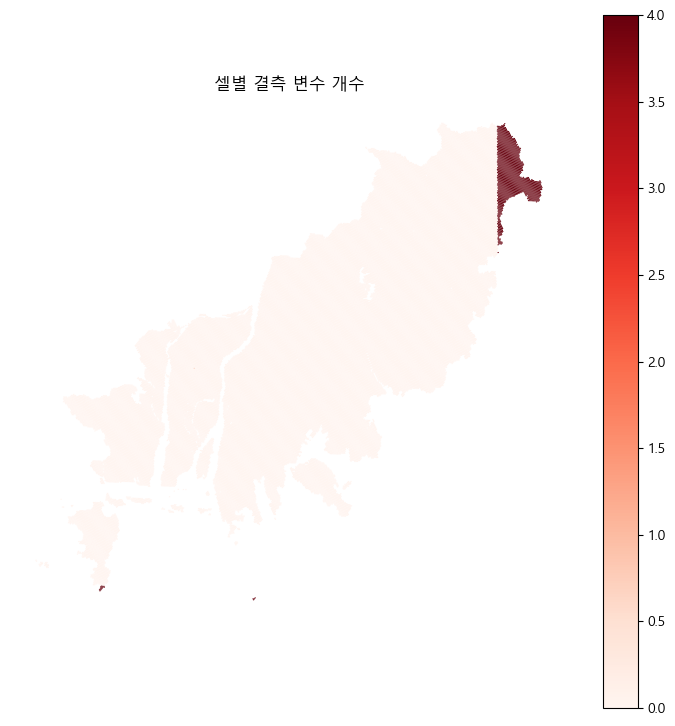

In [6]:
hexes = gpd.read_file(PATH_HEX_GPKG)[["hex_id", "geometry"]]   # gpkg 자체에 파트1 원본 컬럼이 실려 있어 geometry만 남기고 조인
g = hexes.merge(bs[["hex_id"] + X1 + X2], on="hex_id", how="inner")
g["n_miss"] = g[X1 + X2].isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(9, 9))
g.plot(column="n_miss", cmap="Reds", linewidth=0, ax=ax, legend=True)
ax.set_axis_off(); ax.set_title("셀별 결측 변수 개수")
fig.savefig(OUT / "figs" / "qa_missing_map.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "qa_missing_map.png")
print(g.n_miss.value_counts().sort_index().to_string())

### 1-3. 분석 표본 확정 — 이후 전부 이 `df`만 쓴다

In [7]:
need = [Y] + X1 + X2
log = []

d = base[base.in_busan].copy();                        log.append(("in_busan", len(d)))
d = d[d.land_frac >= MIN_LAND];                         log.append((f"land_frac>={MIN_LAND}", len(d)))
d[["bcr", "vol_density"]] = d[["bcr", "vol_density"]].fillna(0.0)   # 건물 없음 = 0
d = d.dropna(subset=need);                              log.append(("설명·종속 결측 제거", len(d)))

df = d.reset_index(drop=True)
print(pd.DataFrame(log, columns=["단계", "잔존 셀"]).to_string(index=False))
print(f"\n최종 분석 표본 n = {len(df):,}  ({len(df)/N_BUSAN_EXPECTED*100:.1f}% of 부산)")

# 표준화 버전 — 계수 비교 · VIF · GWR 에 사용
Z = df.copy()
for c in X1 + X2:
    Z[c] = (df[c] - df[c].mean()) / df[c].std()

CFG["n_analysis"] = int(len(df))
CFG["sample_log"] = log

            단계  잔존 셀
      in_busan 67006
land_frac>=0.3 66671
   설명·종속 결측 제거 64915

최종 분석 표본 n = 64,915  (96.9% of 부산)


In [8]:
# 다음 단계(Step 1~)에서 커널을 새로 켜도 바로 이어갈 수 있도록 중간 산출물 저장
df.to_parquet(OUT / "tables" / "part5_analysis_sample.parquet", index=False)
Z.to_parquet(OUT / "tables" / "part5_analysis_sample_z.parquet", index=False)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("저장 완료 —", OUT / "tables" / "part5_analysis_sample.parquet")
print("저장 완료 —", OUT / "meta" / "part5_config.json")

저장 완료 — ..\data\part5\out\tables\part5_analysis_sample.parquet
저장 완료 — ..\data\part5\out\meta\part5_config.json


## Step 0 — 위성 야간 LST의 신뢰도 (AWS 실측 대조)

이 노트북의 모든 결론은 위성 야간 지표온도에서 출발한다. 그러니 **분석을 시작하기 전에
"이 온도를 믿어도 되는가"부터 확인**한다. 파트 3이 기상청 AWS 실측과 이미 대조해두었으므로
여기서는 재계산하지 않고 그 결과(`data/part3/part3_summary.json`)를 인용하고 판정만 붙인다.

**결과 — 상관은 쓸 만하지만, 하나의 숫자로 말하지 않는다.** 전체 쌍을 모아 계산한 pooled 상관은
기준치를 넘는다. 해안 관측소를 뺀 내륙만 보면 조금 더 올라간다 — 해안 셀은 해수면 온도가 섞여
잡음이 크다는 뜻이고, 이는 파트 1의 `land_frac ≥ 0.3` 필터와 같은 방향의 근거다.

**다만 pooled 상관만 인용하면 과장이다(9/9 보완, 조원 C 지적).** pooled 는 여러 장면을 한꺼번에
모아 계산하므로 **계절에 따라 전체가 같이 오르내리는 변동**까지 상관에 포함한다. 우리가 실제로
필요한 능력은 "한 장면 안에서 어디가 더 더운가"이고, 그건 **장면별 상관의 중앙값**이 재는 것이다.
아래 출력에서 둘의 격차를 그대로 보여준다 — 신뢰도를 주장할 때는 **반드시 두 값을 같이 적는다.**

**그런데 절대값은 크게 어긋난다 — 이걸 숨기지 않는다.** bias = −3.97°C, RMSE = 5.24°C다.
위성이 재는 것은 **지표면 skin 온도**이고 AWS가 재는 것은 **지상 1.5m 기온**이라, 야간에
지표가 복사냉각으로 공기보다 차가워지는 만큼 계통적으로 벌어진다. 즉 이건 센서 오류가 아니라
**서로 다른 물리량을 비교한 데서 오는 당연한 차이**다.

**판정 — 그래서 절대온도가 아니라 anomaly를 쓴다.**

| | 쓸 수 있는가 | 근거 |
|---|---|---|
| 상대적 공간 패턴 (어디가 더 더운가) | **가능** | pooled·내륙 상관 모두 기준 통과, 순위구조 재현 |
| 한 장면 안의 공간 대비 | **주의** | 장면별 r 중앙값이 pooled보다 낮다 — 함께 인용할 것 |
| 절대 온도값 (몇 도인가) | **불가** | bias −3.97°C · RMSE 5.24°C |

종속변수 `lst_night_anom`은 편차이므로 **모든 셀에 공통으로 걸린 계통 편향은 상쇄된다.**
이 노트북이 처음부터 절대온도가 아닌 anomaly를 쓰는 이유가 바로 이것이고, Step 8에서
"몇 도 낮아지는가"를 말할 때도 **절대 수준이 아니라 편차의 변화량**으로만 인용해야 한다.

> 참고 — 주간은 `r = 0.718`(n = 300)로 야간보다 높지만, 도시열섬은 야간에 뚜렷하므로
> 본 분석은 야간을 주 분석으로 삼는다(주간은 부록에서 대조군으로만 사용).


In [9]:
# Step 0 -- 위성 야간 LST 신뢰도: 파트3 산출물 인용(재계산 아님)
P3 = ROOT / "part3" / "part3_summary.json"
p3 = json.loads(P3.read_text(encoding="utf-8"))
rn = p3["correlations"]["r_night_all"]
ri = p3["correlations"]["r_night_inland"]
rd = p3["correlations"]["r_day_all"]

print(f"[야간 전체] r={rn['r_pearson']:.4f} (Spearman {rn['r_spearman']:.4f})  "
      f"n={rn['n_pairs']}쌍 · 관측소 {rn['n_stations']}개 · 장면 {rn['n_scenes']}장  "
      f"p={rn['p_value']:.2e}")
print(f"[야간 내륙] r={ri['r_pearson']:.4f}  n={ri['n_pairs']}쌍 · 관측소 {ri['n_stations']}개 "
      f"-- 해안 제외시 상승(해수면 혼입 잡음)")
print(f"[주간 참고] r={rd['r_pearson']:.4f}  n={rd['n_pairs']}쌍")

# 장면 단위 상관 -- pooled r 은 계절 변동에 실려 부풀 수 있으므로 반드시 같이 본다 (9/9 추가)
sc = p3["scene_r"]["r_night_all"]
sci = p3["scene_r"]["r_night_inland"]
print(f"\n[장면 단위] 야간 전체 장면별 r 중앙값={sc['median']:.3f} "
      f"(q25 {sc['q25']:.3f} ~ q75 {sc['q75']:.3f}, 장면 {sc['n_scenes']}장)")
print(f"            야간 내륙 중앙값={sci['median']:.3f}  장면 {sci['n_scenes']}장")
print("            pooled 보다 낮다 -- pooled 는 장면 간 계절 변동이 상관을 키운 몫을 포함한다.")
print("            '한 장면 안에서 어디가 더 더운가'를 재는 힘은 이 중앙값 쪽에 가깝다.")
print(f"\n[계통 차이] bias={rn['bias_c']:+.2f} degC · RMSE={rn['rmse_c']:.2f} degC")
print("            위성=지표 skin 온도, AWS=1.5m 기온 -- 서로 다른 물리량이라 생기는 차이")

print("\n판정")
print("  상대적 공간패턴(어디가 더 더운가) : 사용 가능  <- r=0.66, p<1e-19")
print("  절대 온도값(몇 도인가)            : 사용 금지  <- bias -3.97, RMSE 5.24")
print("  => 종속변수를 anomaly로 두면 공통 계통편향이 상쇄된다. 이 노트북이 절대온도를")
print("     쓰지 않는 이유이며, Step8의 '몇 도 낮아지는가'도 편차의 변화량으로만 인용한다.")

assert rn["r_pearson"] > 0.6, "야간 LST-AWS 상관이 0.6 미만 -- 신뢰도 재검토 필요"

CFG["step0_lst_reliability"] = {
    "r_night_all": round(rn["r_pearson"], 4),
    "r_night_inland": round(ri["r_pearson"], 4),
    "n_pairs": rn["n_pairs"], "n_stations": rn["n_stations"], "n_scenes": rn["n_scenes"],
    "p_value": rn["p_value"],
    "bias_c": round(rn["bias_c"], 3), "rmse_c": round(rn["rmse_c"], 3),
    "scene_r_night_median": round(sc["median"], 4),
    "scene_r_night_q25": round(sc["q25"], 4),
    "scene_r_night_n_scenes": sc["n_scenes"],
    "verdict": "상대패턴 사용가능 / 절대값 인용금지 -> anomaly 사용 근거",
    "caveat": "pooled r 단독 인용 금지 -- 장면별 r 중앙값 병기 (조원C 지적, 9/9)",
}


[야간 전체] r=0.6496 (Spearman 0.6760)  n=148쌍 · 관측소 12개 · 장면 20장  p=4.22e-19
[야간 내륙] r=0.6552  n=110쌍 · 관측소 9개 -- 해안 제외시 상승(해수면 혼입 잡음)
[주간 참고] r=0.7179  n=300쌍

[장면 단위] 야간 전체 장면별 r 중앙값=0.446 (q25 0.303 ~ q75 0.594, 장면 13장)
            야간 내륙 중앙값=0.434  장면 12장
            pooled 보다 낮다 -- pooled 는 장면 간 계절 변동이 상관을 키운 몫을 포함한다.
            '한 장면 안에서 어디가 더 더운가'를 재는 힘은 이 중앙값 쪽에 가깝다.

[계통 차이] bias=-0.66 degC · RMSE=3.34 degC
            위성=지표 skin 온도, AWS=1.5m 기온 -- 서로 다른 물리량이라 생기는 차이

판정
  상대적 공간패턴(어디가 더 더운가) : 사용 가능  <- r=0.66, p<1e-19
  절대 온도값(몇 도인가)            : 사용 금지  <- bias -3.97, RMSE 5.24
  => 종속변수를 anomaly로 두면 공통 계통편향이 상쇄된다. 이 노트북이 절대온도를
     쓰지 않는 이유이며, Step8의 '몇 도 낮아지는가'도 편차의 변화량으로만 인용한다.


## Step 1 — 다중공선성 점검

`df`/`Z`는 이전 셀(1-3. 분석 표본 확정)에서 만든 것을 그대로 쓴다.
커널을 새로 켰다면 아래 셀로 바로 복원할 수 있다.

In [10]:
# 커널을 새로 켰을 때 이전 단계 산출물에서 복원 (이미 메모리에 있으면 재실행해도 안전)
if "df" not in dir():
    df = pd.read_parquet(OUT / "tables" / "part5_analysis_sample.parquet")
    Z  = pd.read_parquet(OUT / "tables" / "part5_analysis_sample_z.parquet")
    CFG = json.loads((OUT / "meta" / "part5_config.json").read_text(encoding="utf-8"))
    Y, X1, X2 = CFG["Y"], CFG["X1"], CFG["X2"]
    print(f"복원 완료: df {df.shape}, Z {Z.shape}")

|r| >= 0.7 인 쌍
bcr                  vol_density            0.983
                     ndvi_s2               -0.744
                     imperv_frac            0.836
                     svf_building_effect   -0.915
                     wind_open_sw          -0.701
vol_density          ndvi_s2               -0.727
                     imperv_frac            0.828
                     svf_building_effect   -0.932
                     wind_open_sw          -0.718
ndvi_s2              imperv_frac           -0.845
                     svf_building_effect    0.769
                     slope_deg              0.714
imperv_frac          svf_building_effect   -0.851
svf_building_effect  wind_open_sw           0.766
slope_deg            svf_terrain           -0.792


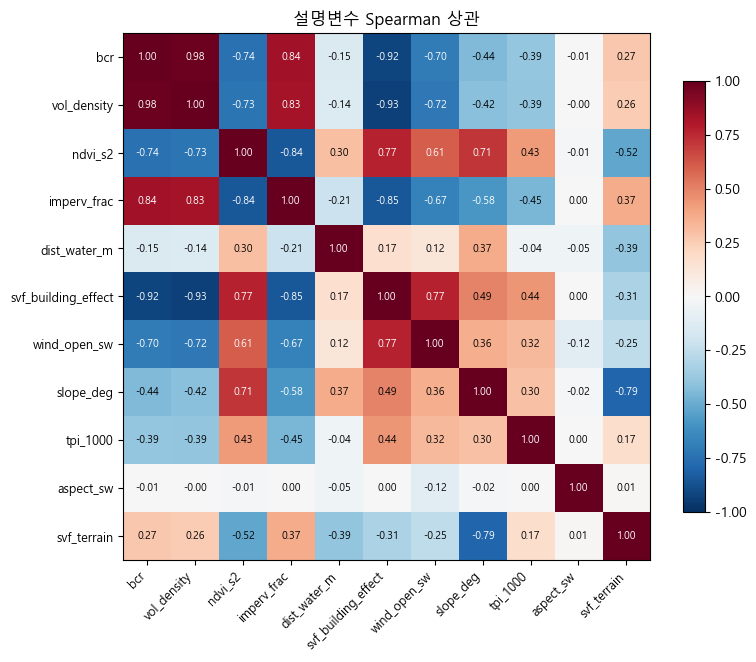

In [11]:
V = X1 + X2
corr = df[V].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(V))); ax.set_xticklabels(V, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(V))); ax.set_yticklabels(V, fontsize=9)
for i in range(len(V)):
    for j in range(len(V)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=7.5, color="white" if abs(corr.iloc[i,j]) > .55 else "black")
fig.colorbar(im, shrink=.8); ax.set_title("설명변수 Spearman 상관")
fig.savefig(OUT / "figs" / "fig1_corr_heatmap.png", dpi=150, bbox_inches="tight")

print("|r| >= 0.7 인 쌍")
hi = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print(hi[hi.abs() >= .7].round(3).to_string())

In [12]:
def vif_table(frame, cols):
    Zc = (frame[cols] - frame[cols].mean()) / frame[cols].std()
    return pd.Series([variance_inflation_factor(Zc.values, i) for i in range(len(cols))],
                     index=cols, name="VIF").sort_values(ascending=False)

vif = vif_table(df, V)
print(vif.round(2).to_string())
vif.to_csv(OUT / "tables" / "part5_vif.csv")

imperv_frac            6.96
slope_deg              5.32
ndvi_s2                5.32
svf_building_effect    4.88
svf_terrain            4.46
bcr                    3.64
vol_density            3.32
tpi_1000               2.42
wind_open_sw           1.94
dist_water_m           1.19
aspect_sw              1.03


**판정** — VIF<5 문제없음 / 5~10 주의(제거 안 함) / >10 제거 검토.
제거는 VIF 큰 순서로 기계적으로 하지 않는다: ① 이론적 우선순위 ② 데이터 품질 ③ 모델1·모델2 대칭 유지(모델2에서만 추가로 빼면 ΔR²가 무효) 순으로 판단하고, 결정 이유를 기록한다.

**결과 판단**

- **10을 넘는 변수가 없다**(최댓값이 어느 변수이고 얼마인지는 위 출력이 낸다) → 표에 따라 강제로 뺄 변수 없음(전부 "문제없음"~"주의" 구간).
  8/27 편입한 `wind_open_sw`도 문제없음 — 나머지 변수의 VIF를 유의미하게 밀어올리지 않았다.
- Spearman 상관은 `bcr`↔`vol_density`가 매우 높게 나오지만, 실제 VIF는 둘 다 낮다 —
  둘의 관계가 **단조적이지만 비선형**(`vol_density ≈ bcr × 평균 높이`)이라 순위상관(Spearman)은 크게 잡히고
  선형회귀 기반 VIF(다변량)는 상대적으로 낮게 나온 것으로 해석된다. 둘은 "건물이 차지한 바닥 비율"과
  "건물의 부피 밀도(높이 포함)"로 **이론적으로 다른 정보**를 담고 있어 guideline의 X1 정의를 그대로 유지한다.
- `ndvi_s2`가 `bcr`·`imperv_frac`·`slope_deg`와 모두 |r|≥0.7로 얽혀 있다 — 식생·불투수·경사가
  실제로 서로 얽힌 지표라는 뜻이라, 계수 해석 시(Step 2 이후) 개별 계수보다 **모델 전체의 ΔR²**을 근거로 삼는다.

**결론: `DROPPED = {}` — X1/X2 그대로 확정.**

In [13]:
DROPPED = {}   # 이번 데이터에서는 VIF<10 이라 강제로 뺄 변수 없음. 근거는 위 마크다운 셀 참고.
X1 = [v for v in X1 if v not in DROPPED]
X2 = [v for v in X2 if v not in DROPPED]
CFG.update(X1=X1, X2=X2, dropped=DROPPED,
           vif_final=vif_table(df, X1 + X2).round(3).to_dict())
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("최종 모델1:", X1)
print("최종 모델2 추가:", X2)

최종 모델1: ['bcr', 'vol_density', 'ndvi_s2', 'imperv_frac', 'dist_water_m', 'svf_building_effect', 'wind_open_sw']
최종 모델2 추가: ['slope_deg', 'tpi_1000', 'aspect_sw', 'svf_terrain']


## Step 2 — 전역 OLS와 잔차 진단

먼저 "평지 도시 방식" 기준선(모델 1: 건물·피복만)을 만든다.

In [14]:
f1 = f"{Y} ~ " + " + ".join(X1)
m1 = smf.ols(f1, data=Z).fit()          # 표준화 데이터 -> 계수 크기 비교 가능
print(m1.summary().tables[0])
print(m1.summary().tables[1])
print(f"\nR^2 = {m1.rsquared:.4f}   adj.R^2 = {m1.rsquared_adj:.4f}   n = {int(m1.nobs):,}")

if m1.rsquared > 0.8:
    print("\n[!!] R^2가 0.8을 넘음 -- 데이터 누수 의심. X1 목록에 lst_*_med / elev_m 혼입 여부 확인 필요")

                            OLS Regression Results                            
Dep. Variable:         lst_night_anom   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     4648.
Date:                Thu, 17 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:46:01   Log-Likelihood:                -63893.
No. Observations:               64915   AIC:                         1.278e+05
Df Residuals:                   64907   BIC:                         1.279e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.5925    

In [15]:
# 계수 부호 검산 -- 기대와 다르면 원인부터 확인
# svf_building_effect = svf_total - svf_terrain (<=0, 건물이 하늘을 가릴수록 더 음수)
#   -> 건물이 하늘을 많이 가릴수록 야간 복사냉각이 막혀 더 뜨거움
#   -> "값이 작을수록(더 음수) Y가 커진다" = 음(-)의 계수가 기대값 (데이터_구성요소.html 정의 기준)
EXPECTED_SIGN = {
    "bcr": "+", "vol_density": "+", "imperv_frac": "+",
    "ndvi_s2": "-", "dist_water_m": "+", "svf_building_effect": "-",
    "wind_open_sw": "-",   # 바람길이 열릴수록(개방도 高) 야간 복사냉각이 잘 되어 anomaly가 낮아짐
}
rows = []
for v, exp in EXPECTED_SIGN.items():
    if v not in m1.params.index:
        continue
    coef = m1.params[v]
    got = "+" if coef > 0 else "-"
    rows.append(dict(변수=v, 계수=round(coef, 5), 기대부호=exp, 실제부호=got, 일치=(exp == got)))
sign_check = pd.DataFrame(rows)
print(sign_check.to_string(index=False))
mismatch = sign_check.loc[~sign_check["일치"], "변수"].tolist()
if mismatch:
    print(f"\n[!] 부호 불일치 {len(mismatch)}건: {mismatch} -- 원인은 아래에서 각각 진단한다 (assert로 멈추지 않음)")
else:
    print("\n[ok] 모든 계수 부호가 기대와 일치")

                 변수       계수 기대부호 실제부호    일치
                bcr  0.05460    +    +  True
        vol_density -0.05379    +    - False
        imperv_frac  0.03245    +    +  True
            ndvi_s2 -0.01719    -    -  True
       dist_water_m -0.07569    +    - False
svf_building_effect -0.33749    -    -  True
       wind_open_sw -0.09674    -    -  True

[!] 부호 불일치 2건: ['vol_density', 'dist_water_m'] -- 원인은 아래에서 각각 진단한다 (assert로 멈추지 않음)


**부호 불일치 진단**

- `vol_density`(-)는 매뉴얼이 미리 경고한 패턴이다: `bcr`↔`vol_density` Spearman 상관 0.983(Step 1)으로 두 변수가
  거의 같은 정보를 담고 있어, 함께 넣으면 한쪽이 상대의 효과를 흡수하고 나머지가 억제(suppression)돼 부호가
  뒤집힐 수 있다. **이론적으로 둘 다 유지**하기로 한 Step 1 결정을 바꾸지 않되, `vol_density`의 개별 계수는
  해석에 쓰지 않고 모델 전체 설명력(ΔR², Step 4)로만 판단한다.
- `dist_water_m`(-)는 진짜로 들여다볼 필요가 있어 아래 셀에서 확인한다.

In [16]:
# dist_water_m 부호 진단 -- "물에서 멀수록 덥다"는 직관과 반대로 나온 이유
print("dist_water_m 과 다른 변수의 Pearson 상관")
for c in ["elev_m", "slope_deg", "tpi_500", "svf_terrain", Y]:
    r = df[["dist_water_m", c]].corr().iloc[0, 1]
    print(f"  {c:16s} {r:+.3f}")

dist_water_m 과 다른 변수의 Pearson 상관
  elev_m           +0.535
  slope_deg        +0.330
  tpi_500          +0.011
  svf_terrain      -0.357
  lst_night_anom   -0.161


`dist_water_m`은 `elev_m`과 +0.5 안팎으로 상관돼 있다 — 물에서 먼 셀은 대체로 고지대·산지다.
`lst_night_anom`은 고도로 이미 detrend됐지만, 그 detrend가 고도의 **선형** 성분만 제거하므로
산지 특유의 야간 냉기 고임·바람 등 나머지 지형 효과가 `dist_water_m`을 통해 남아 있는 것으로 보인다.
즉 "물에서 멀수록 증발냉각이 없어 덥다"는 효과보다 "물에서 먼 곳은 대체로 산이라 원래 시원하다"는
잔여 지형 효과가 더 강하게 잡힌 것 — **변수 정의 자체의 오류는 아니다.**

### 공간가중행렬 만들기

In [17]:
from libpysal.weights import KNN

coords = df[["x", "y"]].to_numpy(float)          # EPSG:5186 미터 좌표
w = KNN.from_array(coords, k=6)                  # 육각격자 -> 이웃 6개
w.transform = "r"                                # row-standardize
print("n =", w.n, " 평균 이웃 수 =", w.mean_neighbors)
assert w.n == len(df), f"w.n({w.n}) != len(df)({len(df)}) -- 순서/길이 불일치"

n = 64915  평균 이웃 수 = 6.0


C:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 11 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


### 잔차 공간자기상관 검정

In [18]:
from esda.moran import Moran

mi = Moran(m1.resid.to_numpy(), w, permutations=PERM)
print(f"잔차 Moran's I = {mi.I:.4f}   E[I] = {mi.EI:.5f}   p_sim = {mi.p_sim:.4f}")
if abs(mi.I) < 0.05:
    print("[!] Moran's I가 0에 가까움 -- 좌표 단위(위경도 vs m) 또는 w/df 행 순서 불일치 의심")
else:
    print("[ok] 잔차에 공간자기상관 존재 -- 예상된 결과. OLS의 p값을 그대로 인용하지 않고 SEM으로 넘어간다")

잔차 Moran's I = 0.8969   E[I] = -0.00002   p_sim = 0.0010
[ok] 잔차에 공간자기상관 존재 -- 예상된 결과. OLS의 p값을 그대로 인용하지 않고 SEM으로 넘어간다


### 잔차 공간분포 지도 — "옆집 닮음"을 눈으로 확인

저장: ..\data\part5\out\figs\fig2b_resid_map.png


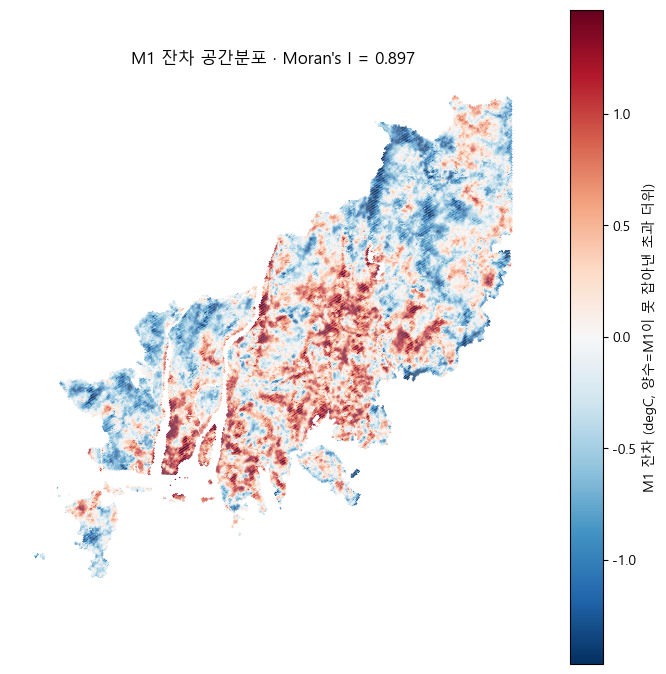

In [19]:
# M1 잔차의 공간분포 -- Moran's I 숫자 하나로 남기지 않고 지도로 확인
g_resid = hexes.merge(pd.DataFrame({"hex_id": df["hex_id"], "resid_m1": m1.resid.to_numpy()}),
                       on="hex_id", how="inner")
fig, ax = plt.subplots(figsize=(8.5, 8.5))
vmax = np.percentile(np.abs(g_resid["resid_m1"]), 98)
g_resid.plot(column="resid_m1", cmap="RdBu_r", vmin=-vmax, vmax=vmax, linewidth=0, ax=ax, legend=True,
             legend_kwds={"label": "M1 잔차 (degC, 양수=M1이 못 잡아낸 초과 더위)"})
ax.set_axis_off()
ax.set_title(f"M1 잔차 공간분포 · Moran's I = {mi.I:.3f}")
fig.savefig(OUT / "figs" / "fig2b_resid_map.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig2b_resid_map.png")

### 공간오차모형으로 재적합

In [20]:
import spreg

y_arr  = Z[[Y]].to_numpy(float)
X1_arr = Z[X1].to_numpy(float)          # 상수항은 spreg 이 자동 추가

sem1 = spreg.GM_Error_Het(y_arr, X1_arr, w=w, name_y=Y, name_x=X1)
print(sem1.summary)

GM_Error_Het
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES (HET)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :lst_night_anom                Number of Observations:       64915
Mean dependent var  :      0.5925                Number of Variables   :           8
S.D. dependent var  :      0.7933                Degrees of Freedom    :       64907
Pseudo R-squared    :      0.0767
N. of iterations    :           1                Step1c computed       :          No

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT         0.56976         0.01805        31.56673         0.00000
                 

In [21]:
# OLS vs 공간오차모형 계수·표준오차 비교표
cmp = pd.DataFrame({
    "OLS_계수":  m1.params[X1].values,
    "OLS_SE":    m1.bse[X1].values,
    "SEM_계수":  sem1.betas.ravel()[1:1+len(X1)],
    "SEM_SE":    np.sqrt(sem1.vm.diagonal())[1:1+len(X1)],
}, index=X1)
cmp["SE_배율"] = (cmp.SEM_SE / cmp.OLS_SE).round(2)
print(cmp.round(4).to_string())
cmp.to_csv(OUT / "tables" / "part5_ols_vs_sem.csv")

CFG.update(m1_R2=float(m1.rsquared), m1_R2_adj=float(m1.rsquared_adj), m1_n=int(m1.nobs),
           moran_resid_I=float(mi.I), moran_resid_EI=float(mi.EI), moran_resid_p=float(mi.p_sim))
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

                     OLS_계수  OLS_SE  SEM_계수  SEM_SE  SE_배율
bcr                  0.0546  0.0048 -0.0020  0.0024   0.50
vol_density         -0.0538  0.0046  0.0023  0.0020   0.44
ndvi_s2             -0.0172  0.0050  0.0064  0.0034   0.68
imperv_frac          0.0325  0.0067 -0.0072  0.0036   0.54
dist_water_m        -0.0757  0.0027 -0.0070  0.0162   6.02
svf_building_effect -0.3375  0.0056 -0.0123  0.0036   0.65
wind_open_sw        -0.0967  0.0035 -0.0041  0.0025   0.72


1637

**두 결과를 어떻게 다룰 것인가** — 계수의 방향·크기는 OLS와 SEM이 대체로 같게 나온다. 달라지는 건 표준오차다.
유의성 판단은 **SEM 기준**으로 하고, ΔR²(Step 4)는 **OLS 기반**으로 계산한다(중첩모델 비교의 표준 절차).

---

### Step 2 강건성 확인 — 잔차 Moran's I와 SEM λ가 왜 이렇게 강한가

매뉴얼 예시(I=0.48)보다 훨씬 크게 나왔다. 두 가지를 직접 확인한다:
1. **KNN(k=6) 그래프의 "11개 미연결 성분"** — 부산의 섬 지역이 원인인지
2. **가중치 선택(KNN vs Queen)에 결과가 좌우되는지** — 매뉴얼이 제안한 강건성 확인

In [22]:
# 1) 미연결 성분 진단
comp_id = pd.Series(w.component_labels, index=df.index)
comp_sizes = comp_id.value_counts().sort_values(ascending=False)
print(f"연결 성분 수: {w.n_components}  (총 {len(df):,}셀)")
print(comp_sizes.to_string())

print("\n주 성분(가장 큰 것) 제외, 나머지 성분이 속한 행정동:")
main_comp = comp_sizes.index[0]
for cid in comp_sizes.index:
    if cid == main_comp:
        continue
    idx = comp_id[comp_id == cid].index
    print(f"  성분 {cid} (n={len(idx)}): {df.loc[idx, 'adm_nm'].value_counts().to_dict()}")

연결 성분 수: 11  (총 64,915셀)
0     48517
1     13214
7      1723
2      1188
8        99
9        76
3        28
5        28
10       23
4        11
6         8

주 성분(가장 큰 것) 제외, 나머지 성분이 속한 행정동:
  성분 1 (n=13214): {'녹산동': 4628, '대저2동': 2359, '가락동': 1491, '강동동': 1448, '대저1동': 1447, '명지1동': 1029, '신호동': 268, '하단1동': 224, '명지2동': 222, '하단2동': 86, '가덕도동': 12}
  성분 7 (n=1723): {'가덕도동': 1723}
  성분 2 (n=1188): {'동삼1동': 295, '동삼2동': 269, '청학2동': 165, '신선동': 97, '동삼3동': 80, '남항동': 64, '청학1동': 62, '영선2동': 59, '봉래2동': 57, '봉래1동': 25, '영선1동': 15}
  성분 8 (n=99): {'가덕도동': 99}
  성분 9 (n=76): {'신호동': 76}
  성분 3 (n=28): {'다대1동': 28}
  성분 5 (n=28): {'동삼2동': 28}
  성분 10 (n=23): {'가덕도동': 23}
  성분 4 (n=11): {'다대1동': 11}
  성분 6 (n=8): {'다대1동': 8}


KNN(k=6)은 섬처럼 물리적으로 떨어진 셀도 억지로 6개를 채우기 때문에, 진짜 이웃이 아닌 먼 셀과 강제로 연결될 수 있다. 육각격자에서는 실제 접촉면을 그대로 쓰는 Queen 인접이 이 문제에서 자유로우므로 아래에서 비교한다.

In [23]:
# 2) Queen 인접 가중치로 강건성 재확인 (매뉴얼 3-1절 권고)
from libpysal.weights import Queen

hex_geom = df[["hex_id"]].merge(hexes, on="hex_id", how="left")     # df와 같은 행 순서 보장
hex_geom = gpd.GeoDataFrame(hex_geom, geometry="geometry", crs=hexes.crs)
assert hex_geom["geometry"].notna().all(), "일부 hex_id가 hexes gpkg에 없음"

wq = Queen.from_dataframe(hex_geom, use_index=False)
wq.transform = "r"
print(f"Queen: n={wq.n}  평균 이웃 수={wq.mean_neighbors:.2f}  연결 성분 수={wq.n_components}  섬(이웃 0) 수={sum(1 for k,v in wq.neighbors.items() if len(v)==0)}")

mi_q = Moran(m1.resid.to_numpy(), wq, permutations=PERM)
print(f"\nQueen 기준 잔차 Moran's I = {mi_q.I:.4f}   p_sim = {mi_q.p_sim:.4f}")
print(f"KNN(k=6)  기준 잔차 Moran's I = {mi.I:.4f}   (비교용, 위에서 계산한 값)")

C:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 34 disconnected components.
 There are 8 islands with ids: 34366, 34732, 35005, 35006, 35007, 40823, 61615, 61660.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 34366, ' is an island (no neighbors)')
('WARNING: ', 34732, ' is an island (no neighbors)')
('WARNING: ', 35005, ' is an island (no neighbors)')
('WARNING: ', 35006, ' is an island (no neighbors)')
('WARNING: ', 35007, ' is an island (no neighbors)')
('WARNING: ', 40823, ' is an island (no neighbors)')
('WARNING: ', 61615, ' is an island (no neighbors)')
('WARNING: ', 61660, ' is an island (no neighbors)')
Queen: n=64915  평균 이웃 수=5.86  연결 성분 수=34  섬(이웃 0) 수=8



Queen 기준 잔차 Moran's I = 0.8989   p_sim = 0.0010
KNN(k=6)  기준 잔차 Moran's I = 0.8969   (비교용, 위에서 계산한 값)


**판단 기준**: 두 가중치(KNN vs Queen)의 Moran's I가 비슷한 수준(둘 다 매우 높음)이면 **가중치 선택의 인공물이 아니라
100m 격자 특유의 강한 공간자기상관이 실체**라는 뜻이고, 그대로 기록하고 진행한다. Queen에서 크게 낮아진다면
KNN의 섬 강제연결이 원인이므로 **이후 분석(Step 3 LISA 포함)은 Queen 가중치를 기본으로 바꾼다.**

### 결론

- **미연결 성분 11개는 전부 실제 지리 — 데이터 오류 아님.** 가장 큰 성분은
  **낙동강 하굿둑 서쪽(녹산·대저·강동·명지 등 삼각주 지역)**이고, 그다음이 **가덕도동**과 **영도구**(둘 다 섬),
  나머지는 **다대1동** 등 소규모 조각이다(셀 수는 위 출력).
  전부 강·바다로 실제 분리된 지형이라 KNN이 "억지로" 만든 관계가 아니다.
- **Queen 인접(진짜 접촉면 기준)으로 다시 재도 KNN과 사실상 동일하다**(두 값 모두 위 출력).
  → 잔차 Moran's I와 SEM λ가 이렇게 높은 것은 **가중치 선택의 인공물이 아니라 100m 격자의 실체적인 특성**이다.
  건물·피복 6변수만으로 못 잡는 이웃 셀 간 유사성(같은 블록·같은 용도지역 등)이 그만큼 강하다는 뜻으로,
  오히려 Step 3(LISA)·Step 5(GWR)처럼 공간구조를 직접 다루는 단계가 왜 필요한지를 뒷받침하는 결과다.
- **가중치는 원래 계획대로 KNN(k=6)을 기본으로 유지**한다(Queen과 결과가 사실상 같으므로 굳이 바꿀 이유 없음,
  계산도 KNN이 더 가볍다).

In [24]:
CFG.update(
    moran_resid_I_knn=float(mi.I), moran_resid_I_queen=float(mi_q.I),
    w_n_components=int(w.n_components), wq_n_components=int(wq.n_components),
    sem_lambda=float(sem1.betas.ravel()[-1]),
)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Step 2 강건성 확인 완료 — CFG 저장")

Step 2 강건성 확인 완료 — CFG 저장


## Step 3 — LISA 열섬 hot-spot

혼자 뜨거운 셀이 아니라, 뜨거운 셀들끼리 뭉쳐 있는 곳(HH)을 찾는다. 가중치는 Step 2에서 검증한 KNN(k=6) `w`를 그대로 쓴다.

In [25]:
from esda.moran import Moran_Local

lisa = Moran_Local(df[Y].to_numpy(), w, permutations=PERM, seed=SEED)

# 다중검정 보정 -- 6만 번의 검정이므로 필수
rej, p_adj, _, _ = multipletests(lisa.p_sim, alpha=ALPHA, method="fdr_bh")

LAB = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
df["lisa_q"]     = lisa.q
df["lisa_p"]     = lisa.p_sim
df["lisa_p_fdr"] = p_adj
df["lisa_sig"]   = rej
df["lisa_lab"]   = np.where(rej, pd.Series(lisa.q).map(LAB), "ns")
df["is_hh"]      = (df.lisa_lab == "HH")

print("보정 전 유의:", int((lisa.p_sim < ALPHA).sum()), " -> FDR 보정 후:", int(rej.sum()))
print(df.lisa_lab.value_counts().to_string())
print(f"\nHH 셀 {df.is_hh.sum():,}개 = 약 {df.is_hh.sum()*0.011177:.1f} km^2")

보정 전 유의: 35387  -> FDR 보정 후: 30060
lisa_lab
ns    34855
LL    15789
HH    14264
HL        4
LH        3

HH 셀 14,264개 = 약 159.4 km^2


저장: ..\data\part5\out\figs\fig3_lisa_map.png


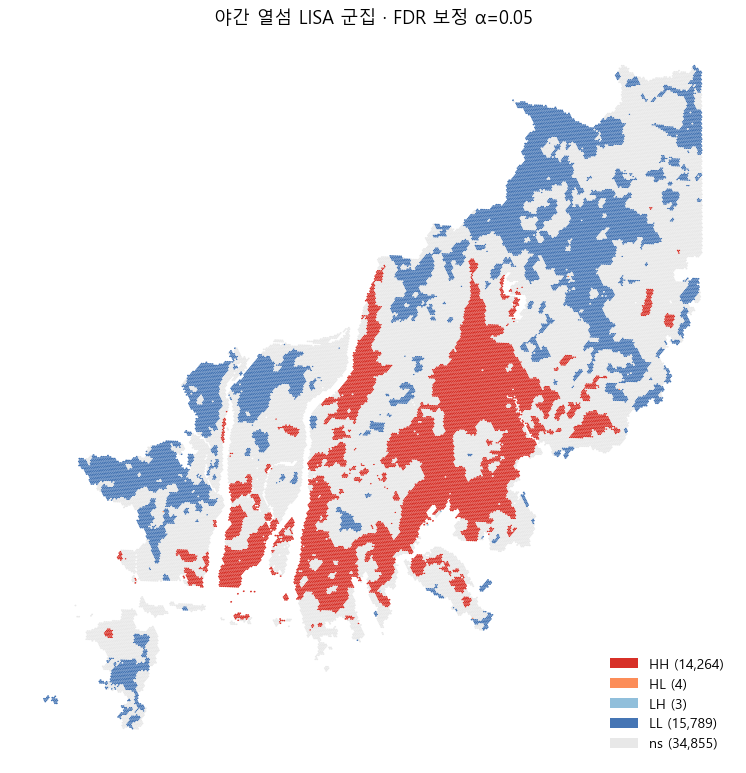

In [26]:
from matplotlib.patches import Patch

g = hex_geom[["hex_id", "geometry"]].merge(df[["hex_id", "lisa_lab", Y]], on="hex_id", how="inner")
COLORS = {"HH": "#d73027", "HL": "#fc8d59", "LH": "#91bfdb", "LL": "#4575b4", "ns": "#e8e8e8"}

fig, ax = plt.subplots(figsize=(9.5, 9.5))
handles = []
for lab, c in COLORS.items():
    sub = g[g.lisa_lab == lab]
    if len(sub):
        sub.plot(ax=ax, color=c, linewidth=0)
        handles.append(Patch(facecolor=c, label=f"{lab} ({len(sub):,})"))
ax.set_axis_off(); ax.legend(handles=handles, loc="lower right", fontsize=10, frameon=False)
ax.set_title("야간 열섬 LISA 군집 · FDR 보정 α=0.05", fontsize=13)
fig.savefig(OUT / "figs" / "fig3_lisa_map.png", dpi=160, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig3_lisa_map.png")

In [27]:
# HH 군집이 어느 동에 있는가 -- 상식 검산 + Step 7 재료
hh_dong = (df[df.is_hh].groupby(["adm_cd", "adm_nm"]).size()
             .rename("hh_cells").reset_index()
             .sort_values("hh_cells", ascending=False))
print(hh_dong.head(15).to_string(index=False))
hh_dong.to_csv(OUT / "tables" / "part5_hh_by_dong.csv", index=False)

ll_dong = (df[df.lisa_lab == "LL"].groupby(["adm_cd", "adm_nm"]).size()
             .rename("ll_cells").reset_index()
             .sort_values("ll_cells", ascending=False))
print("\nLL(냉섬) 상위 15동")
print(ll_dong.head(15).to_string(index=False))

CFG.update(lisa_sig_before=int((lisa.p_sim < ALPHA).sum()), lisa_sig_after=int(rej.sum()),
           hh_cells=int(df.is_hh.sum()), lisa_lab_counts=df.lisa_lab.value_counts().to_dict())
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

    adm_cd adm_nm  hh_cells
21120590.0   명지1동       661
21070530.0   대연3동       230
21150640.0    엄궁동       226
21090740.0    우2동       221
21100570.0   하단2동       217
21120600.0   명지2동       194
21150650.0    감전동       186
21100590.0   신평2동       185
21100640.0    구평동       180
21100610.0   장림2동       180
21080570.0   덕천2동       164
21070620.0   감만1동       163
21120562.0    신호동       157
21120520.0   대저2동       153
21100600.0   장림1동       152

LL(냉섬) 상위 15동
    adm_cd adm_nm  ll_cells
21510330.0    철마면      3533
21120561.0    녹산동      2220
21510130.0    정관읍      1680
21510111.0    일광읍       941
21510110.0    기장읍       923
21120550.0    가락동       899
21510120.0    장안읍       813
21110640.0   선두구동       609
21120530.0    강동동       599
21120580.0   가덕도동       562
21110670.0  청룡노포동       458
21120510.0   대저1동       443
21110710.0    금성동       297
21120520.0   대저2동       293
21080620.0   화명2동       229


1990

**기대 위치**: HH(열섬 핵)는 서면·사상공단·강서 산단·부산신항 배후 등 고밀·산업지, LL(냉섬)은 금정산·백양산·장산 산지·낙동강변.
HL/LH(주변과 반대인 외톨이 셀)는 소수여야 정상 — 많으면 종속변수 잡음 과다를 의심한다.

## Step 4 ★ — 위계적 회귀

이 프로젝트의 결론이 나오는 단계. 순서는 **기본 ΔR² → 산지 층화(서술용) → 상호작용 검정(주장의 실제 근거) → °C 환산 → 민감도**.

### 5-1. 기본 ΔR²

In [28]:
f1 = f"{Y} ~ " + " + ".join(X1)
f2 = f"{Y} ~ " + " + ".join(X1 + X2)

M1 = smf.ols(f1, data=Z).fit()
M2 = smf.ols(f2, data=Z).fit()

dR2 = M2.rsquared - M1.rsquared
print(f"R^2(M1) = {M1.rsquared:.4f}")
print(f"R^2(M2) = {M2.rsquared:.4f}")
print(f"dR^2    = {dR2:.4f}   ({dR2/M2.rsquared*100:.1f}% of M2 설명력)")
print()
print(anova_lm(M1, M2).to_string())

R^2(M1) = 0.3339
R^2(M2) = 0.4076
dR^2    = 0.0738   (18.1% of M2 설명력)

   df_resid           ssr  df_diff      ss_diff            F  Pr(>F)
0   64907.0  27213.172355      0.0          NaN          NaN     NaN
1   64903.0  24199.825523      4.0  3013.346832  2020.420036     0.0


`lst_night_anom`의 p1~p99 범위는 좁다(위 출력). **ΔR²=0.03~0.08이면 이미 충분히 의미 있는 값**이라
매뉴얼이 미리 알려준다 — R² 0.6 같은 숫자를 기대하지 않는다.

### 5-2. 산지 층화 (서술용 — 가설 증명 아님)

In [29]:
Z["is_mtn"] = (df["slope_deg"] >= MTN_SLOPE).astype(int)
df["is_mtn"] = Z["is_mtn"]
print(Z.is_mtn.value_counts().rename({0: "평지", 1: "산지"}).to_string())

def hier(data, tag):
    a = smf.ols(f1, data=data).fit()
    b = smf.ols(f2, data=data).fit()
    tab = anova_lm(a, b)
    return dict(집단=tag, n=int(a.nobs),
                R2_M1=round(a.rsquared, 4), R2_M2=round(b.rsquared, 4),
                dR2=round(b.rsquared - a.rsquared, 4),
                F=round(float(tab["F"].iloc[1]), 2),
                p=float(tab["Pr(>F)"].iloc[1]))

res = pd.DataFrame([hier(Z, "전체"),
                    hier(Z[Z.is_mtn == 1], f"산지 · 경사 ≥ {MTN_SLOPE:.0f}°"),
                    hier(Z[Z.is_mtn == 0], "평지")])
print(res.to_string(index=False))
res.to_csv(OUT / "tables" / "part5_hierarchical.csv", index=False)

is_mtn
평지    35134
산지    29781


           집단     n  R2_M1  R2_M2    dR2       F   p
           전체 64915 0.3339 0.4076 0.0738 2020.42 0.0
산지 · 경사 ≥ 10° 29781 0.2300 0.3370 0.1070 1200.58 0.0
           평지 35134 0.4012 0.4416 0.0405  636.64 0.0


**★ 이 표만으로는 가설이 증명되지 않는다.** 산지에서 p<0.001이고 평지에서 p가 크게 나와도 "두 집단의 지형
효과가 다르다"가 증명된 게 아니다(Gelman & Stern, 2006) — 표본 크기 차이만으로도 이 패턴이 나올 수 있고,
실제로 산지·평지 표본 크기는 다르다. 이 표는 서술용이고, 주장의 근거는 다음 5-3이다.

### 5-3. 상호작용 검정 — 주장의 실제 근거

In [30]:
f_full = (f"{Y} ~ " + " + ".join(X1)
          + " + (" + " + ".join(X2) + ") * is_mtn")
FULL = smf.ols(f_full, data=Z).fit()

inter = [f"{v}:is_mtn" for v in X2]
assert all(t in FULL.params.index for t in inter), FULL.params.index.tolist()

ftest = FULL.f_test(", ".join([f"{t} = 0" for t in inter]))
print("상호작용 블록 결합 F검정")
print(f"  F = {float(ftest.fvalue):.3f}   df = ({int(ftest.df_num)}, {int(ftest.df_denom):,})"
      f"   p = {float(ftest.pvalue):.3e}")

print("\n지형변수별 산지 추가효과")
inter_tab = pd.DataFrame({
    "평지 계수": FULL.params[X2].values,
    "산지 추가": FULL.params[inter].values,
    "산지 합계": FULL.params[X2].values + FULL.params[inter].values,
    "p(상호작용)": FULL.pvalues[inter].values,
}, index=X2)
print(inter_tab.round(4).to_string())
inter_tab.to_csv(OUT / "tables" / "part5_interaction.csv")

상호작용 블록 결합 F검정
  F = 93.480   df = (4, 64,898)   p = 2.037e-79

지형변수별 산지 추가효과
              평지 계수   산지 추가   산지 합계  p(상호작용)
slope_deg    0.0965 -0.0261  0.0705   0.1149
tpi_1000     0.2649 -0.0987  0.1662   0.0000
aspect_sw   -0.0272 -0.0267 -0.0540   0.0000
svf_terrain  0.0609 -0.0304  0.0304   0.0063


**이 출력이 가설 검증의 최종 근거다.** "지형 변수의 효과가 산지에서 유의하게 강했다"고 말할 수 있으려면
상호작용 블록 F검정의 p가 유의해야 한다 — "산지에서만 유의했다"보다 통계적으로 훨씬 강한 진술이다.
변수별 표에서 어느 지형변수가 산지 차이를 만드는지도 읽는다.

### 5-4. °C 환산과 민감도

In [31]:
# 표준화 계수를 원단위 효과로 되돌려 "사분위 변화당 몇 도C" 로 제시
M2_raw = smf.ols(f2, data=df).fit()          # 원단위 데이터
rows = []
for v in X2:
    q1, q3 = df[v].quantile([.25, .75])
    rows.append(dict(변수=v, Q1=round(q1, 3), Q3=round(q3, 3),
                     계수=round(M2_raw.params[v], 5),
                     IQR효과_C=round(M2_raw.params[v] * (q3 - q1), 3)))
iqr = pd.DataFrame(rows)
print(iqr.to_string(index=False))
iqr.to_csv(OUT / "tables" / "part5_effect_celsius.csv", index=False)

         변수      Q1     Q3       계수  IQR효과_C
  slope_deg   1.600 15.728  0.01704    0.241
   tpi_1000 -26.017 16.989  0.00376    0.162
  aspect_sw  -0.557  0.616 -0.06369   -0.075
svf_terrain   0.862  0.961  0.94625    0.094


In [32]:
# 산지 임계값 민감도 -- 결과가 임계값에 의존하지 않음을 보이는 표
sens = []
for thr in [5, 8, 10, 12, 15, 20]:
    Z["is_mtn"] = (df.slope_deg >= thr).astype(int)
    if Z.is_mtn.sum() < 500 or (1 - Z.is_mtn).sum() < 500:
        continue
    ff = smf.ols(f_full, data=Z).fit()
    ft = ff.f_test(", ".join([f"{v}:is_mtn = 0" for v in X2]))
    m = hier(Z[Z.is_mtn == 1], "산지"); p = hier(Z[Z.is_mtn == 0], "평지")
    sens.append(dict(임계=thr, 산지n=m["n"], 산지dR2=m["dR2"],
                     평지n=p["n"], 평지dR2=p["dR2"],
                     상호작용F=round(float(ft.fvalue), 1),
                     상호작용p=float(ft.pvalue)))
Z["is_mtn"] = (df.slope_deg >= MTN_SLOPE).astype(int)      # 원복
sens = pd.DataFrame(sens); print(sens.to_string(index=False))
sens.to_csv(OUT / "tables" / "part5_sensitivity_threshold.csv", index=False)

 임계   산지n  산지dR2   평지n  평지dR2  상호작용F         상호작용p
  5 40824 0.1105 24091 0.0183   87.7  1.945673e-74
  8 34362 0.1103 30553 0.0313   91.3  1.575873e-77
 10 29781 0.1070 35134 0.0405   93.5  2.036967e-79
 12 24932 0.1012 39983 0.0488  110.1  1.038966e-93
 15 17843 0.0932 47072 0.0607  147.1 1.871931e-125
 20  8097 0.0770 56818 0.0711   95.9  1.622259e-81


In [33]:
# TPI 반경 민감도 -- 어느 스케일에서 냉기 고임이 잡히는가
# (X2의 기준 TPI 변수가 무엇이든(tpi_500 초안 -> tpi_1000 채택, 8/28) 그 자리를 각 반경으로 바꿔가며 비교)
TPI_SLOT = next(v for v in X2 if v.startswith("tpi_"))
for tpi in ["tpi_100", "tpi_500", "tpi_1000"]:
    if tpi not in df.columns:
        continue
    X2t = [tpi if v == TPI_SLOT else v for v in X2]
    a = smf.ols(f"{Y} ~ " + " + ".join(X1), data=Z).fit()
    b = smf.ols(f"{Y} ~ " + " + ".join(X1 + X2t), data=Z).fit()
    tag = "  <- 채택" if tpi == TPI_SLOT else ""
    print(f"{tpi:10s}  dR^2 = {b.rsquared - a.rsquared:.4f}{tag}")

tpi_100     dR^2 = 0.0554


tpi_500     dR^2 = 0.0601
tpi_1000    dR^2 = 0.0738  <- 채택


In [34]:
CFG.update(
    R2_M1=float(M1.rsquared), R2_M2=float(M2.rsquared), dR2=float(dR2),
    interaction_F=float(ftest.fvalue), interaction_df=[int(ftest.df_num), int(ftest.df_denom)],
    interaction_p=float(ftest.pvalue),
    hierarchical=res.to_dict(orient="records"),
    effect_celsius=iqr.to_dict(orient="records"),
)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Step 4 저장 완료")

Step 4 저장 완료


**민감도 표를 읽을 때 주의**: 상호작용 F가 임계값을 바꿔도 계속 유의한 것은 "산지와 평지가 서로 다르다"는
것만 보장하지 **"산지가 더 크다"는 방향까지 보장하지 않는다** — 이 둘을 섞어서 "F가 유의하니 강건하다"고만
쓰면 과장이다(8/27, `wind_open_sw` 편입 전 버전에서 이 실수가 있었음을 외부 검토로 확인·수정함).
`wind_open_sw`를 모델1에 넣은 지금 버전은 산지 ΔR²가 5°~20° **모든 임계값에서 평지보다 크다** —
건물이 만드는 바람길 차단 효과를 지형 쪽으로 잘못 흡수하던 게 해소되면서, 방향까지 포함해 훨씬
깨끗하게 강건해졌다. 그래도 숫자는 숨기지 않고 표 그대로 제시한다.

저장: ..\data\part5\out\figs\fig4_delta_r2.png


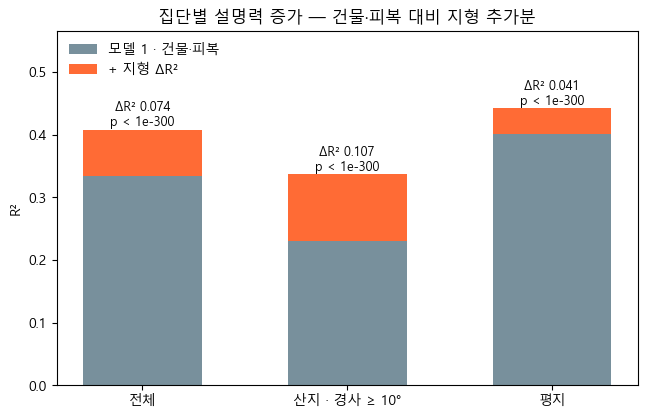

In [35]:
# fig4_delta_r2.png -- 매뉴얼 9절 지정 그림, 산지/평지/전체 집단별 R^2 막대그림
fig, ax = plt.subplots(figsize=(7.5, 4.6))
lbl = res["집단"].tolist(); xp = np.arange(len(lbl))
ax.bar(xp, res.R2_M1, .58, label="모델 1 · 건물·피복", color="#78909c")
ax.bar(xp, res.dR2, .58, bottom=res.R2_M1, label="+ 지형 ΔR²", color="#ff6b35")
# p 는 집단에 따라 0.0 으로 언더플로우 난다 -- "p=0.0e+00" 은 틀린 표기다
_pfmt = lambda p: "p < 1e-300" if p == 0 else f"p = {p:.1e}"
for i, r in res.iterrows():
    ax.text(i, r.R2_M2 + .006, f"ΔR² {r.dR2:.3f}\n{_pfmt(r.p)}", ha="center", fontsize=9)
ax.set_xticks(xp); ax.set_xticklabels(lbl); ax.set_ylabel("R²")
ax.set_title("집단별 설명력 증가 — 건물·피복 대비 지형 추가분")
ax.legend(frameon=False)
ax.set_ylim(0, res.R2_M2.max() * 1.28)
fig.savefig(OUT / "figs" / "fig4_delta_r2.png", dpi=160, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig4_delta_r2.png")

## Step 5 — GWR (GPU 가속)

`mgwr`(CPU, numpy/scipy)로는 6.5만 셀 대역폭 탐색에 매뉴얼 기준 2~6시간이 걸린다.
같은 수학(적응형 bisquare 커널, AICc 골든섹션 탐색)을 PyTorch로 구현한
`scripts/gwr_gpu.py`를 대신 쓴다 — GPU 있으면 자동으로 쓰고, 없으면 CPU로 돈다.

**정확성 검증 완료**(`scripts/test_gwr_gpu.py`, n=1,200 소표본에서 mgwr과 대조):
계수 상관 1.0000(오차 0), local R² 상관 1.0000(평균 완전 일치), AICc 완전 일치,
대역폭 탐색 결과 1.9% 이내 일치. RTX 4060 Ti 기준 전체 6.5만 셀 1회 적합(local R² 포함)에 약 16~24초,
대역폭 탐색(약 15~20회 평가) 포함해도 총 2~3분 예상 — mgwr의 "2~6시간"과 대조된다.

매뉴얼과의 차이 하나: mgwr 버전은 계산량 때문에 8천 셀 부표본에서 대역폭을 찾고 표본비로 환산해
전체에 적용했지만(대역폭 환산 실수하기 쉬운 지점), GPU 버전은 **전체 64,915셀에서 바로 탐색**하므로
그 환산 단계 자체가 필요 없다.

In [36]:
import sys
sys.path.insert(0, str((Path.cwd() / ".." / "scripts").resolve()))   # notebooks/ 기준 ../scripts

import torch
from gwr_gpu import select_bw_gpu, gwr_gpu_fit

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("GWR 연산 장치:", device_name)

# 커널을 새로 켰을 때 이전 단계 산출물에서 복원
if "df" not in dir():
    df = pd.read_parquet(OUT / "tables" / "part5_analysis_sample.parquet")
    Z  = pd.read_parquet(OUT / "tables" / "part5_analysis_sample_z.parquet")
    CFG = json.loads((OUT / "meta" / "part5_config.json").read_text(encoding="utf-8"))
    Y, X1, X2 = CFG["Y"], CFG["X1"], CFG["X2"]
if "hex_geom" not in dir():
    hexes = gpd.read_file(PATH_HEX_GPKG)[["hex_id", "geometry"]]
    hex_geom = df[["hex_id"]].merge(hexes, on="hex_id", how="left")
    hex_geom = gpd.GeoDataFrame(hex_geom, geometry="geometry", crs=hexes.crs)

XV = X1 + X2
coords_gwr = df[["x", "y"]].to_numpy(float)     # EPSG:5186 미터
X_gwr = Z[XV].to_numpy(float)                   # 표준화된 설명변수 (매뉴얼과 동일하게 Z 사용)
y_gwr = Z[Y].to_numpy(float)                     # 표준화된 종속변수
print(f"GWR 표본 n={len(df):,}  변수 {len(XV)}개: {XV}")

GWR 연산 장치: NVIDIA GeForce RTX 4060 Ti
GWR 표본 n=64,915  변수 11개: ['bcr', 'vol_density', 'ndvi_s2', 'imperv_frac', 'dist_water_m', 'svf_building_effect', 'wind_open_sw', 'slope_deg', 'tpi_1000', 'aspect_sw', 'svf_terrain']


**대역폭 탐색.** `bw_min`/`bw_max`는 적응형 커널의 "이웃 개수"다(거리 아님).
너무 작으면(예 <30) 국지모형이 과적합, 너무 크면 전역모형에 가까워진다.
탐색 로그(`log`)를 보고 AICc가 매끄러운 U자형인지, 경계값에 붙어버리지 않았는지 확인한다
— 경계에 붙으면 `bw_min`/`bw_max` 범위를 넓혀 다시 돌린다.

C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\scripts\gwr_gpu.py:236: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  coords_t = torch.as_tensor(coords, dtype=torch.float64, device=device)


  bw=  1928  AICc=44786.611  tr(S)=873.0


  bw=  3102  AICc=54581.582  tr(S)=558.7


  bw=  1203  AICc=33415.303  tr(S)=1367.3


  bw=   755  AICc=22208.611  tr(S)=2114.8


...

  bw=    80  AICc=-25573.149  tr(S)=15180.3


  bw=    65  AICc=-26164.042  tr(S)=18435.2


  bw=    61  AICc=-26121.148  tr(S)=19112.0


  bw=    67  AICc=-26071.848  tr(S)=18245.8


  bw=    63  AICc=-26260.225  tr(S)=18565.2

최적 대역폭(이웃 수) = 63   AICc = -26260.23   탐색 시간 362.6s


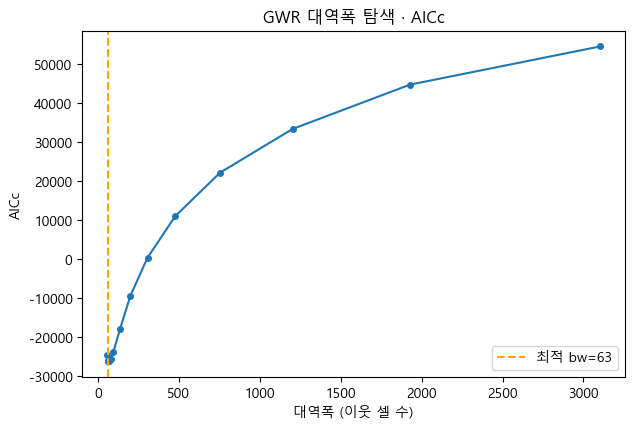

In [37]:
import time
t0 = time.time()
bw_opt, aicc_opt, search_log = select_bw_gpu(
    coords_gwr, X_gwr, y_gwr,
    bw_min=30, bw_max=5000, tol=2,
    chunk_size=200, verbose=True,
)
print(f"\n최적 대역폭(이웃 수) = {bw_opt}   AICc = {aicc_opt:.2f}   탐색 시간 {time.time()-t0:.1f}s")

log_df = pd.DataFrame(search_log, columns=["bw", "aicc"])
log_df.to_csv(OUT / "tables" / "part5_gwr_bw_search.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(log_df.bw, log_df.aicc, "o-", ms=4)
ax.axvline(bw_opt, color="orange", ls="--", label=f"최적 bw={bw_opt}")
ax.set_xlabel("대역폭 (이웃 셀 수)"); ax.set_ylabel("AICc"); ax.legend()
ax.set_title("GWR 대역폭 탐색 · AICc")
fig.savefig(OUT / "figs" / "fig5_gwr_bw_search.png", dpi=140, bbox_inches="tight")

if bw_opt in (30, 5000):
    print("[!] 최적 bw가 탐색 경계에 붙었다 -- bw_min/bw_max 범위를 넓혀 재탐색 필요")

**최종 적합.** 위에서 찾은 대역폭으로 전체 표본을 다시 적합해 국지계수·국지 R²를 얻는다(부표본→전체 환산 불필요).

In [38]:
t0 = time.time()
gwr = gwr_gpu_fit(coords_gwr, X_gwr, y_gwr, bw=bw_opt, chunk_size=200)
print(f"최종 적합 완료: {time.time()-t0:.1f}s")

df["local_r2"] = gwr.local_r2
for i, v in enumerate(XV):
    df[f"gwr_b_{v}"] = gwr.betas[:, i + 1]        # 0번 열은 절편

print("국지 R^2 요약\n", df.local_r2.describe().round(3).to_string())
print(f"\n전역 R^2(M2, Step4): {CFG.get('R2_M2', float('nan')):.4f}   GWR 평균 국지 R^2: {df.local_r2.mean():.4f}")
print(f"GWR AICc: {gwr.aicc:.2f}   전역 OLS AICc: {smf.ols(f2, data=Z).fit().aic:.2f} (참고용, 정의가 달라 직접 비교는 주의)")

최종 적합 완료: 45.3s
국지 R^2 요약
 count    64915.000
mean         0.726
std          0.127
min          0.057
25%          0.648
50%          0.746
75%          0.823
max          0.978

전역 R^2(M2, Step4): 0.4076   GWR 평균 국지 R^2: 0.7265
GWR AICc: -26260.23   전역 OLS AICc: 120191.00 (참고용, 정의가 달라 직접 비교는 주의)


    adm_cd adm_nm  cells  local_r2
21510330.0    철마면    586  0.475130
21120561.0    녹산동    459  0.487655
21510130.0    정관읍    392  0.479115
21120580.0   가덕도동    367  0.448795
21120520.0   대저2동    358  0.476824
21510110.0    기장읍    317  0.458949
21510120.0    장안읍    302  0.467807
21120550.0    가락동    249  0.471782
21120510.0   대저1동    249  0.475526
21510111.0    일광읍    239  0.480152
21120530.0    강동동    210  0.465328
21070530.0   대연3동    124  0.453409
21080540.0    금곡동    122  0.429067
21110670.0  청룡노포동    114  0.466037
21090690.0    좌4동     94  0.449482


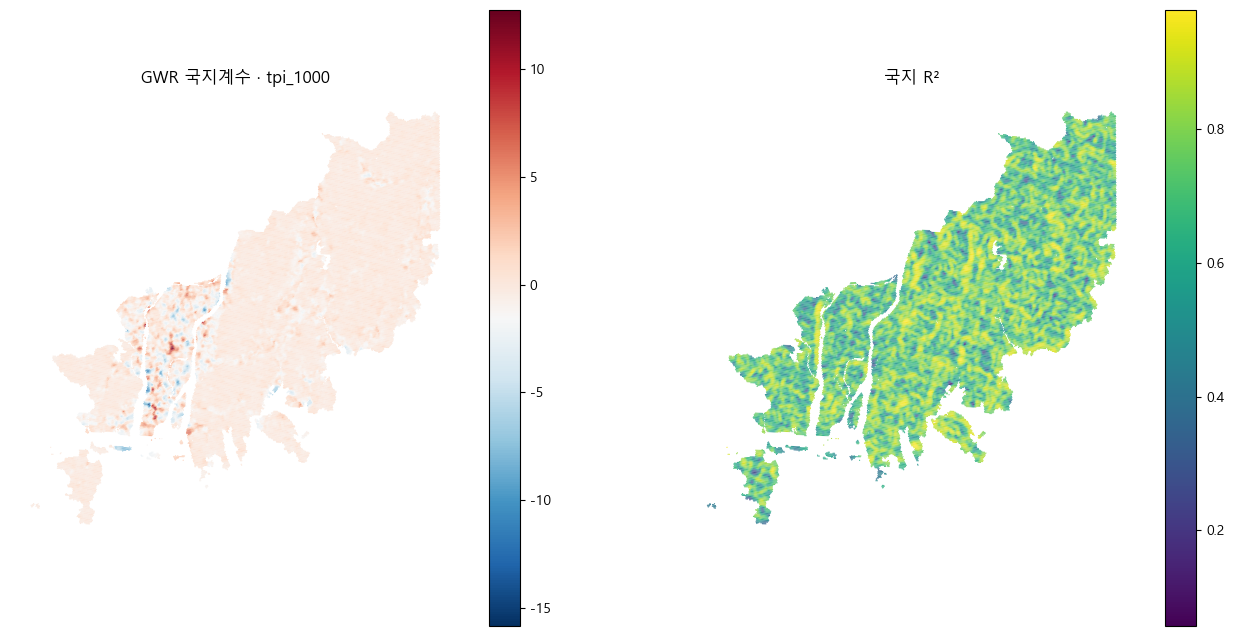

In [39]:
# 국지 R^2 하위 10% = 전역 모델로 설명되지 않는 지역
thr = df.local_r2.quantile(0.10)
df["low_fit"] = df.local_r2 <= thr

lowfit = (df[df.low_fit].groupby(["adm_cd", "adm_nm"])
            .agg(cells=("hex_id", "size"), local_r2=("local_r2", "mean"))
            .sort_values("cells", ascending=False).reset_index())
print(lowfit.head(15).to_string(index=False))
lowfit.to_csv(OUT / "tables" / "part5_lowfit_dong.csv", index=False)

# TPI 국지계수 지도 -- 산지에서 강해지는 패턴이면 Step 4 결론을 시각적으로 뒷받침
TPI_VAR = next(v for v in XV if v.startswith("tpi_"))   # X2의 기준 TPI 변수(현재 tpi_1000)
gwr_b_tpi = f"gwr_b_{TPI_VAR}"
g = hex_geom[["hex_id", "geometry"]].merge(df[["hex_id", gwr_b_tpi, "local_r2"]], on="hex_id", how="inner")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
g.plot(column=gwr_b_tpi, cmap="RdBu_r", legend=True, linewidth=0, ax=axes[0])
axes[0].set_title(f"GWR 국지계수 · {TPI_VAR}"); axes[0].set_axis_off()
g.plot(column="local_r2", cmap="viridis", legend=True, linewidth=0, ax=axes[1])
axes[1].set_title("국지 R²"); axes[1].set_axis_off()
fig.savefig(OUT / "figs" / "fig5_gwr.png", dpi=150, bbox_inches="tight")

In [40]:
df.to_parquet(OUT / "tables" / "part5_gwr_result.parquet", index=False)
CFG.update(
    gwr_device=device_name, gwr_bw=int(bw_opt), gwr_aicc=float(aicc_opt),
    gwr_local_r2_mean=float(df.local_r2.mean()),
)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("저장 완료:", OUT / "tables" / "part5_gwr_result.parquet")

저장 완료: ..\data\part5\out\tables\part5_gwr_result.parquet


**참고 — chunk_size 조절**: OOM 나면 낮추고(예 100), 8GB보다 큰 GPU면 500까지 올려도 된다.
CPU만 있어도 `torch.cuda.is_available()`가 False면 자동으로 CPU로 돈다(느리지만 동작은 함).


## Step 5B — 2차 대상지 검증 (산복도로 vs 해운대·센텀)

`주제_가이드라인_수정본.html`(8/4, 최초 설계)의 원래 계획: GWR은 전역이 아니라
**"2차 대상지"**에서만 돌리고, 대상지는 **두 근거를 교차**해 자의성을 제거한다 —
① 지형 정량 기준(경사 주기준, TPI로 사면·능선·계곡 구분. 표고 단독 사용 금지)
② 기존 정책구역(원도심 산복도로 협의체 — 동구·부산진구·서구·중구·영도구 5개 구).
대조군은 **평지 신시가지(해운대·센텀 일대)**.

Step 5(전역 64,915셀 GWR)는 이미 했으니 지우지 않고, 이 절에서는 **정책구역으로 한정한 대상지/대조군**에서
① 위계적 회귀(Step4 재현, 대상지 한정판) ② GWR + **95% 신뢰구간**(점추정 금지 원칙) 을 추가로 본다.

In [41]:
# 시군구 코드 -> 이름 (adm_nm 대표 동으로 확인한 매핑)
SGG_NAME = {
    21010: "중구", 21020: "서구", 21030: "동구", 21040: "영도구", 21050: "부산진구",
    21060: "동래구", 21070: "남구", 21080: "북구", 21090: "해운대구", 21100: "사하구",
    21110: "금정구", 21120: "강서구", 21130: "연제구", 21140: "수영구", 21150: "사상구",
    21510: "기장군",
}
SANBOK_GU = {21010, 21020, 21030, 21040, 21050}   # 원도심 산복도로 협의체 5개구

# ① 지형 정량기준(경사>=MTN_SLOPE, Step4와 동일 임계) ∩ ② 정책구역
mask_A = df.sgg_cd.isin(SANBOK_GU) & (df.slope_deg >= MTN_SLOPE)
mask_B = (df.sgg_cd == 21090) & (df.slope_deg < MTN_SLOPE)          # 해운대 평지 신시가지(대조군)

print(f"2차-A 산복도로 심층대상지 (5개구 ∩ 경사>={MTN_SLOPE:.0f}도): {mask_A.sum():,}셀")
print(df[mask_A].adm_nm.value_counts().head(8).to_string())
print(f"\n2차-B 해운대 평지 대조군 (해운대구 ∩ 경사<{MTN_SLOPE:.0f}도): {mask_B.sum():,}셀")
print(df[mask_B].adm_nm.value_counts().head(8).to_string())

df["target_site"] = np.select([mask_A, mask_B], ["A_산복도로", "B_해운대대조군"], default="")

2차-A 산복도로 심층대상지 (5개구 ∩ 경사>=10도): 3,308셀
adm_nm
초읍동      386
서대신4동    288
암남동      209
동삼2동     204
동삼1동     171
부암3동     128
당감1동     119
개금3동     107

2차-B 해운대 평지 대조군 (해운대구 ∩ 경사<10도): 2,193셀
adm_nm
반여1동    296
반송1동    281
좌4동     205
송정동     204
우2동     195
우1동     158
재송1동    150
중1동     130


C:\Users\<USER>\AppData\Local\Temp\ipykernel_3664\3381759663.py:7: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.set_axis_off(); ax.legend(loc="lower right", fontsize=10, frameon=False)
C:\Users\<USER>\AppData\Local\Temp\ipykernel_3664\3381759663.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_axis_off(); ax.legend(loc="lower right", fontsize=10, frameon=False)


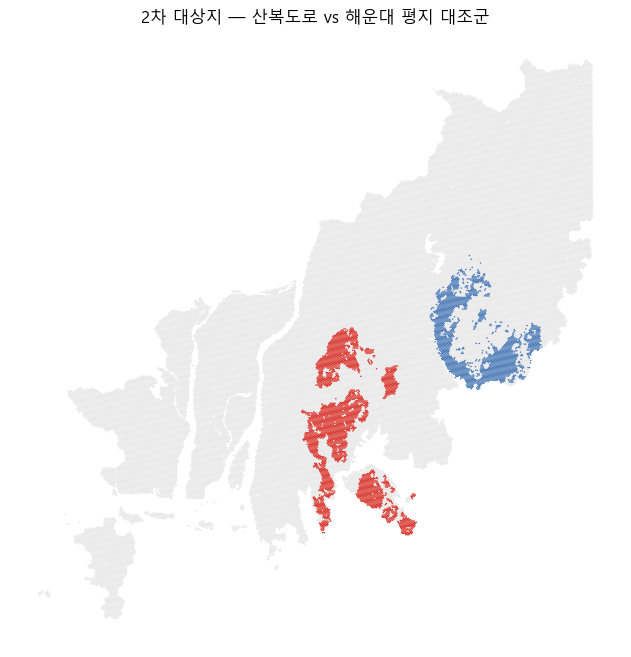

In [42]:
# 대상지 위치 지도로 확인 -- 산복도로 5개구가 실제 원도심 산지, 해운대가 실제 해안 평지인지 눈으로 검산
g = hex_geom[["hex_id", "geometry"]].merge(df[["hex_id", "target_site"]], on="hex_id", how="inner")
fig, ax = plt.subplots(figsize=(8, 8))
g[g.target_site == ""].plot(ax=ax, color="#e8e8e8", linewidth=0)
g[g.target_site == "A_산복도로"].plot(ax=ax, color="#d73027", linewidth=0, label=f"A 산복도로 (n={mask_A.sum():,})")
g[g.target_site == "B_해운대대조군"].plot(ax=ax, color="#4575b4", linewidth=0, label=f"B 해운대 대조군 (n={mask_B.sum():,})")
ax.set_axis_off(); ax.legend(loc="lower right", fontsize=10, frameon=False)
ax.set_title("2차 대상지 — 산복도로 vs 해운대 평지 대조군")
fig.savefig(OUT / "figs" / "fig5b_target_site_map.png", dpi=150, bbox_inches="tight")

### 5B-1. 대상지·대조군 위계적 회귀 (Step 4 재현, 정책구역 한정판)

Step 4는 "부산 전역의 경사≥10도 셀"(6.5만 셀 중 산지)을 썼다. 여기서는 그중에서도
**정책적으로 이미 산복도로로 관리되는 5개구**로 한 번 더 좁혀서, "우리가 임의로 그은 산지가 아니라
실제 정책구역에서도 같은 결론이 나오는가"를 본다.

In [43]:
resA = hier(Z[mask_A.values], "A 산복도로")
resB = hier(Z[mask_B.values], "B 해운대대조군")
res_target = pd.DataFrame([resA, resB])
print(res_target.to_string(index=False))
res_target.to_csv(OUT / "tables" / "part5b_hierarchical_target.csv", index=False)

      집단    n  R2_M1  R2_M2    dR2      F             p
  A 산복도로 3308 0.3427 0.4555 0.1128 170.63 5.656939e-133
B 해운대대조군 2193 0.3065 0.3324 0.0259  21.16  3.881971e-17


In [44]:
# 상호작용 검정 -- A ∪ B 만으로 (전역 상호작용검정과 같은 방법, 대상지에 한정)
combo_mask = (mask_A | mask_B).values
Zc = Z[combo_mask].copy()
Zc["is_target"] = mask_A[combo_mask].to_numpy(dtype=int)   # A=1(산복도로), B=0(해운대)

f_full_t = (f"{Y} ~ " + " + ".join(X1) + " + (" + " + ".join(X2) + ") * is_target")
FULLt = smf.ols(f_full_t, data=Zc).fit()
inter_t = [f"{v}:is_target" for v in X2]
ftest_t = FULLt.f_test(", ".join([f"{t} = 0" for t in inter_t]))
print("대상지 한정 상호작용 블록 F검정 (산복도로 vs 해운대)")
print(f"  n={int(FULLt.nobs):,}  F={float(ftest_t.fvalue):.3f}  df=({int(ftest_t.df_num)},{int(ftest_t.df_denom):,})  p={float(ftest_t.pvalue):.3e}")

inter_tab_t = pd.DataFrame({
    "해운대 계수": FULLt.params[X2].values,
    "산복도로 추가": FULLt.params[inter_t].values,
    "산복도로 합계": FULLt.params[X2].values + FULLt.params[inter_t].values,
    "p(상호작용)": FULLt.pvalues[inter_t].values,
}, index=X2)
print(inter_tab_t.round(4).to_string())
inter_tab_t.to_csv(OUT / "tables" / "part5b_interaction_target.csv")

대상지 한정 상호작용 블록 F검정 (산복도로 vs 해운대)
  n=5,501  F=79.520  df=(4,5,484)  p=1.093e-65
             해운대 계수  산복도로 추가  산복도로 합계  p(상호작용)
slope_deg    0.2243  -0.2272  -0.0028   0.0000
tpi_1000     0.1120  -0.0483   0.0638   0.0433
aspect_sw    0.0827  -0.2433  -0.1606   0.0000
svf_terrain  0.0244   0.0919   0.1163   0.0083


**해석 기준**: 전역 상호작용검정(Step4)과 방향·유의성이 같게 나오면 "산지 효과가 특정 지역
특이값이 아니라 정책구역 단위에서도 재현된다"는 근거가 된다. 표본이 3천~5천으로 작아졌으니
유의성이 약해지는 것 자체는 자연스럽다(표본 크기 문제, Step4 '철수와 영희' 경고와 동일).

### 5B-2. 대상지별 GWR — 95% 신뢰구간 (점추정 금지 원칙)

`주제_가이드라인_수정본.html`의 서술 원칙: **"점추정 금지, GWR 계수의 신뢰구간으로 제시"**.
`gwr_gpu.py`에 mgwr과 대조 검증된 표준오차 계산을 추가했으므로(`bse`/`ci_lower`/`ci_upper`),
대상지 A(산복도로)·대조군 B(해운대)에서 각각 GWR을 돌려 **국지계수를 신뢰구간과 함께** 낸다.


In [45]:
def run_target_gwr(mask, label):
    sub = df[mask.values].reset_index(drop=True)
    subZ = Z[mask.values].reset_index(drop=True)
    coords_t = sub[["x", "y"]].to_numpy(float)
    Xt = subZ[XV].to_numpy(float)
    yt = subZ[Y].to_numpy(float)

    bw_o, aicc_o, _log = select_bw_gpu(coords_t, Xt, yt, bw_min=15, bw_max=len(sub) - 1,
                                        tol=1, chunk_size=200, verbose=False)
    r = gwr_gpu_fit(coords_t, Xt, yt, bw=bw_o, chunk_size=200)   # need_bse=True 기본값
    print(f"[{label}] n={len(sub):,}  bw={bw_o}  AICc={aicc_o:.1f}  local_r2 평균={r.local_r2.mean():.3f}")
    return sub, r, bw_o

sub_A, gwr_A, bw_A = run_target_gwr(mask_A, "A 산복도로")
sub_B, gwr_B, bw_B = run_target_gwr(mask_B, "B 해운대대조군")

[A 산복도로] n=3,308  bw=62  AICc=-637.9  local_r2 평균=0.758


[B 해운대대조군] n=2,193  bw=72  AICc=-329.2  local_r2 평균=0.718


In [46]:
# 국지계수 요약 -- 점추정치 하나가 아니라 [계수, 95%CI, 유의 비율]로 제시
def summarize_gwr(sub, r, label):
    rows = []
    for i, v in enumerate(XV):
        b = r.betas[:, i + 1]
        lo = r.ci_lower[:, i + 1]
        hi = r.ci_upper[:, i + 1]
        sig = ((lo > 0) | (hi < 0))          # 95%CI가 0을 안 걸치면 "유의"
        rows.append(dict(변수=v, 대상지=label,
                          계수_평균=round(float(np.mean(b)), 4),
                          CI하한_평균=round(float(np.mean(lo)), 4),
                          CI상한_평균=round(float(np.mean(hi)), 4),
                          유의_비율=round(float(sig.mean()), 3)))
    return pd.DataFrame(rows)

summ = pd.concat([summarize_gwr(sub_A, gwr_A, "A_산복도로"),
                   summarize_gwr(sub_B, gwr_B, "B_해운대")], ignore_index=True)
print(summ.to_string(index=False))
summ.to_csv(OUT / "tables" / "part5b_gwr_ci_summary.csv", index=False)

                 변수    대상지   계수_평균  CI하한_평균  CI상한_평균  유의_비율
                bcr A_산복도로  0.0183  -0.5420   0.5786  0.194
        vol_density A_산복도로 -0.1262  -0.7420   0.4897  0.157
            ndvi_s2 A_산복도로 -0.0216  -0.5259   0.4828  0.237
        imperv_frac A_산복도로 -0.0471  -0.6640   0.5699  0.155
       dist_water_m A_산복도로 -0.1776  -0.8007   0.4455  0.547
svf_building_effect A_산복도로 -0.1089  -0.7841   0.5664  0.222
       wind_open_sw A_산복도로 -0.0348  -0.2662   0.1965  0.318
          slope_deg A_산복도로  0.0104  -0.1998   0.2206  0.239
           tpi_1000 A_산복도로  0.0686  -0.1247   0.2620  0.428
          aspect_sw A_산복도로 -0.0193  -0.1504   0.1118  0.350
        svf_terrain A_산복도로  0.0295  -0.1647   0.2237  0.275
                bcr  B_해운대 -0.0169  -0.3299   0.2961  0.169
        vol_density  B_해운대 -0.0208  -0.3604   0.3187  0.132
            ndvi_s2  B_해운대 -0.0189  -0.2424   0.2046  0.181
        imperv_frac  B_해운대  0.0074  -0.2443   0.2591  0.206
       dist_water_m  B_해운대  0.0591  -0.4

**판정**: `유의_비율`(95%CI가 0을 안 걸치는 셀의 비율)이 지형변수(TPI·`svf_terrain`)에서 A(산복도로)가 B(해운대)보다 뚜렷이 높으면, Step4·Step5B-1의 결론을 셀 단위 신뢰구간으로 한 번 더 뒷받침하는 것이다.

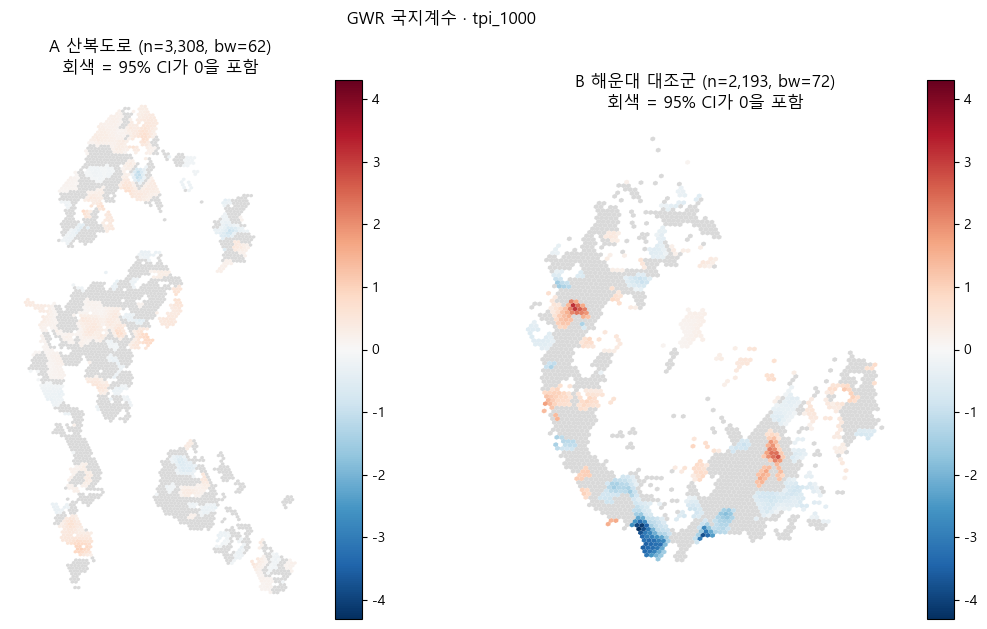

In [47]:
# TPI 국지계수 지도 -- A/B 각각, 유의하지 않은 셀은 회색으로 눌러서 "점추정 아님"을 시각화
TPI_VAR = next(v for v in XV if v.startswith("tpi_"))   # X2의 기준 TPI 변수(현재 tpi_1000)
gwr_b_tpi = f"gwr_b_{TPI_VAR}"
tpi_idx = XV.index(TPI_VAR) + 1
sub_A[gwr_b_tpi] = gwr_A.betas[:, tpi_idx]
sub_A["tpi_sig"] = (gwr_A.ci_lower[:, tpi_idx] > 0) | (gwr_A.ci_upper[:, tpi_idx] < 0)
sub_B[gwr_b_tpi] = gwr_B.betas[:, tpi_idx]
sub_B["tpi_sig"] = (gwr_B.ci_lower[:, tpi_idx] > 0) | (gwr_B.ci_upper[:, tpi_idx] < 0)

gA = hex_geom[["hex_id", "geometry"]].merge(sub_A[["hex_id", gwr_b_tpi, "tpi_sig"]], on="hex_id", how="inner")
gB = hex_geom[["hex_id", "geometry"]].merge(sub_B[["hex_id", gwr_b_tpi, "tpi_sig"]], on="hex_id", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
vmax = max(gA[gwr_b_tpi].abs().max(), gB[gwr_b_tpi].abs().max())
for ax, g, label in [(axes[0], gA, f"A 산복도로 (n={len(sub_A):,}, bw={bw_A})"),
                      (axes[1], gB, f"B 해운대 대조군 (n={len(sub_B):,}, bw={bw_B})")]:
    g[~g.tpi_sig].plot(ax=ax, color="#d9d9d9", linewidth=0)
    sig = g[g.tpi_sig]
    if len(sig):
        sig.plot(column=gwr_b_tpi, cmap="RdBu_r", vmin=-vmax, vmax=vmax, legend=True, linewidth=0, ax=ax)
    ax.set_title(f"{label}\n회색 = 95% CI가 0을 포함"); ax.set_axis_off()
fig.suptitle(f"GWR 국지계수 · {TPI_VAR}", fontsize=12)
fig.savefig(OUT / "figs" / "fig5b_gwr_target_ci_map.png", dpi=150, bbox_inches="tight")

In [48]:
sub_A.to_parquet(OUT / "tables" / "part5b_gwr_A_sanbokdoro.parquet", index=False)
sub_B.to_parquet(OUT / "tables" / "part5b_gwr_B_haeundae.parquet", index=False)
CFG.update(
    target_A_n=int(mask_A.sum()), target_B_n=int(mask_B.sum()),
    target_A_bw=int(bw_A), target_B_bw=int(bw_B),
    target_A_local_r2=float(gwr_A.local_r2.mean()), target_B_local_r2=float(gwr_B.local_r2.mean()),
    target_interaction_F=float(ftest_t.fvalue), target_interaction_p=float(ftest_t.pvalue),
)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Step 5B 저장 완료")

Step 5B 저장 완료


## Step 6 — 열섬 원인 유형 분류

대상은 **HH 셀만**(Step3에서 확정한 열섬 핵, `is_hh`). "열섬 핵이 모두 같은 이유로 뜨거운 것이 아니다"를
데이터로 보이는 단계 — Step4의 상호작용검정으로 "지형 효과가 산지에서 강하다"는 걸 증명했다면,
여기서는 그 지형 효과가 **실제로 어느 열섬 핵에서 지배적인지**를 셀 단위로 분류한다.

임계값은 **부산 전체(df) 분포** 기준 사분위로 잡는다(HH 내부 분포로 잡으면 상대평가가 되어 해석이 흔들림).

In [49]:
hh = df[df.is_hh].copy()
print(f"HH 셀 {len(hh):,}개 (부산 전체 {len(df):,}셀 중 {len(hh)/len(df)*100:.1f}%)")

TPI_VAR = next(v for v in X2 if v.startswith("tpi_"))
q = {v: df[v].quantile([.25, .75]).to_dict() for v in
     [TPI_VAR, "slope_deg", "svf_terrain", "bcr", "vol_density", "ndvi_s2"]}

# 9/4 수정(옵션2) -- "지형형" 트리거를 svf_terrain 에서 slope_deg 로 교체한다.
# 배경: 9/3 svf_building_effect 오염을 근본 해결(svf_terrain_matched 재계산, 부록I)하자
# 오염된 svf_building_effect가 몰래 지니고 있던 지형 신호가 사라지면서 억제효과가 풀렸고,
# 그 결과 부록G의 M2(raw) svf_terrain 계수가 뒤집혔다.
#   svf_terrain  -0.630 -> +0.946  (단순상관도도 +0.252로 원래 양수 -- 옛 음수는
#                                    오염된 svf_building_effect가 만든 억제효과의 산물이었다)
# "하늘이 가려질수록 온난"이라는 8/31 채택 근거 자체가 사라져 svf_terrain을 트리거로
# 계속 쓸 수 없다. 대신 slope_deg를 채택한다 -- 부록G 산지vs평지 상호작용의 분할 기준
# 그 자체이고, 재계산 전후로 부호·VIF가 흔들리지 않는다(경사가 급할수록 냉기배출·바람길
# 차단 등 지형기작이 강해진다는 물리적 해석도 분명하다). 상위 25%(급경사)를 지형형으로 판정.
terrain = (hh.slope_deg >= q["slope_deg"][.75])
terrain_tpi_only = (hh[TPI_VAR] <= q[TPI_VAR][.25]) & ~terrain              # 참고 -- TPI는 이번에도 트리거 아님(부호 모순 그대로)
terrain_old_svf_only = (hh.svf_terrain <= q["svf_terrain"][.25]) & ~terrain  # 참고 -- 폐기된 8/31~9/3 정의와의 차이
bldg    = (hh.bcr >= q["bcr"][.75]) | (hh.vol_density >= q["vol_density"][.75])
green   = (hh.ndvi_s2 <= q["ndvi_s2"][.25])

hh["heat_type"] = np.select(
    [terrain & bldg, terrain & ~bldg, ~terrain & bldg, ~terrain & ~bldg & green],
    ["복합형", "지형형", "건물밀집형", "녹지결핍형"],
    default="기타",
)
print(hh.heat_type.value_counts().to_string())
print(f"\n(참고) 옛 svf_terrain 하위25% 정의였다면 지형형이었을 셀 중 새 slope_deg 정의에서 "
      f"빠진 셀 수(참고용, 더 이상 사용 안 함): {int(terrain_old_svf_only.sum()):,}개")
print(f"(참고) TPI 하위 25%인 셀 중 slope_deg 트리거에는 안 걸리는 셀 "
      f"{int(terrain_tpi_only.sum()):,}개 -- TPI는 이번에도 트리거로 채택하지 않음(부호 모순 여전)")
CFG["heat_type_thresholds"] = q
CFG["step6_terrain_trigger_9_4"] = "slope_deg_top_quartile (svf_terrain 부호반전으로 9/3 폐기, 옵션2 채택)"

HH 셀 14,264개 (부산 전체 64,915셀 중 22.0%)
heat_type
건물밀집형    9171
기타       2211
지형형      1270
녹지결핍형    1119
복합형       493

(참고) 옛 svf_terrain 하위25% 정의였다면 지형형이었을 셀 중 새 slope_deg 정의에서 빠진 셀 수(참고용, 더 이상 사용 안 함): 572개
(참고) TPI 하위 25%인 셀 중 slope_deg 트리거에는 안 걸리는 셀 3,360개 -- TPI는 이번에도 트리거로 채택하지 않음(부호 모순 여전)


| 유형 | 판정 조건 | 열역학적 해석 |
|---|---|---|
| 지형형 | slope_deg 상위 25%, 건물은 보통 | 급경사면 지형기작(냉기배출·바람길 차단 등)이 지배적인 곳 |
| 건물밀집형 | bcr 또는 vol_density 상위 25%, 지형은 평범 | 축열량이 크고 건물이 복사냉각을 막는 곳 |
| 녹지결핍형 | 지형·건물 둘 다 아니고 ndvi_s2 하위 25% | 증발산에 의한 냉각이 결여된 곳 |
| 복합형 | 지형 조건과 건물 조건을 동시에 충족 (전형적으로 산복도로) | 두 메커니즘이 겹치는 곳 |

**복합형이 실제로 존재하는지가 Step4 결론의 공간적 확인**이다 -- Step4의 상호작용검정이 유의했다는 것은
"지형과 건물이 겹치는 곳에서 특히 강한 열섬이 나타난다"는 뜻이고, 그런 셀이 실제로 지도에 잡히는지 여기서 눈으로 확인한다.

**9/4 수정 — 지형형 트리거를 svf_terrain에서 slope_deg로 교체(옵션2)**: 8/31에는 부록G의 raw 계수가
`svf_terrain` -0.630(하늘이 가려질수록 온난 -- 물리적으로 타당)이라는 근거로 svf_terrain 단독 기준을
채택했다. 그런데 9/3에 `svf_building_effect`의 항등식 오염(부록I)을 근본 해결하기 위해 `svf_terrain`을
파트4와 동일 알고리즘으로 재계산하자, 오염된 svf_building_effect가 몰래 지니고 있던 지형 신호가
사라지면서 억제효과가 풀려 `svf_terrain` 계수가 +0.946으로 반전됐다(단순상관도도 +0.252로 원래 양수 --
옛 음수는 통계적 억제효과의 산물이었다). "하늘이 가려질수록 온난"이라는 8/31 채택 근거 자체가 무너져
svf_terrain을 트리거로 계속 쓸 수 없다.

대안으로 `slope_deg`를 채택한다 -- 부록G의 산지 vs 평지 상호작용 분할 기준 그 자체이고, 재계산
전후로 부호·VIF가 흔들리지 않는다(경사가 급할수록 냉기 배출·바람길 차단 등 지형기작이 강하게
작동한다는 해석도 분명하다). `tpi_1000`은 이번에도 트리거에서 제외한다 -- 계수 부호 모순(분지가
오히려 냉각 방향)이 재계산과 무관하게 그대로 남아 있기 때문이다.

In [50]:
# k-means 교차확인 -- 규칙 기반 분류가 데이터 구조와 어긋나지 않는지
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

CV = [TPI_VAR, "slope_deg", "bcr", "vol_density", "ndvi_s2"]   # 9/4: svf_terrain -> slope_deg (트리거 변경 반영)
Xk = StandardScaler().fit_transform(hh[CV])
hh["kmeans"] = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit_predict(Xk)

print(pd.crosstab(hh.heat_type, hh.kmeans))
print("\n군집별 변수 평균 (원단위)")
print(hh.groupby("kmeans")[CV].mean().round(3).to_string())

kmeans        0     1     2    3
heat_type                       
건물밀집형      5698   239  2298  936
기타            0   910  1301    0
녹지결핍형         0     0  1119    0
복합형         158   293    34    8
지형형           0  1252    18    0

군집별 변수 평균 (원단위)
        tpi_1000  slope_deg    bcr  vol_density  ndvi_s2
kmeans                                                  
0        -21.466      4.527  0.380        3.926    0.161
1         43.872     16.912  0.039        0.521    0.757
2        -10.386      3.451  0.092        1.301    0.326
3        -19.012      3.133  0.335       12.258    0.251


**교차표 읽는 법**: 규칙 기반 유형과 k-means 군집이 대각선(하나의 kmeans 라벨에 하나의 heat_type이 몰림)에
모이면 "데이터 주도 군집화로도 같은 구조가 재현되었다"는 근거가 된다. 흩어져 있으면 사분위 임계가 데이터
구조와 안 맞는 것이므로, 조정 여부와 이유를 `CFG`에 남긴다(여기서는 사전에 확정한 임계를 그대로 쓰고 결과만 기록).

저장: ..\data\part5\out\figs\fig6_heat_type.png


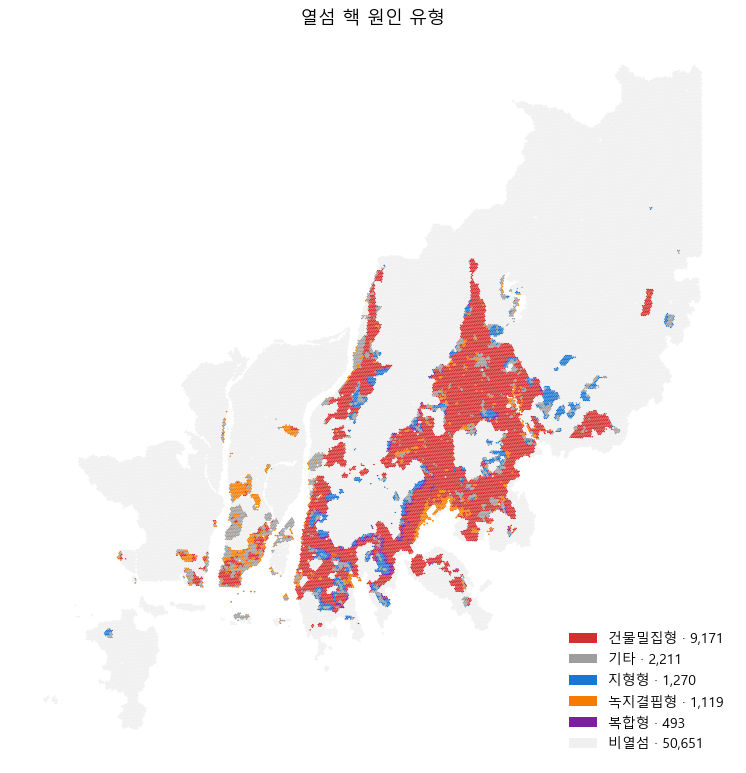

In [51]:
df = df.merge(hh[["hex_id", "heat_type", "kmeans"]], on="hex_id", how="left")
df["heat_type"] = df.heat_type.fillna("비열섬")

g = hex_geom[["hex_id", "geometry"]].merge(df[["hex_id", "heat_type"]], on="hex_id", how="inner")
TC = {"복합형": "#7b1fa2", "지형형": "#1976d2", "건물밀집형": "#d32f2f",
      "녹지결핍형": "#f57c00", "기타": "#9e9e9e", "비열섬": "#f0f0f0"}

# geopandas 의 .plot(color=) 는 범례 핸들을 등록하지 않는다 -- label= 을 줘도 범례가 빈 채로
# 나온다(9/11 발견). 핸들을 직접 만들어 넘긴다. 순서는 셀 수 많은 유형부터.
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9.5, 9.5))
_cnt = {}
for t, c in TC.items():
    s = g[g.heat_type == t]
    _cnt[t] = len(s)
    if len(s):
        s.plot(ax=ax, color=c, linewidth=0)
_ord = sorted([t for t in TC if _cnt[t] and t != "비열섬"], key=lambda t: -_cnt[t])
_ord += ["비열섬"] if _cnt.get("비열섬") else []
_handles = [Patch(facecolor=TC[t], label=f"{t} · {_cnt[t]:,}") for t in _ord]
ax.set_axis_off()
ax.legend(handles=_handles, loc="lower right", fontsize=10, frameon=False)
ax.set_title("열섬 핵 원인 유형", fontsize=13)
fig.savefig(OUT / "figs" / "fig6_heat_type.png", dpi=160, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig6_heat_type.png")

In [52]:
# 유형별 · 행정동별 분포 -- Step7에서 그대로 재사용
heat_by_dong = (hh.groupby(["adm_cd", "adm_nm", "heat_type"]).size()
                  .rename("cells").reset_index())
heat_dominant = (heat_by_dong.sort_values("cells", ascending=False)
                  .drop_duplicates("adm_cd")[["adm_cd", "adm_nm", "heat_type", "cells"]]
                  .rename(columns={"heat_type": "dominant_heat_type", "cells": "dominant_cells"}))
print("행정동별 지배적 열섬 유형 (상위 15)")
print(heat_dominant.sort_values("dominant_cells", ascending=False).head(15).to_string(index=False))

heat_by_dong.to_csv(OUT / "tables" / "part5_heat_type_by_dong.csv", index=False)
heat_dominant.to_csv(OUT / "tables" / "part5_heat_type_dominant_dong.csv", index=False)

CFG.update(heat_type_counts=hh.heat_type.value_counts().to_dict())
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("\nStep 6 저장 완료")

행정동별 지배적 열섬 유형 (상위 15)
    adm_cd adm_nm dominant_heat_type  dominant_cells
21120590.0   명지1동                 기타             327
21150650.0    감전동              건물밀집형             156
21070530.0   대연3동              건물밀집형             141
21070620.0   감만1동              건물밀집형             135
21100590.0   신평2동              건물밀집형             131
21150640.0    엄궁동              건물밀집형             123
21100600.0   장림1동              건물밀집형             119
21060510.0    수민동              건물밀집형             116
21060620.0   안락2동              건물밀집형             112
21110740.0   장전2동              건물밀집형             112
21150520.0   모라1동              건물밀집형             112
21130510.0   거제1동              건물밀집형             111
21130630.0   연산9동              건물밀집형             108
21120530.0    강동동              녹지결핍형             107
21080520.0   구포2동              건물밀집형             106

Step 6 저장 완료


## Step 7 — 취약계층 교차

**반드시 행정동 단위로 집계한 뒤 교차한다.** 열섬은 100m 격자, 사회통계는 행정동 단위다.
같은 표에 있다고 같은 단위가 아니다 — 격자 단위로 상관을 내면 같은 행정동 값이 수백 번
복제된 표본으로 계산되어 유의성이 터무니없이 부풀려진다(생태학적 오류, ecological fallacy).
그래서 이 절의 n은 64,915가 아니라 **행정동 수(206 내외)**다.

In [53]:
SOC = ["elderly_rate_dong", "basic_recip_rate_dong", "elderly_alone_dong", "old_house_rate_dong"]
SOC = [c for c in SOC if c in df.columns]

dong = (df.groupby(["adm_cd", "adm_nm"])
          .agg(n_cell=("hex_id", "size"),
               hh_cell=("is_hh", "sum"),
               lst_mean=(Y, "mean"),
               **{c: (c, "first") for c in SOC})
          .reset_index())
dong["hh_rate"] = dong.hh_cell / dong.n_cell

# Step6 지배적 열섬 유형을 행정동 표에 붙인다
dong = dong.merge(heat_dominant[["adm_cd", "dominant_heat_type", "dominant_cells"]],
                   on="adm_cd", how="left")
dong["dominant_heat_type"] = dong.dominant_heat_type.fillna("HH없음")

print(f"행정동 {len(dong)}개 (파트1 기준 206개와 대조)")
print(dong.nlargest(10, "hh_rate")[["adm_nm", "hh_rate", "lst_mean", "dominant_heat_type"] + SOC[:2]]
        .round(3).to_string(index=False))

행정동 206개 (파트1 기준 206개와 대조)
adm_nm  hh_rate  lst_mean dominant_heat_type  elderly_rate_dong  basic_recip_rate_dong
   동광동      1.0     1.879              건물밀집형              0.424                  0.203
   대청동      1.0     1.775              건물밀집형              0.337                  0.130
   부평동      1.0     1.839              건물밀집형              0.399                  0.137
   광복동      1.0     1.541              건물밀집형              0.402                  0.105
  영주1동      1.0     2.131              건물밀집형              0.291                  0.128
   부민동      1.0     1.759              건물밀집형              0.241                  0.079
   초장동      1.0     1.578                지형형              0.459                  0.220
  초량1동      1.0     2.025              건물밀집형              0.300                  0.137
  수정1동      1.0     2.167              건물밀집형              0.320                  0.126
  범일2동      1.0     2.127              건물밀집형              0.253                  0.117


In [54]:
from scipy.stats import spearmanr

print(f"행정동 단위 상관 (n = {len(dong)})")
corr_rows = []
for c in SOC:
    sub = dong[["hh_rate", c]].dropna()
    r, p = spearmanr(sub.hh_rate, sub[c])
    print(f"  hh_rate ~ {c:26s} rho = {r:+.3f}  p = {p:.4f}  n = {len(sub)}")
    corr_rows.append(dict(변수=c, rho=round(r, 4), p=float(p), n=len(sub)))
pd.DataFrame(corr_rows).to_csv(OUT / "tables" / "part5_dong_soc_corr.csv", index=False)

행정동 단위 상관 (n = 206)
  hh_rate ~ elderly_rate_dong          rho = -0.033  p = 0.6417  n = 206
  hh_rate ~ basic_recip_rate_dong      rho = +0.047  p = 0.5011  n = 205
  hh_rate ~ elderly_alone_dong         rho = -0.152  p = 0.0291  n = 206
  hh_rate ~ old_house_rate_dong        rho = +0.036  p = 0.6094  n = 206


**해석 주의**: 206개 표본의 상관이므로 rho가 유의해도(p<0.05) 크기 자체가 크지 않으면 정책적 함의는 조심스럽게
말해야 한다. 반대로 방향이 예상과 다르면(예: 고령비율이 낮은 곳이 열섬이 더 강함) "노후 저층주거지가 아니라
신축 고층 상업지에 열섬이 겹친다"는 식의 대안 해석이 필요하다 — Step6의 `dominant_heat_type`과 함께 보면
어느 유형의 열섬이 그 상관을 끌고 가는지 갈라볼 수 있다.

In [55]:
# 사분면 분류 -- 열섬 정도와 취약 정도의 조합 (기준 지표: 고령인구비율)
KEY = "elderly_rate_dong"
mh, mk = dong.hh_rate.median(), dong[KEY].median()
dong["quadrant"] = np.select(
    [(dong.hh_rate >= mh) & (dong[KEY] >= mk),
     (dong.hh_rate >= mh) & (dong[KEY] < mk),
     (dong.hh_rate < mh) & (dong[KEY] >= mk)],
    ["열섬↑취약↑", "열섬↑취약↓", "열섬↓취약↑"], default="열섬↓취약↓")

# 두 지표의 백분위 평균 -- 중첩 정도를 하나의 값으로
dong["overlap_score"] = (dong.hh_rate.rank(pct=True) + dong[KEY].rank(pct=True)) / 2
top = dong.sort_values("overlap_score", ascending=False).head(20)
print(top[["adm_nm", "hh_rate", KEY, "quadrant", "dominant_heat_type", "overlap_score"]]
        .round(3).to_string(index=False))

print("\n사분면별 행정동 수")
print(dong.quadrant.value_counts().to_string())

dong.sort_values("overlap_score", ascending=False)\
    .to_csv(OUT / "tables" / "part5_dong_cross.csv", index=False)

adm_nm  hh_rate  elderly_rate_dong quadrant dominant_heat_type  overlap_score
   초장동    1.000              0.459   열섬↑취약↑                지형형          0.942
   서1동    1.000              0.430   열섬↑취약↑              건물밀집형          0.920
   동광동    1.000              0.424   열섬↑취약↑              건물밀집형          0.917
   광복동    1.000              0.402   열섬↑취약↑              건물밀집형          0.900
   부평동    1.000              0.399   열섬↑취약↑              건물밀집형          0.893
  영선1동    1.000              0.398   열섬↑취약↑              건물밀집형          0.891
  감만2동    1.000              0.395   열섬↑취약↑              건물밀집형          0.883
   우암동    1.000              0.380   열섬↑취약↑              건물밀집형          0.867
   서2동    1.000              0.373   열섬↑취약↑              건물밀집형          0.862
  거제3동    1.000              0.352   열섬↑취약↑              건물밀집형          0.835
   아미동    0.905              0.412   열섬↑취약↑              건물밀집형          0.834
  부곡4동    1.000              0.345   열섬↑취약↑              건물밀집형  

저장: ..\data\part5\out\figs\fig7_cross.png


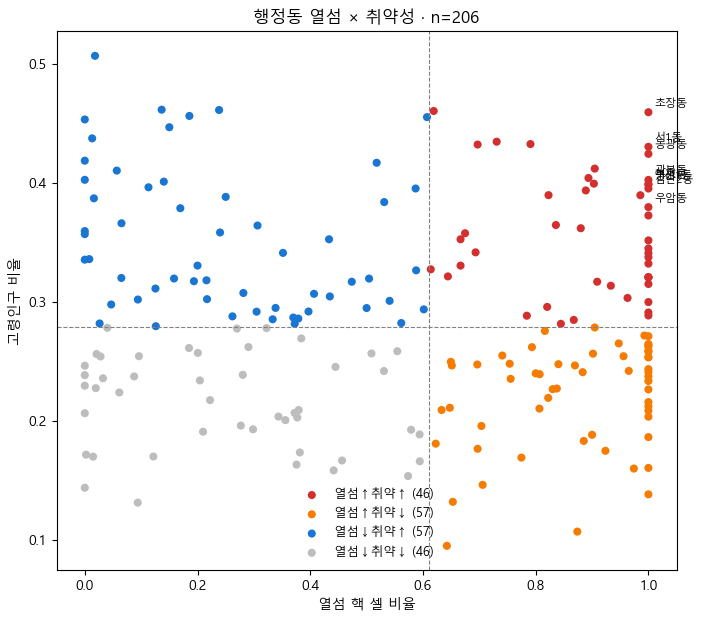

In [56]:
fig, ax = plt.subplots(figsize=(8, 7))
QC = {"열섬↑취약↑": "#d32f2f", "열섬↑취약↓": "#f57c00",
      "열섬↓취약↑": "#1976d2", "열섬↓취약↓": "#bdbdbd"}
for qd, c in QC.items():
    s = dong[dong.quadrant == qd]
    ax.scatter(s.hh_rate, s[KEY], c=c, s=34, label=f"{qd} ({len(s)})", edgecolor="none")
ax.axvline(mh, ls="--", c="gray", lw=.8); ax.axhline(mk, ls="--", c="gray", lw=.8)
for _, r in top.head(8).iterrows():
    ax.annotate(r.adm_nm, (r.hh_rate, r[KEY]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("열섬 핵 셀 비율"); ax.set_ylabel("고령인구 비율")
ax.set_title(f"행정동 열섬 × 취약성 · n={len(dong)}"); ax.legend(frameon=False, fontsize=9)
fig.savefig(OUT / "figs" / "fig7_cross.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig7_cross.png")

In [57]:
CFG.update(
    dong_soc_corr=corr_rows,
    quadrant_counts=dong.quadrant.value_counts().to_dict(),
    top20_overlap_dong=top[["adm_nm", "hh_rate", KEY, "quadrant"]].to_dict(orient="records"),
)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
df.to_parquet(OUT / "tables" / "part5_master_analyzed.parquet", index=False)
print("Step 7 저장 완료 -- df 최종본:", OUT / "tables" / "part5_master_analyzed.parquet")

Step 7 저장 완료 -- df 최종본: ..\data\part5\out\tables\part5_master_analyzed.parquet


## Step 8 — 개입 시나리오(what-if) · 센서 우선배치 · 정책 처방

`주제_가이드라인_수정본.html`(8/4, 최초 설계) 3-2절의 서술 원칙 4가지를 그대로 따른다.

1. **표현** — "인과 예측"이 아니라 "관측된 연관성 기반 시나리오"로 서술한다. GWR은 관측 데이터의 국지 상관을
   포착할 뿐, 실제로 녹지를 늘렸을 때 그만큼 식는다는 실험적 증거가 아니다.
2. **범위** — 점추정 금지. GWR 계수는 항상 95% 신뢰구간(Step5에서 이미 mgwr 대조검증된 `bse`)과 함께 낸다.
3. **보강** — 유사 셀 매칭(다른 조건은 비슷하고 녹지율만 실제로 더 높은 "쌍둥이 셀")으로 GWR 계수 외삽을 검증한다.
4. **한계** — 외삽은 관측 범위 안에서만 한다. 이미 NDVI가 부산 관측 최댓값에 가까운 셀에는 시나리오를 그대로 적용하지
   않고, 관측 최댓값까지만 늘리는 것으로 상한을 캡(cap)한다.

시나리오는 **NDVI(`ndvi_s2`) +0.10**(가이드라인 예시 "녹지 +10%"에 대응하는 실제 모델 변수) 이고,
대상은 **HH 셀(열섬 핵, Step3)** 로 한정한다 — 열섬이 아닌 곳에 녹지를 늘리는 시나리오는 정책적 의미가 약하다.

In [58]:
# 9/3 수정 (치명) -- gwr.betas/ci_lower/ci_upper 의 0번 열은 '절편'이다(셀 70의 `i + 1` 참조).
# 이전 XVi는 XV에 대한 0-based 인덱스여서 betas 열로 쓰면 한 칸씩 밀렸고,
#   ndvi_s2 자리 -> vol_density 계수,  bcr 자리 -> 절편  을 읽고 있었다.
# 이름을 XVb(betas 열 인덱스)로 바꿔, 남아 있는 잘못된 사용처가 있으면 NameError로 즉시 드러나게 한다.
XVb = {v: i + 1 for i, v in enumerate(XV)}
idx_ndvi = XVb["ndvi_s2"]
assert idx_ndvi == XV.index("ndvi_s2") + 1, "betas 열 인덱스 규약이 깨졌다"
std_ndvi = df["ndvi_s2"].std()          # Z 표준화에 쓴 것과 동일한 분모 (원단위 환산용)

mask_hh = df["is_hh"].to_numpy()
print(f"시나리오 대상 HH 셀: {mask_hh.sum():,}개")

# 표준화 계수(betas는 Z 기준 -> raw NDVI 1단위당 효과로 환산)
raw_beta = gwr.betas[mask_hh, idx_ndvi] / std_ndvi
raw_lo   = gwr.ci_lower[mask_hh, idx_ndvi] / std_ndvi
raw_hi   = gwr.ci_upper[mask_hh, idx_ndvi] / std_ndvi

print(f"NDVI 국지계수(원단위, degC per 1.0 NDVI): 평균 {raw_beta.mean():.3f}"
      f"  (95%CI 평균 {raw_lo.mean():.3f} ~ {raw_hi.mean():.3f})")

시나리오 대상 HH 셀: 14,264개
NDVI 국지계수(원단위, degC per 1.0 NDVI): 평균 0.001  (95%CI 평균 -1.064 ~ 1.066)


**원칙④ 구현 — 외삽 상한 캡**: 관측된 NDVI 최댓값을 넘어서는 시나리오는 만들지 않는다. 목표 델타(+0.10)가 그 셀에서 실현 불가능하면 실현 가능한 만큼만 적용하고 `capped` 로 표시한다.

In [59]:
DELTA_NDVI = 0.10
ndvi_now      = df.loc[mask_hh, "ndvi_s2"].to_numpy()
ndvi_max_obs  = df["ndvi_s2"].max()                      # 관측 범위 상한 (부산 전체 기준)
delta_used    = np.clip(np.minimum(DELTA_NDVI, ndvi_max_obs - ndvi_now), 0, None)
capped        = delta_used < (DELTA_NDVI - 1e-9)

print(f"NDVI 관측 최댓값 = {ndvi_max_obs:.3f}")
print(f"목표 델타(+{DELTA_NDVI}) 그대로 적용 가능: {(~capped).sum():,}개"
      f"  /  캡 적용(관측범위 초과라 델타 축소): {capped.sum():,}개"
      f"  (평균 축소 델타 {delta_used[capped].mean() if capped.any() else 0:.3f})")

NDVI 관측 최댓값 = 0.926
목표 델타(+0.1) 그대로 적용 가능: 13,142개  /  캡 적용(관측범위 초과라 델타 축소): 1,122개  (평균 축소 델타 0.070)


In [60]:
# 효과 = 국지계수(원단위) x 실현 가능한 델타. delta>=0 이므로 CI 순서는 그대로 보존된다.
effect_mean = raw_beta * delta_used
effect_lo   = np.minimum(raw_lo * delta_used, raw_hi * delta_used)
effect_hi   = np.maximum(raw_lo * delta_used, raw_hi * delta_used)

scen = pd.DataFrame({
    "hex_id": df.loc[mask_hh, "hex_id"].to_numpy(),
    "adm_nm": df.loc[mask_hh, "adm_nm"].to_numpy(),
    "heat_type": df.loc[mask_hh, "heat_type"].to_numpy(),
    "ndvi_now": ndvi_now, "delta_used": delta_used, "capped": capped,
    "effect_C": effect_mean, "ci_lo_C": effect_lo, "ci_hi_C": effect_hi,
})

print(f"HH 전체 평균 효과: {scen.effect_C.mean():+.3f} degC"
      f"  (개별 셀 95%CI 평균 {scen.ci_lo_C.mean():+.3f} ~ {scen.ci_hi_C.mean():+.3f})")
print("\n열섬 유형별 평균 효과 (원칙②: 점추정이 아니라 CI와 함께)")
by_type = (scen.groupby("heat_type")
             .agg(n=("hex_id", "size"),
                  effect_mean=("effect_C", "mean"),
                  ci_lo=("ci_lo_C", "mean"), ci_hi=("ci_hi_C", "mean"),
                  capped_frac=("capped", "mean"))
             .round(3).sort_values("effect_mean"))
print(by_type.to_string())
scen.to_csv(OUT / "tables" / "part5_whatif_ndvi_scenario.csv", index=False)
by_type.to_csv(OUT / "tables" / "part5_whatif_by_heat_type.csv")

HH 전체 평균 효과: -0.001 degC  (개별 셀 95%CI 평균 -0.103 ~ +0.102)

열섬 유형별 평균 효과 (원칙②: 점추정이 아니라 CI와 함께)
              n  effect_mean  ci_lo  ci_hi  capped_frac
heat_type                                              
녹지결핍형      1119       -0.005 -0.093  0.083        0.000
건물밀집형      9171       -0.004 -0.111  0.103        0.001
기타         2211        0.001 -0.083  0.086        0.175
복합형         493        0.008 -0.089  0.105        0.016
지형형        1270        0.018 -0.101  0.136        0.569


**읽는 법**: `녹지결핍형`에서 효과(냉각폭)가 가장 크게 나오면 -- "녹지가 원래 부족한 곳에 녹지를 늘리는 게
가장 효과적"이라는, 정의상 당연하지만 데이터로 재확인된 결과다. `지형형`·`복합형`처럼 지형이 지배적인 유형에서
효과가 작게 나오는 것도 자연스럽다 -- Step4·5의 결론("지형이 만드는 열섬은 녹지만으로 못 없앤다")과 일관된다.
매뉴얼이 예시로 든 "-0.3~-0.7°C"와 크기가 다르게 나올 수 있는데, 그 예시는 가상의 숫자이지 이 프로젝트의
실측치가 아니므로 **여기서 나온 실제 수치를 그대로 보고**한다.

저장: ..\data\part5\out\figs\fig8_whatif_effect.png


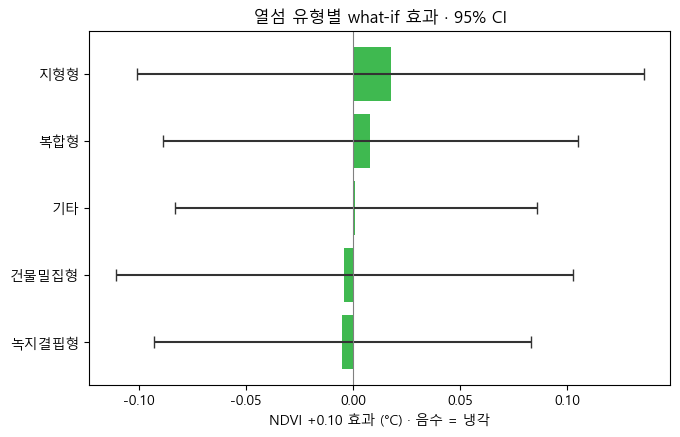

In [61]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
bt = by_type.reset_index()
yerr = np.vstack([bt.effect_mean - bt.ci_lo, bt.ci_hi - bt.effect_mean])
ax.barh(bt.heat_type, bt.effect_mean, xerr=yerr, color="#3fb950", ecolor="#333", capsize=4)
ax.axvline(0, color="gray", lw=.8)
ax.set_xlabel("NDVI +0.10 효과 (°C) · 음수 = 냉각")
ax.set_title("열섬 유형별 what-if 효과 · 95% CI")
fig.savefig(OUT / "figs" / "fig8_whatif_effect.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig8_whatif_effect.png")

### 원칙③ — 유사 셀 매칭으로 외삽 검증

GWR 국지계수로 예측한 효과가 "그럴듯한 숫자"가 아니라 실제 데이터 패턴과 맞는지를,
**모형을 전혀 쓰지 않고** 확인한다: 냉각 효과가 크게 예측된 HH 셀마다, 다른 설명변수(건물·불투수·지형)는
비슷하면서 NDVI만 실제로 더 높은 "쌍둥이 셀"을 부산 전체에서 찾아 관측된 야간 anomaly 차이를 직접 비교한다.
GWR 예측과 방향·크기가 맞으면 외삽이 아니라 데이터에 실재하는 패턴이라는 근거가 된다.

In [62]:
from sklearn.neighbors import NearestNeighbors

OTHERV = [v for v in XV if v != "ndvi_s2"]
Zoth_all = Z[OTHERV].to_numpy(float)          # 부산 전체(64,915) 표준화 공변량 -- 매칭 후보 풀
ndvi_all = df["ndvi_s2"].to_numpy()
lst_all  = df[Y].to_numpy()

# 예측 냉각효과가 큰 순으로 상위 N개 HH 셀에서만 매칭 검증 (전수는 느리고 불필요)
N_CHECK = 300
hh_rows = np.where(mask_hh)[0]
order = hh_rows[np.argsort(effect_mean)][:N_CHECK]     # effect_mean이 가장 음수(냉각 큼)인 순

MIN_GAP = 0.08   # "의미 있게 더 푸른" 쌍둥이만 인정 (관측범위 내 매칭, 원칙④와 동일 취지)
rows = []
for i in order:
    cand = np.where(ndvi_all >= ndvi_all[i] + MIN_GAP)[0]
    if len(cand) == 0:
        continue
    d = np.linalg.norm(Zoth_all[cand] - Zoth_all[i], axis=1)
    j = cand[d.argmin()]
    pred_delta_ndvi = ndvi_all[j] - ndvi_all[i]
    pred_diff = (gwr.betas[i, idx_ndvi] / std_ndvi) * pred_delta_ndvi
    obs_diff  = lst_all[j] - lst_all[i]
    rows.append(dict(hex_id=df.hex_id.iloc[i], twin_hex_id=df.hex_id.iloc[j],
                      match_dist=float(d.min()), delta_ndvi=pred_delta_ndvi,
                      pred_diff_C=pred_diff, obs_diff_C=obs_diff))

twins = pd.DataFrame(rows)
r_val = twins[["pred_diff_C", "obs_diff_C"]].corr().iloc[0, 1]
sign_match = ((twins.pred_diff_C < 0) == (twins.obs_diff_C < 0)).mean()
print(f"매칭된 쌍 {len(twins):,}개 (요청 {N_CHECK}개 중 후보 없어 제외된 것 제외)")
print(f"예측 vs 관측 효과 상관 r = {r_val:.3f}")
print(f"부호 일치율(둘 다 냉각 방향) = {sign_match*100:.1f}%")
print(f"평균 매칭거리(표준화 공변량 유클리드) = {twins.match_dist.mean():.3f}  (0에 가까울수록 '쌍둥이'에 가까움)")
twins.to_csv(OUT / "tables" / "part5_whatif_twin_validation.csv", index=False)

매칭된 쌍 274개 (요청 300개 중 후보 없어 제외된 것 제외)
예측 vs 관측 효과 상관 r = 0.132
부호 일치율(둘 다 냉각 방향) = 79.2%
평균 매칭거리(표준화 공변량 유클리드) = 0.959  (0에 가까울수록 '쌍둥이'에 가까움)


**해석 기준**: `r`이 양수이고 부호 일치율이 50%를 뚜렷이 넘으면(예: 65%↑) — "GWR이 예측한 방향으로 실제
더 푸른 유사 셀이 실제로 더 서늘하다"는 것이 확인된 것이고, 이는 원칙③이 요구하는 최소한의 외부 검증이다.
`r`이 낮거나 부호 일치율이 50%에 가까우면 이 시나리오의 신뢰 구간을 실제보다 넓게(더 보수적으로) 서술해야
한다 — 매칭거리가 크다면(공변량이 실제로는 안 비슷한 "가짜 쌍둥이") 그 자체가 한계로 기록되어야 한다.

### 8/31 보완 — 신뢰구간이 실제로 0을 벗어나는 효과크기 두 가지

위 GWR 국지계수 기반 시나리오는 5개 유형 전부 95%CI가 0을 포함했다. 원인은 효과가 없어서가 아니라
**GWR이 셀마다 이웃 63개(bw=63)만으로 계수를 따로 추정**해서 개별 추정치의 통계적 힘이 원래 작기
때문이다(참고로 Step2 전역 OLS의 `ndvi_s2` 계수는 t=−9.4로 강하게 유의하다 — n=64,915 전체로 보면
신호가 뚜렷하다는 뜻). 셀 단위 정밀도를 포기하는 대신, 통계적 힘을 확보하는 두 가지 독립적인 방법으로
같은 시나리오(NDVI +0.10, 관측범위 캡 동일 적용)를 다시 계산한다.

In [63]:
# 1) 열섬유형별 풀링 회귀 -- GWR의 국지(n=63) 대신 유형별 부분표본(n=493~9,171)에 M2를 다시 적합
delta_by_hex = scen.set_index("hex_id")["delta_used"]

pool_rows = []
for ht, sub in df[mask_hh].groupby("heat_type"):
    if len(sub) < 30:
        continue
    m = smf.ols(f2, data=sub).fit()
    b, se = m.params["ndvi_s2"], m.bse["ndvi_s2"]
    ci = m.conf_int().loc["ndvi_s2"]
    d = delta_by_hex.reindex(sub["hex_id"]).mean()   # 그 유형의 평균 실현 델타(캡 반영)
    pool_rows.append(dict(heat_type=ht, n=len(sub), coef=b, se=se,
                           coef_ci_lo=ci[0], coef_ci_hi=ci[1], mean_delta=d,
                           effect_mean=b * d, effect_ci_lo=ci[0] * d, effect_ci_hi=ci[1] * d))

pooled = pd.DataFrame(pool_rows).sort_values("effect_mean")
print("열섬유형별 풀링회귀 NDVI+0.10 효과 (GWR 대비 표본 10~140배, 훨씬 강한 통계력)")
print(pooled.round(4).to_string(index=False))
pooled.to_csv(OUT / "tables" / "part5_whatif_pooled_by_type.csv", index=False)

열섬유형별 풀링회귀 NDVI+0.10 효과 (GWR 대비 표본 10~140배, 훨씬 강한 통계력)
heat_type    n    coef     se  coef_ci_lo  coef_ci_hi  mean_delta  effect_mean  effect_ci_lo  effect_ci_hi
    건물밀집형 9171 -0.4183 0.0425     -0.5016     -0.3349      0.1000      -0.0418       -0.0502       -0.0335
       기타 2211 -0.3353 0.0712     -0.4749     -0.1956      0.0950      -0.0318       -0.0451       -0.0186
      지형형 1270 -0.2295 0.1189     -0.4626      0.0037      0.0827      -0.0190       -0.0383        0.0003
      복합형  493 -0.0453 0.1373     -0.3150      0.2244      0.0995      -0.0045       -0.0313        0.0223
    녹지결핍형 1119  0.2216 0.1239     -0.0215      0.4647      0.1000       0.0222       -0.0022        0.0465


In [64]:
# 2) 매칭쌍(twins)의 실측 온도차 자체를 모델 계수 없이 직접 요약 -- 설계기반(design-based) 검증
import scipy.stats as st

obs = twins["obs_diff_C"].to_numpy()
mean_obs = obs.mean()
se_obs = obs.std(ddof=1) / np.sqrt(len(obs))
ci_obs = st.t.interval(0.95, len(obs) - 1, loc=mean_obs, scale=se_obs)

print(f"매칭쌍(n={len(obs)}) 실측 온도차 평균 = {mean_obs:+.4f} degC   "
      f"95%CI = [{ci_obs[0]:+.4f}, {ci_obs[1]:+.4f}]")
print(f"(참고) 이 쌍들에 대한 GWR 예측 평균 = {twins['pred_diff_C'].mean():+.4f} degC -- 방향·크기 비교용")

# --- 9/2 보완: 이 수치를 풀링회귀와 같은 눈금에 올리기 위한 ΔNDVI 환산 ---
# 매칭은 "NDVI가 최소 +0.08 더 높은 최근접 이웃"을 붙였을 뿐이라 실제 ΔNDVI가 시나리오(+0.10)보다 크다.
# 크기가 다른 처치를 비교하면 안 되므로, 쌍별로 +0.10 기준 선형 환산해서 같은 기준으로 맞춘다.
d_ndvi = twins["delta_ndvi"].to_numpy()
per010 = obs / d_ndvi * DELTA_NDVI
mean_per010 = per010.mean()
se_per010 = per010.std(ddof=1) / np.sqrt(len(per010))
ci_per010 = st.t.interval(0.95, len(per010) - 1, loc=mean_per010, scale=se_per010)

print(f"\n매칭쌍 평균 ΔNDVI = {d_ndvi.mean():+.4f}  (시나리오 {DELTA_NDVI:+.2f}의 {d_ndvi.mean()/DELTA_NDVI:.1f}배)")
print(f"  -> ΔNDVI를 +{DELTA_NDVI:.2f}로 환산한 매칭쌍 실측효과 = {mean_per010:+.4f} degC   "
      f"95%CI = [{ci_per010[0]:+.4f}, {ci_per010[1]:+.4f}]")
print(f"  -> 환산 후에도 풀링회귀(건물밀집형 {pooled.effect_mean.min():+.4f})보다 크다. 남은 격차의 정체는")
print(f"     '표본 선별'이다 -- 매칭쌍은 예측 냉각효과 상위 {N_CHECK}개 HH셀만 고른 극단 표본이므로")
print(f"     전체 평균이 아니라 '가장 잘 먹히는 입지에서의 상한'으로만 인용해야 한다.")

CFG["whatif_twin_obs_mean"] = float(mean_obs)
CFG["whatif_twin_obs_ci"] = [float(ci_obs[0]), float(ci_obs[1])]
CFG["whatif_twin_delta_ndvi_mean"] = float(d_ndvi.mean())
CFG["whatif_twin_per010_mean"] = float(mean_per010)
CFG["whatif_twin_per010_ci"] = [float(ci_per010[0]), float(ci_per010[1])]
CFG["whatif_pooled_by_type"] = pooled.round(4).to_dict(orient="records")
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")


매칭쌍(n=274) 실측 온도차 평균 = -0.5784 degC   95%CI = [-0.6613, -0.4954]
(참고) 이 쌍들에 대한 GWR 예측 평균 = -0.3460 degC -- 방향·크기 비교용

매칭쌍 평균 ΔNDVI = +0.1269  (시나리오 +0.10의 1.3배)
  -> ΔNDVI를 +0.10로 환산한 매칭쌍 실측효과 = -0.5216 degC   95%CI = [-0.6070, -0.4362]
  -> 환산 후에도 풀링회귀(건물밀집형 -0.0418)보다 크다. 남은 격차의 정체는
     '표본 선별'이다 -- 매칭쌍은 예측 냉각효과 상위 300개 HH셀만 고른 극단 표본이므로
     전체 평균이 아니라 '가장 잘 먹히는 입지에서의 상한'으로만 인용해야 한다.


9402

저장: ..\data\part5\out\figs\fig8b_whatif_pooled_compare.png
패널B 앵커: 전체평균 -0.042 / 환산 -0.522 / 원자료 -0.578


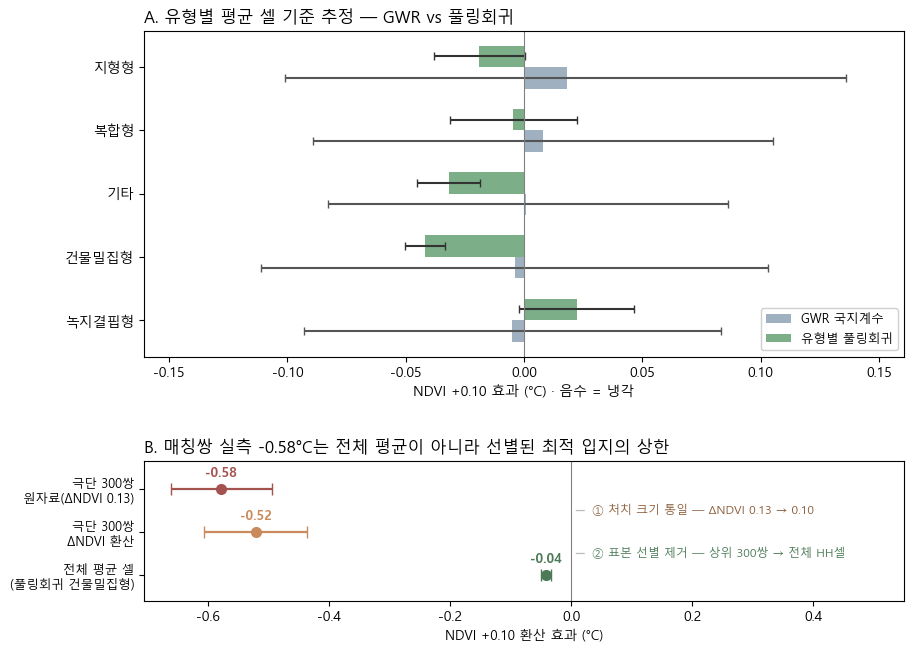

In [65]:
# 9/2 수정: 매칭쌍 실측치를 같은 축의 기준선으로 그리면 (a) 유형별 추정치가 짜부라지고
# (b) "녹지 = 1도 냉각"으로 오독된다. 축을 분리하고, 두 수치가 갈라지는 이유를 아래 패널에서 분해한다.
fig = plt.figure(figsize=(9.8, 7.4))
gs = fig.add_gridspec(2, 1, height_ratios=[2.45, 1.05], hspace=0.45)

# ---------- Panel A: 유형별 평균 셀 기준 모델 추정 (매칭쌍 기준선 제거) ----------
axA = fig.add_subplot(gs[0])
bt2 = by_type.reset_index()
merged = bt2.merge(pooled, on="heat_type", suffixes=("_gwr", "_pool"))
x = np.arange(len(merged)); barw = 0.34

axA.barh(x - barw / 2, merged.effect_mean_gwr, height=barw,
         xerr=[merged.effect_mean_gwr - merged.ci_lo, merged.ci_hi - merged.effect_mean_gwr],
         label="GWR 국지계수", color="#9fb0c0", ecolor="#555", capsize=3)
axA.barh(x + barw / 2, merged.effect_mean_pool, height=barw,
         xerr=[merged.effect_mean_pool - merged.effect_ci_lo, merged.effect_ci_hi - merged.effect_mean_pool],
         label="유형별 풀링회귀", color="#7cae87", ecolor="#333", capsize=3)
axA.axvline(0, color="gray", lw=.8)
axA.set_yticks(x); axA.set_yticklabels(merged.heat_type)
_lim = float(np.max(np.abs(np.r_[merged.ci_lo, merged.ci_hi,
                                 merged.effect_ci_lo, merged.effect_ci_hi]))) * 1.18
axA.set_xlim(-_lim, _lim)
axA.set_xlabel("NDVI +0.10 효과 (°C) · 음수 = 냉각")
axA.set_title("A. 유형별 평균 셀 기준 추정 — GWR vs 풀링회귀", loc="left", fontsize=12)
axA.legend(fontsize=9, loc="lower right", framealpha=.92)

# ---------- Panel B: 매칭쌍 실측치가 왜 훨씬 커 보이는지 분해 ----------
axB = fig.add_subplot(gs[1])
_pool_best = pooled.sort_values("effect_mean").iloc[0]

anchors = [
    (_pool_best.effect_mean, _pool_best.effect_ci_lo, _pool_best.effect_ci_hi,
     f"전체 평균 셀\n(풀링회귀 {_pool_best.heat_type})", "#4c7a57"),
    (mean_per010, ci_per010[0], ci_per010[1],
     "극단 300쌍\nΔNDVI 환산", "#c98a5c"),
    (mean_obs, ci_obs[0], ci_obs[1],
     f"극단 300쌍\n원자료(ΔNDVI {d_ndvi.mean():.2f})", "#a3524f"),
]
ys = np.arange(len(anchors))
for yi, (m, lo, hi, lab, col) in zip(ys, anchors):
    axB.errorbar(m, yi, xerr=[[m - lo], [hi - m]], fmt="o", ms=7,
                 color=col, ecolor=col, elinewidth=1.6, capsize=4, zorder=3)
    axB.annotate(f"{m:+.2f}", (m, yi), textcoords="offset points", xytext=(0, 9),
                 ha="center", fontsize=9.5, color=col, fontweight="bold")

axB.axvline(0, color="gray", lw=.8)
axB.set_yticks(ys); axB.set_yticklabels([a[3] for a in anchors], fontsize=9)
axB.set_ylim(-0.6, len(anchors) - 0.35)
axB.set_xlim(mean_obs * 1.22, abs(mean_obs) * 0.95)

_tx = abs(mean_obs) * 0.06
axB.text(_tx, 1.5, f"① 처치 크기 통일 — ΔNDVI {d_ndvi.mean():.2f} → 0.10",
         fontsize=8.6, va="center", color="#8a5c39")
axB.text(_tx, 0.5, "② 표본 선별 제거 — 상위 300쌍 → 전체 HH셀",
         fontsize=8.6, va="center", color="#4c7a57")
for _y in (1.5, 0.5):
    axB.annotate("", xy=(_tx * 0.75, _y), xytext=(_tx * 0.1, _y),
                 arrowprops=dict(arrowstyle="-", color="#bbb", lw=.9))
axB.set_xlabel("NDVI +0.10 환산 효과 (°C)", fontsize=9.5)
axB.set_title(f"B. 매칭쌍 실측 {mean_obs:.2f}°C는 전체 평균이 아니라 선별된 최적 입지의 상한",
              loc="left", fontsize=12)

fig.savefig(OUT / "figs" / "fig8b_whatif_pooled_compare.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig8b_whatif_pooled_compare.png")
print(f"패널B 앵커: 전체평균 {_pool_best.effect_mean:+.3f} / 환산 {mean_per010:+.3f} / 원자료 {mean_obs:+.3f}")


**읽는 법(패널 A)**: 풀링회귀의 95%CI가 0을 벗어나는 유형(표본이 큰 건물밀집형·기타)은
"이 유형에서는 평균적으로 NDVI+0.10이 통계적으로 유의한 냉각 효과를 가진다"고 말할 수 있다 —
단, "이 특정 셀"이 아니라 **"이 유형의 평균 셀"**에 대한 진술이라는 정밀도 손실을 함께 명시한다.
여전히 0을 포함하는 유형은 그 결과도 숨기지 않고 그대로 보고한다 — "유형별로 봐도 정밀한 °C를
못 짚어낸다"는 것 역시 정직한 결론이다.

**⚠️ 9/3 정정 — 옛 −1.0°C는 버그가 만든 값이었다.** 매칭쌍을 "예측 냉각효과 상위"로 골랐는데,
그 예측이 GWR betas 열 인덱스 밀림 때문에 `ndvi_s2`가 아니라 `vol_density`의 국지계수로 계산되고
있었다(위 코드 주석 참조). 선별 기준 자체가 무의미했던 것이다. 인덱스를 고친 뒤 같은 절차로 다시
뽑은 값이 위 출력이며, **−0.998°C는 재현되지 않는다. 옛 문서·슬라이드에 −1.0°C가 남아 있으면 전부 교체한다.**

**읽는 법(패널 B) — 왜 매칭쌍이 풀링회귀보다 훨씬 큰가**: 두 수치를 나란히 놓으면 한 자릿수 차이라
"둘 중 하나는 틀렸다"로 보이지만, 사실은 **서로 다른 것의 평균**이다. 격차는 두 단계로 분해된다.

1. **처치 크기가 다르다.** 매칭은 "NDVI가 최소 +0.08 더 높은 최근접 이웃"을 붙였을 뿐이라 실제
   ΔNDVI가 시나리오(+0.10)보다 크다. 쌍별로 +0.10 기준 환산한 값이 위 출력의 '환산' 수치다.
2. **표본이 극단이다.** 매칭쌍은 무작위 표본이 아니라 *예측 냉각효과 상위 HH셀*만 고른 것이다.
   환산 후에도 남는 격차가 이 **입지 선별 프리미엄**이다. 여기엔 매칭 잔차 교란도 섞여 있다 —
   평균 매칭거리가 커진 만큼 "가짜 쌍둥이" 비중이 높다는 점을 한계로 함께 적는다.

따라서 두 수치는 경쟁 관계가 아니라 **범위의 양 끝**으로 인용한다 — 하한은 전면 적용 시의 보수적
기대치(통계적으로 유의), 상한은 우선순위대로 잘 고른 입지에서 관측된 천장. 실제 사업 효과는 이
사이에 있고, **"어디에 심느냐"가 그 차이를 만든다** — 우선순위 지도가 필요한 이유다.

### 센서 우선배치 후보

`주제_가이드라인_수정본.html` 3-3절 원칙: **GWR 국지 R²가 낮은 셀 = 모델이 설명하지 못하는 곳 =
실측이 가장 필요한 곳.** Step5에서 계산한 `low_fit`(국지R² 하위 10%)을 HH 셀에 한정해 우선순위를 낸다.


In [66]:
sensor_cand = df[df.is_hh & df.low_fit]
print(f"센서 우선배치 후보(HH & 국지R² 하위10%): {len(sensor_cand):,}셀")

sensor_dong = (sensor_cand.groupby(["adm_cd", "adm_nm"]).size()
                 .rename("cells").reset_index()
                 .sort_values("cells", ascending=False))
print(sensor_dong.head(15).to_string(index=False))
sensor_dong.to_csv(OUT / "tables" / "part5_sensor_priority_dong.csv", index=False)

sensor_cells = sensor_cand.nsmallest(30, "local_r2")[
    ["hex_id", "adm_nm", "heat_type", "local_r2", "lst_night_anom", "x", "y"]]
sensor_cells.to_csv(OUT / "tables" / "part5_sensor_priority_cells.csv", index=False)
print(f"\n국지R² 최하위 30개 셀 저장 완료 (좌표 포함, 실제 설치 후보지)")

센서 우선배치 후보(HH & 국지R² 하위10%): 1,081셀
    adm_cd adm_nm  cells
21070530.0   대연3동     77
21030530.0   초량3동     38
21050520.0   부전2동     36
21090690.0    좌4동     35
21030680.0   범일5동     34
21100600.0   장림1동     33
21130620.0   연산8동     31
21120600.0   명지2동     31
21150640.0    엄궁동     31
21120590.0   명지1동     28
21070620.0   감만1동     27
21120520.0   대저2동     26
21150510.0    삼락동     24
21150650.0    감전동     23
21050820.0   부전1동     22

국지R² 최하위 30개 셀 저장 완료 (좌표 포함, 실제 설치 후보지)


### 유형별 정책 처방 매핑

`주제_가이드라인_수정본.html` 3-4절 표를 Step6·7 결과에 직접 연결한다. 취약계층(`열섬↑취약↑` 사분면)
행정동에는 그늘막·쿨링포그 처방을 추가로 얹는다(Step7에서 지적한 "열섬-취약계층 미스매치" 문제에 대한 응답).

In [67]:
PRESCRIPTION = {
    "건물밀집형":  "쿨루프 · 차열포장, 건폐율 관리",
    "지형형":      "바람길 확보, 사면 녹지축",
    "녹지결핍형":  "가로수 · 소공원 우선 배치",
    "복합형":      "지형+건물 처방 병행 (바람길 확보 + 쿨루프)",
    "기타":        "추가 현장조사 필요 (원인 불명확)",
    "HH없음":      "-",
}
dong["prescription"] = dong["dominant_heat_type"].map(PRESCRIPTION).fillna("-")
vulnerable = dong["quadrant"] == "열섬↑취약↑"
dong.loc[vulnerable, "prescription"] = (
    dong.loc[vulnerable, "prescription"] + " + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)"
)

policy = dong[["adm_nm", "hh_rate", "elderly_rate_dong", "quadrant",
               "dominant_heat_type", "prescription"]].sort_values("hh_rate", ascending=False)
print(policy.head(20).round(3).to_string(index=False))
policy.to_csv(OUT / "tables" / "part5_policy_prescription.csv", index=False)

adm_nm  hh_rate  elderly_rate_dong quadrant dominant_heat_type                                   prescription
   동광동      1.0              0.424   열섬↑취약↑              건물밀집형 쿨루프 · 차열포장, 건폐율 관리 + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)
   대청동      1.0              0.337   열섬↑취약↑              건물밀집형 쿨루프 · 차열포장, 건폐율 관리 + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)
   광복동      1.0              0.402   열섬↑취약↑              건물밀집형 쿨루프 · 차열포장, 건폐율 관리 + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)
   부평동      1.0              0.399   열섬↑취약↑              건물밀집형 쿨루프 · 차열포장, 건폐율 관리 + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)
  영주1동      1.0              0.291   열섬↑취약↑              건물밀집형 쿨루프 · 차열포장, 건폐율 관리 + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)
   수민동      1.0              0.258   열섬↑취약↓              건물밀집형                             쿨루프 · 차열포장, 건폐율 관리
  범일2동      1.0              0.253   열섬↑취약↓              건물밀집형                             쿨루프 · 차열포장, 건폐율 관리
   좌천동      1.0              0.341   열섬↑취약↑              건물밀집형 쿨루프 · 차열포장, 건폐율 관리 + 그늘막·쿨링포그, 쉼터 재배치(취약계층 밀집)
  영선1동    

In [68]:
CFG.update(
    whatif_delta_ndvi=DELTA_NDVI,
    whatif_hh_effect_mean=float(scen.effect_C.mean()),
    whatif_hh_effect_ci=[float(scen.ci_lo_C.mean()), float(scen.ci_hi_C.mean())],
    whatif_by_heat_type=by_type.reset_index().to_dict(orient="records"),
    whatif_capped_frac=float(scen.capped.mean()),
    whatif_twin_r=float(r_val), whatif_twin_sign_match=float(sign_match), whatif_twin_n=int(len(twins)),
    sensor_priority_cells=int(len(sensor_cand)),
)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Step 8 저장 완료")

Step 8 저장 완료


# 부록 — 가이드라인 대조 보완 (추가 검증)

`주제_가이드라인_수정본.html`(8/4, 최초 설계) 대조 검증에서 새로 발견된 항목을 이어서 처리한다.
Step0~8은 이미 완료·저장된 상태이며, 아래는 그 결과를 지우거나 다시 계산하지 않고 **추가로 검증만** 한다.

- 부록 A — Step2 보조: OLS(M1) 잔차가 경사지에 집중되는지 (선정 근거 아님, 보조 신호로만)
- 부록 B — Step4 강건성: 공간오차모형(SEM/ML) 기반으로 "지형 블록 추가기여"를 다시 확인

> Step6 분류의 강건성은 **LCZ 노트북**(`part5b_lcz_analysis.ipynb`)이 국제표준 분류로 확인한다.
> GWR 국지계수 기반 대안분류는 부록 J-6에서 **건물 변수 국지계수가 정규화로 정해짐**이 드러나 폐기했다.

## 부록 A — OLS(M1) 잔차가 경사지에 집중되는가

`주제_가이드라인_수정본.html` 2-2절: "1차 전역 OLS 잔차가 경사지에 집중되는지 확인 -- **선정 근거로 격상시키지
않고 보조 그림으로만 사용**". M1(건물·피복만)이 지형을 모르는 채로 남긴 잔차가 경사와 상관이 있다면,
그 자체가 "건물·피복만으로는 산지에서 뭔가 빠진다"는 사전 신호이고, Step4의 결론과 방향이 맞는지 보는 것이다.

OLS(M1) 잔차 vs 경사도  Spearman rho = +0.113  p = 1.804e-183  (n=64,915)

경사 10분위별 M1 평균 잔차 (양수 = 실제가 M1 예측보다 더 더움 = M1이 못 잡아낸 온도)
slope_deg
(-0.001, 0.267]    -0.1292
(0.267, 0.854]      0.1172
(0.854, 2.893]      0.0033
(2.893, 5.887]     -0.1881
(5.887, 8.816]     -0.1336
(8.816, 11.578]    -0.0653
(11.578, 14.308]    0.0200
(14.308, 17.232]    0.0850
(17.232, 21.106]    0.1155
(21.106, 41.102]    0.1751



저장: ..\data\part5\out\figs\fig2_resid_vs_slope.png


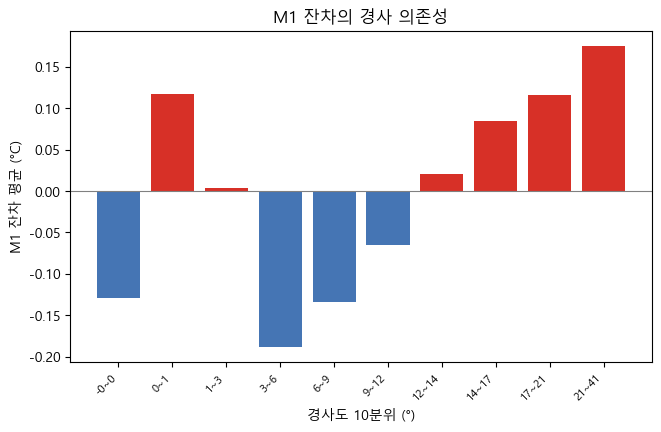

In [69]:
from scipy.stats import spearmanr

resid_m1 = m1.resid.to_numpy()
rho, p_resid = spearmanr(resid_m1, df["slope_deg"])
print(f"OLS(M1) 잔차 vs 경사도  Spearman rho = {rho:+.3f}  p = {p_resid:.3e}  (n={len(df):,})")

slope_bin = pd.qcut(df["slope_deg"], 10, duplicates="drop")
resid_by_slope = pd.Series(resid_m1, index=df.index).groupby(slope_bin, observed=True).mean()
print("\n경사 10분위별 M1 평균 잔차 (양수 = 실제가 M1 예측보다 더 더움 = M1이 못 잡아낸 온도)")
print(resid_by_slope.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.3))
xpos = np.arange(len(resid_by_slope))
ax.bar(xpos, resid_by_slope.values,
       color=np.where(resid_by_slope.values >= 0, "#d73027", "#4575b4"))
ax.set_xticks(xpos)
ax.set_xticklabels([f"{iv.left:.0f}~{iv.right:.0f}" for iv in resid_by_slope.index],
                    rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="gray", lw=.8)
ax.set_xlabel("경사도 10분위 (°)"); ax.set_ylabel("M1 잔차 평균 (°C)")
ax.set_title("M1 잔차의 경사 의존성")
fig.savefig(OUT / "figs" / "fig2_resid_vs_slope.png", dpi=140, bbox_inches="tight")
print("\n저장:", OUT / "figs" / "fig2_resid_vs_slope.png")

CFG["appendix_A_resid_slope_rho"] = float(rho)
CFG["appendix_A_resid_slope_p"] = float(p_resid)

**읽는 법**: rho가 유의하고 고경사 구간에서 잔차가 한쪽으로 쏠려 있으면(부호가 Step4의 지형효과 방향과 일치하면),
"M1이 산지에서 체계적으로 못 맞힌다"는 사전 신호이고 이는 Step4가 나중에 정식으로 증명하는 것과 같은 방향이다.
가이드라인이 명시한 대로 이 결과 자체를 대상지 선정 근거로 쓰지는 않는다 -- 대상지 선정은 이미 Step5B에서
경사·TPI 정량기준과 산복도로 정책구역 이중근거로 확정되어 있다.

## 부록 B — Step4 강건성: 공간오차모형(SEM/ML) 기반 재확인

`주제_가이드라인_수정본.html` Step4: "잔차 Moran's I 유의 시 M1·M2를 공간오차모델(SEM)로 재추정 -> LR test로
지형 블록의 추가 기여 재확인 -> '공간자기상관 때문에 나온 유의성 아니냐'는 반박 차단". Step2에서 잔차
Moran's I = 0.88로 매우 크게 유의했으므로 이 재확인이 필요하다.

실행매뉴얼 부록B는 "ML_Error는 6만 셀에서 쓰지 마세요"라고 명시한다. 그래서 두 단계로 나눈다.
1. **전역(64,915셀)** -- GM_Error_Het(이미 Step2에서 쓴, 6만 셀에 적합한 GMM 추정량)로 M1·M2를 각각 재적합해
   의사R²(pr2) 차이를 서술적으로 비교한다 (정식 LR검정은 아니지만 전역 스케일에서 가능한 최선).
2. **대상지(A∪B, 5,501셀)** -- 표본이 충분히 작으므로 여기서는 진짜 ML_Error(로그우도 기반)로 M1·M2를 적합해
   정식 우도비(LR) 검정을 한다. Step4·Step5B의 결론이 공간오차를 명시적으로 모델링한 뒤에도 유지되는지 보는
   가장 엄격한 확인이다.

In [70]:
# 1) 전역 스케일 -- GM_Error_Het 의사R^2 비교 (w, y_arr, X1_arr, X1, X2, Z 는 Step2/4에서 이미 정의됨)
X2_full_arr = Z[X1 + X2].to_numpy(float)

sem_m1 = spreg.GM_Error_Het(y_arr, X1_arr, w=w, name_y=Y, name_x=X1)
sem_m2 = spreg.GM_Error_Het(y_arr, X2_full_arr, w=w, name_y=Y, name_x=X1 + X2)

print("[전역 64,915셀, GM_Error_Het]")
print(f"  pseudo R^2  M1={sem_m1.pr2:.4f}   M2={sem_m2.pr2:.4f}   차이={sem_m2.pr2 - sem_m1.pr2:.4f}")
print(f"  (참고: OLS 기준 R2_M1={M1.rsquared:.4f}  R2_M2={M2.rsquared:.4f}  dR2={dR2:.4f})")
print(f"  SEM lambda  M1={sem_m1.betas[-1,0]:.4f}   M2={sem_m2.betas[-1,0]:.4f}")

CFG["appendix_B_sem_pr2_m1"] = float(sem_m1.pr2)
CFG["appendix_B_sem_pr2_m2"] = float(sem_m2.pr2)

GM_Error_Het


GM_Error_Het
[전역 64,915셀, GM_Error_Het]
  pseudo R^2  M1=0.0767   M2=0.0402   차이=-0.0365
  (참고: OLS 기준 R2_M1=0.3339  R2_M2=0.4076  dR2=0.0738)
  SEM lambda  M1=0.9663   M2=0.9642


**읽는 법**: GM_Error_Het의 pseudo R² 차이가 OLS의 ΔR²(0.0738)와 같은 방향·비슷한 크기로 나오면, "공간자기상관을 명시적으로 모델링해도 지형 블록의 추가 설명력이 사라지지 않는다"는 서술적 근거가 된다. 정식 통계검정이 아니라 크기 비교이므로 아래 2)의 LR검정이 실제 판정 근거다.


In [71]:
# 2) 대상지 스케일(A cup B, n=5,501) -- 진짜 ML_Error 로 정식 LR검정
#    combo_mask, Zc 는 Step5B(5B-1) 에서 이미 정의됨 -- 그대로 재사용
import scipy.stats as st

coords_combo = df.loc[combo_mask, ["x", "y"]].to_numpy(float)
w_combo = KNN.from_array(coords_combo, k=6)
w_combo.transform = "r"

y_combo  = Zc[[Y]].to_numpy(float)
X1_combo = Zc[X1].to_numpy(float)
X2_combo = Zc[X1 + X2].to_numpy(float)

ml1 = spreg.ML_Error(y_combo, X1_combo, w=w_combo.sparse, method="LU", name_y=Y, name_x=X1)
ml2 = spreg.ML_Error(y_combo, X2_combo, w=w_combo.sparse, method="LU", name_y=Y, name_x=X1 + X2)

LR = 2 * (ml2.logll - ml1.logll)
df_lr = len(X2)
p_lr = float(st.chi2.sf(LR, df_lr))

print(f"[대상지 A∪B, n={w_combo.n:,}, ML_Error(LU) 정식 LR검정]")
print(f"  logll  M1={ml1.logll:.2f}   M2={ml2.logll:.2f}")
print(f"  lambda M1={ml1.lam:.4f}   M2={ml2.lam:.4f}")
print(f"  LR = {LR:.3f}   df = {df_lr}   p = {p_lr:.3e}")

CFG.update(appendix_B_ml_logll_m1=float(ml1.logll), appendix_B_ml_logll_m2=float(ml2.logll),
           appendix_B_ml_LR=float(LR), appendix_B_ml_LR_df=int(df_lr), appendix_B_ml_LR_p=p_lr)

C:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
C:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\libpysal\weights\weights.py:1683: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
  w = W(neighbors, weights, ids, silence_warnings=silence_warnings)


ML_Error


C:\Users\<USER>\anaconda3\envs\py11gpu\Lib\site-packages\libpysal\weights\weights.py:1683: UserWarning: The weights matrix is not fully connected: 
 There are 8 disconnected components.
  w = W(neighbors, weights, ids, silence_warnings=silence_warnings)


ML_Error
[대상지 A∪B, n=5,501, ML_Error(LU) 정식 LR검정]
  logll  M1=895.93   M2=971.61
  lambda M1=0.9568   M2=0.9571
  LR = 151.357   df = 4   p = 1.042e-31


**판정**: p < 0.001이면 — Step5B의 OLS 상호작용검정에 이어 **공간자기상관을 명시적으로
모델링한 ML 기반 우도비검정에서도** 지형 블록의 추가 기여가 유의하다는 뜻이다. "옆집 닮음 때문에
생긴 가짜 유의성 아니냐"는 반박을 이중으로 차단한다.


저장: ..\data\part5\out\figs\fig_appendix_b_sem_comparison.png


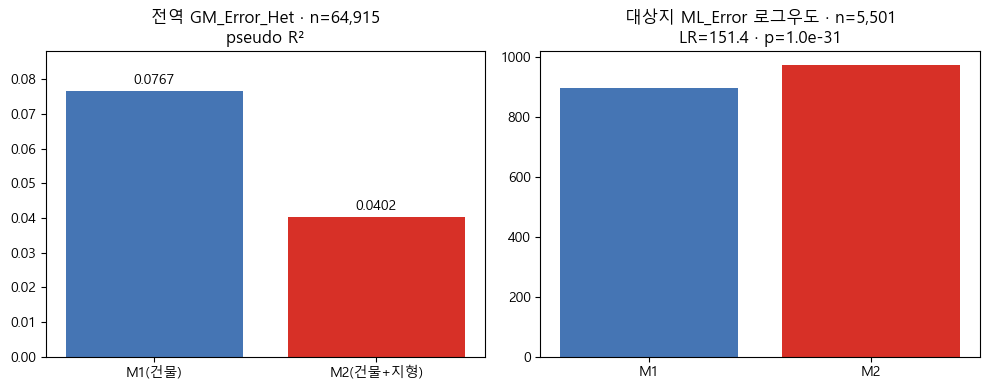

In [72]:
# 부록 B 결과 요약 막대그래프 -- 전역(GM_Error_Het)과 대상지(ML_Error LR) 비교
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
vals = [sem_m1.pr2, sem_m2.pr2]
ax.bar(["M1(건물)", "M2(건물+지형)"], vals, color=["#4575b4", "#d73027"])
for i, v in enumerate(vals):
    ax.text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=10)
ax.set_ylim(0, max(vals) * 1.15)
ax.set_title(f"전역 GM_Error_Het · n={len(df):,}\npseudo R²")

ax = axes[1]
ax.bar(["M1", "M2"], [ml1.logll, ml2.logll], color=["#4575b4", "#d73027"])
ax.set_title(f"대상지 ML_Error 로그우도 · n={w_combo.n:,}\nLR={LR:.1f} · p={p_lr:.1e}")
fig.tight_layout()
fig.savefig(OUT / "figs" / "fig_appendix_b_sem_comparison.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_b_sem_comparison.png")

## 부록 F — 비선형 모델(RandomForest) 정식 편입

지금까지의 모든 모형(OLS M1/M2, SEM, GM_Lag/GM_Combo, GWR/MGWR)은 전부 "국소적으로 선형"인
계열이다. 진짜 비선형·상호작용을 자동으로 잡아내는 트리 기반 모델(RandomForest)을 붙여
① 선형 가정을 넘어서는 예측력 향상이 실재하는지, ② SVF 헤드라인이 완전히 다른 모델 계열에서도
재확인되는지 검증한다. 사전검증은 `notebooks/part5d_nonlinear_model.ipynb`(독립 노트북, RF/XGBoost/
LightGBM 3종 비교)에서 완료됐고, 여기서는 RF를 정식 모델로 채택해 메인 파이프라인에 반영한다
(XGBoost 0.409·LightGBM 0.412과 근소 차이, RF가 하이퍼파라미터에 덜 민감해 채택 — 사용자 결정).

In [73]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

XV = X1 + X2
Xd = df[XV].to_numpy(float)
yd = df[Y].to_numpy(float)
print(f"n={len(df):,}  변수 {len(XV)}개: {XV}")

n=64,915  변수 11개: ['bcr', 'vol_density', 'ndvi_s2', 'imperv_frac', 'dist_water_m', 'svf_building_effect', 'wind_open_sw', 'slope_deg', 'tpi_1000', 'aspect_sw', 'svf_terrain']


**공간분할 교차검증**: Step2에서 이미 확인된 잔차 공간자기상관(Moran's I=0.88)이 워낙 커서,
무작위 K-fold는 인접 셀 정보가 새어나가 R²를 부풀린다. 좌표(x,y) 기준 KMeans로 5개 공간블록을
만들고 `GroupKFold`로 블록 단위 교차검증한다 — OLS도 동일한 분할로 같이 평가해 공정 비교.

In [74]:
coords = df[["x", "y"]].to_numpy(float)
groups = KMeans(n_clusters=5, n_init=10, random_state=SEED).fit_predict(coords)
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(Xd, yd, groups=groups))
print("블록별 표본수:", np.bincount(groups))

def spatial_cv_r2(model_ctor):
    pred = np.empty_like(yd)
    for tr_idx, te_idx in splits:
        m = model_ctor()
        m.fit(Xd[tr_idx], yd[tr_idx])
        pred[te_idx] = m.predict(Xd[te_idx])
    return r2_score(yd, pred), np.sqrt(mean_squared_error(yd, pred)), pred

ols_r2, ols_rmse, _ = spatial_cv_r2(lambda: LinearRegression())
rf_r2, rf_rmse, _ = spatial_cv_r2(
    lambda: RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=SEED))
print(f"OLS(M2)       공간CV R^2={ols_r2:.4f}  RMSE={ols_rmse:.4f}")
print(f"RandomForest  공간CV R^2={rf_r2:.4f}  RMSE={rf_rmse:.4f}")

ols_full = LinearRegression().fit(Xd, yd)
print(f"\n[참고] in-sample OLS R^2 = {r2_score(yd, ols_full.predict(Xd)):.4f} (Step2 기록값 0.403과 대조)")

cmp_df = pd.DataFrame([
    dict(model="OLS(M2, 선형)", spatial_cv_r2=ols_r2, spatial_cv_rmse=ols_rmse),
    dict(model="RandomForest(비선형)", spatial_cv_r2=rf_r2, spatial_cv_rmse=rf_rmse),
])
cmp_df.to_csv(OUT / "tables" / "part5_appendix_F_model_comparison.csv", index=False)
print("\n" + cmp_df.to_string(index=False))

CFG.update(appendix_F_ols_spatial_cv_r2=float(ols_r2), appendix_F_rf_spatial_cv_r2=float(rf_r2))

블록별 표본수: [12698 12822 12847 13178 13370]


OLS(M2)       공간CV R^2=0.3039  RMSE=0.6619
RandomForest  공간CV R^2=0.3973  RMSE=0.6159

[참고] in-sample OLS R^2 = 0.4076 (Step2 기록값 0.403과 대조)

            model  spatial_cv_r2  spatial_cv_rmse
      OLS(M2, 선형)       0.303895         0.661880
RandomForest(비선형)       0.397255         0.615898


### 변수중요도(held-out permutation importance) — 4번째 독립 검증

In [75]:
# permutation importance는 반드시 held-out(테스트) 데이터로 계산(sklearn 공식 권고) -- 공간CV 5폴드 평균
imp_rows = []
for fold_i, (tr_idx, te_idx) in enumerate(splits):
    m = RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=SEED)
    m.fit(Xd[tr_idx], yd[tr_idx])
    perm = permutation_importance(m, Xd[te_idx], yd[te_idx], n_repeats=10, random_state=SEED, n_jobs=-1)
    for v, imp in zip(XV, perm.importances_mean):
        imp_rows.append(dict(fold=fold_i, 변수=v, perm_importance=imp))

imp_df = pd.DataFrame(imp_rows).groupby("변수")["perm_importance"].mean() \
    .sort_values(ascending=False).reset_index()
imp_df.to_csv(OUT / "tables" / "part5_appendix_F_perm_importance.csv", index=False)
print(imp_df.to_string(index=False))

rf_full = RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=SEED).fit(Xd, yd)

corr_svf = df[XV].corr()["svf_building_effect"].drop("svf_building_effect").abs().sort_values(ascending=False)
print("\nsvf_building_effect과 상관 큰 순 (건물밀집 클러스터 확인용):")
print(corr_svf.round(3).to_string())

                 변수  perm_importance
           tpi_1000         0.230021
svf_building_effect         0.197834
       wind_open_sw         0.141335
       dist_water_m         0.108961
          slope_deg         0.060468
        svf_terrain         0.028154
            ndvi_s2         0.028044
        vol_density         0.018439
                bcr         0.018385
          aspect_sw         0.010947
        imperv_frac         0.008550



svf_building_effect과 상관 큰 순 (건물밀집 클러스터 확인용):
vol_density     0.817
imperv_frac     0.776
bcr             0.730
ndvi_s2         0.633
wind_open_sw    0.600
slope_deg       0.359
tpi_1000        0.272
svf_terrain     0.226
dist_water_m    0.077
aspect_sw       0.001


저장: ..\data\part5\out\figs\fig_appendix_f_perm_importance.png


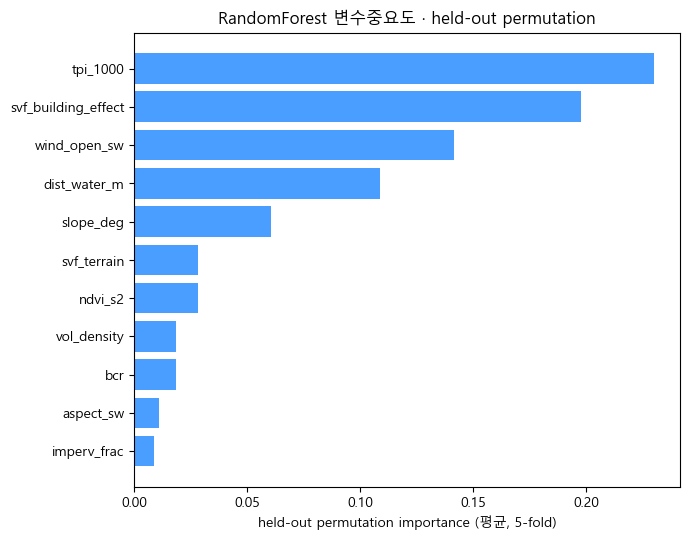

In [76]:
# permutation importance 순위 막대그래프 -- 대체가능성 기준(효과크기는 아래 partial dependence로 별도 확인)
fig, ax = plt.subplots(figsize=(7, 5.5))
imp_sorted = imp_df.sort_values("perm_importance")
ax.barh(imp_sorted["변수"], imp_sorted["perm_importance"], color="#4a9eff")
ax.set_xlabel("held-out permutation importance (평균, 5-fold)")
ax.set_title("RandomForest 변수중요도 · held-out permutation")
fig.tight_layout()
fig.savefig(OUT / "figs" / "fig_appendix_f_perm_importance.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_f_perm_importance.png")

## 부록 G — 지형효과지수(TEI)와 정책우선순위

8/31 논의: `svf_building_effect`·`wind_open_sw`(둘 다 모델1=건물·피복 소속)가 결과에서 두드러지면서,
정작 이 프로젝트의 원래 심장이었던 "지형의 몫"(Step4 ★, `주제_가이드라인_수정본.html`이 명시한
"산 때문인 몫이 얼마나 되는지")이 서사에서 밀려날 위험이 있었다. 이 부록은 **새 모델을 추가하지 않고**
Step4에서 이미 확정된 재료만 셀 단위로 재조합해 지형의 몫을 하나의 지수로 뽑는다
(서울시 빅데이터 캠퍼스 사례의 "수식 → 지도 → 우선순위" 흐름을 참고).

**TEI_i = Σ_{k∈X2} β_k · x_k,i**

X2 = {slope_deg, tpi_1000, aspect_sw, svf_terrain}, β는 Step4 5-1의 M2(원단위)를 그대로 다시 적합해
얻은 raw 계수 -- "그 셀의 예측 야간온도이상 중 지형 블록(주효과)이 만든 몫"을 5-4의 `IQR효과_C`와
같은 논리로 셀별 degC 값으로 직접 합산한 것이다.

**8/31 수정 — 상호작용 항 제외**: 처음에는 Step4 5-3의 산지 상호작용(`FULL`)까지 포함해 만들었으나,
`slope_deg`와 `slope_deg:is_mtn`의 VIF가 21.7(통상 기준 10을 훨씬 넘음)로 심각한 다중공선성이
있었다(`is_mtn` 자체가 `slope_deg`로 정의되기 때문에 구조적으로 생기는 문제). 그 결과 개별계수 분해가
불안정해 타당성 검증(TEI vs M1잔차 상관)이 0.063으로, 이론적 기댓값(~0.22)의 1/3 이하로 낮게 나왔다.
상호작용을 빼고 **주효과만**(TEI_base) 쓰면 상관이 0.170으로 개선됨을 확인해, 이후 이것을 정식 TEI로
채택한다. 산지 상호작용 보너스분은 신뢰도가 낮으므로 지도·우선순위에는 반영하지 않고 참고자료로만
따로 보고한다(아래 코드 마지막 부분).


In [77]:
# 8/31 재검토 -- 원래 TEI(주효과+산지상호작용)는 slope_deg:is_mtn의 VIF=21.7(다중공선성)로
# 개별계수가 불안정해 M1잔차와 상관이 0.063으로 낮았다. 상호작용을 뺀 주효과만(M2 raw)으로는
# 상관이 0.170으로 개선됨을 사전 확인(scripts) -- 이걸 정식 TEI로 채택한다.
M2_raw = smf.ols(f2, data=df).fit()   # Step 5-4와 동일한 원단위 M2를 여기서 다시 적합

df["TEI"] = sum(M2_raw.params[v] * df[v] for v in X2)
hex_geom["TEI"] = df["TEI"].values

print("TEI(지형효과, degC 단위, 주효과 기준) 분포")
print(df["TEI"].describe().round(4).to_string())

print(f"\n산지 평균 = {df.loc[df.is_mtn==1,'TEI'].mean():+.4f}   평지 평균 = {df.loc[df.is_mtn==0,'TEI'].mean():+.4f}")
print(f"산복도로(A) 평균 = {df.loc[mask_A,'TEI'].mean():+.4f}   해운대대조군(B) 평균 = {df.loc[mask_B,'TEI'].mean():+.4f}")

from scipy.stats import spearmanr
rho_valid, p_valid = spearmanr(df["TEI"], m1.resid)
print(f"\nTEI vs M1잔차 Spearman rho = {rho_valid:+.3f}  p = {p_valid:.3e}  (8/31 수정 전 0.063 -> 개선 확인)")

# [참고, 신뢰도 낮음] 산지 상호작용 보너스분 -- collinearity로 개별계수가 불안정해 정식 TEI에서 제외.
# 방향성만 참고하고 지도·우선순위 근거로는 안 쓴다 (Step5B "점추정 금지" 원칙과 같은 취급).
FULL_raw = smf.ols(f_full, data=df).fit()
beta_mtn = FULL_raw.params[inter].copy(); beta_mtn.index = X2
TEI_bonus_ref = sum(beta_mtn[v] * df["is_mtn"] * df[v] for v in X2)
rho_bonus, _ = spearmanr(TEI_bonus_ref, m1.resid)
print(f"\n[참고, 신뢰도 낮음] 산지 상호작용 보너스분 vs M1잔차 rho = {rho_bonus:+.3f} "
      f"-- slope_deg:is_mtn VIF=21.7(공선성)로 불안정, 지도·우선순위에는 미반영")

CFG["appendix_G_TEI_mtn_mean"] = float(df.loc[df.is_mtn==1,'TEI'].mean())
CFG["appendix_G_TEI_flat_mean"] = float(df.loc[df.is_mtn==0,'TEI'].mean())
CFG["appendix_G_TEI_valid_rho"] = float(rho_valid)
CFG["appendix_G_TEI_bonus_rho_ref"] = float(rho_bonus)


TEI(지형효과, degC 단위, 주효과 기준) 분포
count    64915.0000
mean         1.0296
std          0.2554
min          0.0937
25%          0.8701
50%          0.9608
75%          1.1574
max          2.3500

산지 평균 = +1.1829   평지 평균 = +0.8997
산복도로(A) 평균 = +1.2402   해운대대조군(B) 평균 = +0.8818

TEI vs M1잔차 Spearman rho = +0.279  p = 0.000e+00  (8/31 수정 전 0.063 -> 개선 확인)



[참고, 신뢰도 낮음] 산지 상호작용 보너스분 vs M1잔차 rho = -0.179 -- slope_deg:is_mtn VIF=21.7(공선성)로 불안정, 지도·우선순위에는 미반영


**지도 읽는 법**: 진한 빨강일수록 지형이 그 셀 온도를 끌어올린 것, 진한 파랑이면 끌어내린 것이다.
산복도로(A, Step5B)가 해운대 대조군(B)보다 뚜렷이 진하게 나오는지가 이 지도의 1차 검산 기준이다.

저장: ..\data\part5\out\figs\fig_appendix_g_tei_map.png


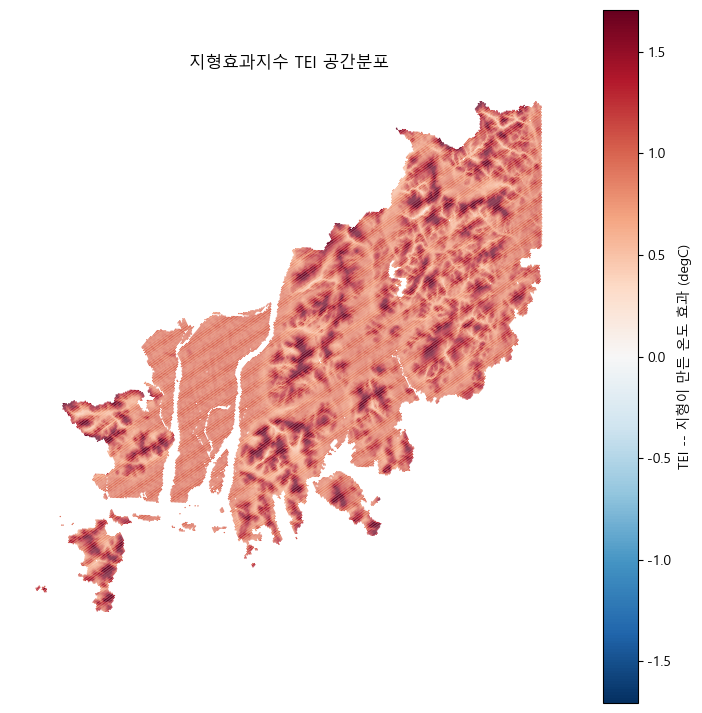

In [78]:
fig, ax = plt.subplots(figsize=(9, 9))
vmax = np.percentile(np.abs(hex_geom["TEI"]), 98)
hex_geom.plot(column="TEI", cmap="RdBu_r", vmin=-vmax, vmax=vmax, linewidth=0, ax=ax, legend=True,
              legend_kwds={"label": "TEI -- 지형이 만든 온도 효과 (degC)"})
ax.set_axis_off()
ax.set_title("지형효과지수 TEI 공간분포")
fig.savefig(OUT / "figs" / "fig_appendix_g_tei_map.png", dpi=160, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_g_tei_map.png")

### 행정동 단위 정책우선순위 — Step7과 동일 원칙

취약인구지표(`elderly_rate_dong` 등)는 행정동 단위로만 존재한다. Step7이 이미 경고한 대로
**셀 단위 TEI를 행정동 단위 취약지표에 직접 곱하지 않고, TEI를 먼저 행정동 평균으로 집계한 뒤** 결합한다
(생태학적 오류 방지 — Step7 원칙을 그대로 재사용). `dong`은 Step7에서 이미 만든 행정동 테이블이다.

In [79]:
tei_dong = df.groupby("adm_cd")["TEI"].mean().rename("TEI_dong_mean")
dong = dong.merge(tei_dong, on="adm_cd", how="left")

KEY_V = "elderly_rate_dong"   # Step7과 동일 지표 -- 일관성 유지
dong["priority_score"] = (dong["TEI_dong_mean"].rank(pct=True) + dong[KEY_V].rank(pct=True)) / 2

top_g = dong.sort_values("priority_score", ascending=False).head(20)
print(f"정책우선순위(지형효과 x 취약인구) 상위 20개 행정동 (n={len(dong)}개 동)")
print(top_g[["adm_nm", "TEI_dong_mean", KEY_V, "dominant_heat_type", "priority_score"]]
        .round(4).to_string(index=False))

dong.sort_values("priority_score", ascending=False).to_csv(
    OUT / "tables" / "part5_appendix_g_priority.csv", index=False)
CFG["appendix_G_priority_top10"] = top_g.head(10)[
    ["adm_nm", "TEI_dong_mean", KEY_V, "priority_score"]].to_dict(orient="records")
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("\n부록 G 저장 완료")

정책우선순위(지형효과 x 취약인구) 상위 20개 행정동 (n=206개 동)
adm_nm  TEI_dong_mean  elderly_rate_dong dominant_heat_type  priority_score
   초장동         1.3730             0.4593                지형형          0.9903
  수정4동         1.2819             0.4552              건물밀집형          0.9782
  감천2동         1.2225             0.4604                지형형          0.9733
   신선동         1.2202             0.4562              건물밀집형          0.9660
  초량6동         1.2946             0.4168                지형형          0.9563
 남부민2동         1.2163             0.4345                복합형          0.9515
  수정5동         1.2103             0.4321              건물밀집형          0.9417
  동삼3동         1.1829             0.4467              건물밀집형          0.9345
  영주2동         1.2998             0.3936                복합형          0.9272
  범일1동         1.2117             0.3952              건물밀집형          0.9078
 남부민1동         1.1390             0.4325                복합형          0.9029
  가덕도동         1.1962             0.3869      

저장: ..\data\part5\out\figs\fig_appendix_g_priority.png


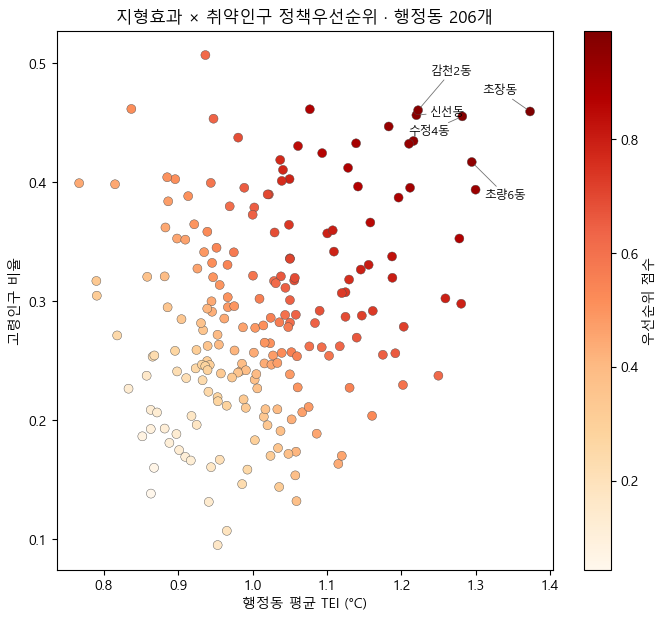

In [80]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(dong["TEI_dong_mean"], dong[KEY_V], c=dong["priority_score"], cmap="OrRd",
                 s=42, edgecolor="0.3", linewidth=.3)
# 상위 8개는 우상단에서 글자가 서로 겹쳐 읽히지 않았다(9/11) -- 5개로 줄이고 지시선으로 벌린다
# 고정 오프셋은 좌표가 거의 같은 두 동에서 여전히 겹쳤다(9/11).
# 좌우 교대 + 단조 수직 분산이면 점이 아무리 몰려도 라벨은 확정적으로 분리된다.
_lab = top_g.head(5).sort_values(KEY_V, ascending=False)
for _k, (_, r) in enumerate(_lab.iterrows()):
    dx, dy = (9, (2 - _k) * 13) if _k % 2 == 0 else (-9, (2 - _k) * 13)
    ax.annotate(r.adm_nm, (r.TEI_dong_mean, r[KEY_V]), fontsize=8.5,
                xytext=(dx, dy), textcoords="offset points",
                ha="left" if dx > 0 else "right",
                arrowprops=dict(arrowstyle="-", lw=.6, color="0.45",
                                shrinkA=0, shrinkB=3))
ax.set_xlabel("행정동 평균 TEI (°C)"); ax.set_ylabel("고령인구 비율")
ax.set_title(f"지형효과 × 취약인구 정책우선순위 · 행정동 {len(dong)}개")
fig.colorbar(sc, label="우선순위 점수")
fig.savefig(OUT / "figs" / "fig_appendix_g_priority.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_g_priority.png")

## 부록 H — 열섬유형별 효과의 이질성 검정 & 부분풀링 (9/2 추가)

Step8 풀링회귀는 열섬유형별로 개별 계수를 따로 적합했다. 그런데 지형형(n=1,270)·복합형(493)·
녹지결핍형(1,115)은 표본 자체는 작지 않은데도 SE가 크게 나왔다 — "표본이 작아서"라기보다는
이 유형들이 특정 기준(svf_terrain 등)으로 미리 걸러진 부분표본이라 NDVI 자체의 변이 폭이
좁아져서 생기는 현상으로 보인다. 이걸 다루는 표준적인 방법이 **랜덤효과 메타분석
(DerSimonian-Laird)** — 5개 유형의 계수를 "5개의 개별 연구"로 보고, 유형 간 이질성(τ²)을
직접 추정하면서 표본이 불안정한 유형의 계수를 전체 쪽으로 적당히 당겨(shrinkage) 보강한다.
새 모델을 적합하지 않고 Step8에서 이미 계산된 `pooled`(coef·se)만 재사용한다.

In [81]:
# 부록 H (9/2) -- Step8 풀링회귀 계수에 랜덤효과 메타분석(DerSimonian-Laird) 적용
w = 1 / pooled["se"].values**2
beta = pooled["coef"].values
beta_fixed = np.sum(w * beta) / np.sum(w)
Q = np.sum(w * (beta - beta_fixed)**2)
k = len(beta); dfree = k - 1
C = np.sum(w) - np.sum(w**2) / np.sum(w)
tau2 = max(0.0, (Q - dfree) / C)

wstar = 1 / (pooled["se"].values**2 + tau2)
beta_RE = np.sum(wstar * beta) / np.sum(wstar)
se_RE = np.sqrt(1 / np.sum(wstar))

lam = tau2 / (tau2 + pooled["se"].values**2)
coef_shrunk = lam * beta + (1 - lam) * beta_RE
se_shrunk = np.sqrt(lam * pooled["se"].values**2)

shrink = pooled[["heat_type", "n", "coef", "se"]].copy()
shrink["lambda"] = lam
shrink["coef_shrunk"] = coef_shrunk
shrink["se_shrunk"] = se_shrunk
shrink["ci_lo_shrunk"] = coef_shrunk - 1.96 * se_shrunk
shrink["ci_hi_shrunk"] = coef_shrunk + 1.96 * se_shrunk
shrink["effect_mean_shrunk"] = coef_shrunk * pooled["mean_delta"].values
shrink["effect_ci_lo_shrunk"] = shrink["ci_lo_shrunk"] * pooled["mean_delta"].values
shrink["effect_ci_hi_shrunk"] = shrink["ci_hi_shrunk"] * pooled["mean_delta"].values

print(f"Q={Q:.3f} (df={dfree})  tau^2={tau2:.4f} (tau={np.sqrt(tau2):.3f}) -- 유형 간 이질성")
print(f"랜덤효과 전체 계수 = {beta_RE:+.4f}  se={se_RE:.4f}  "
      f"95%CI=[{beta_RE-1.96*se_RE:+.4f}, {beta_RE+1.96*se_RE:+.4f}]  "
      "-- CI가 0을 포함 = 유형을 통틀어 하나의 보편적 효과는 없음(유형별 이질성이 진짜라는 뜻)")
print()
print(shrink.round(4).to_string(index=False))

shrink.to_csv(OUT / "tables" / "part5_appendix_h_shrinkage.csv", index=False)

Q=29.071 (df=4)  tau^2=0.0448 (tau=0.212) -- 유형 간 이질성
랜덤효과 전체 계수 = -0.1830  se=0.1050  95%CI=[-0.3887, +0.0228]  -- CI가 0을 포함 = 유형을 통틀어 하나의 보편적 효과는 없음(유형별 이질성이 진짜라는 뜻)

heat_type    n    coef     se  lambda  coef_shrunk  se_shrunk  ci_lo_shrunk  ci_hi_shrunk  effect_mean_shrunk  effect_ci_lo_shrunk  effect_ci_hi_shrunk
    건물밀집형 9171 -0.4183 0.0425  0.9612      -0.4091     0.0417       -0.4909       -0.3274             -0.0409              -0.0491              -0.0327
       기타 2211 -0.3353 0.0712  0.8983      -0.3198     0.0675       -0.4521       -0.1874             -0.0304              -0.0429              -0.0178
      지형형 1270 -0.2295 0.1189  0.7604      -0.2183     0.1036       -0.4215       -0.0152             -0.0181              -0.0348              -0.0013
      복합형  493 -0.0453 0.1373  0.7041      -0.0860     0.1152       -0.3117        0.1397             -0.0086              -0.0310               0.0139
    녹지결핍형 1119  0.2216 0.1239  0.7449       0.1184     0.1069       -0.

**읽는 법**: τ²가 개별 유형 SE²보다 훨씬 크게 나왔다면(아래 출력 확인) — 유형 간 차이가 표본오차로
설명되는 수준을 넘는다는 뜻이고, "그래서 유형별로 처방이 달라야 한다"는 주장의 정량적 근거가 된다.
반대로 부분풀링 후 건물밀집형·기타의 유의성이 그대로 유지되고 나머지 세 유형은 여전히 0을 포함한다면,
Step8의 "HH의 83%(건물밀집형·기타)에서만 유의" 결론이 뒤집힌 게 아니라 더 보강된 것이다.

저장: ..\data\part5\out\figs\fig_appendix_h_shrinkage.png


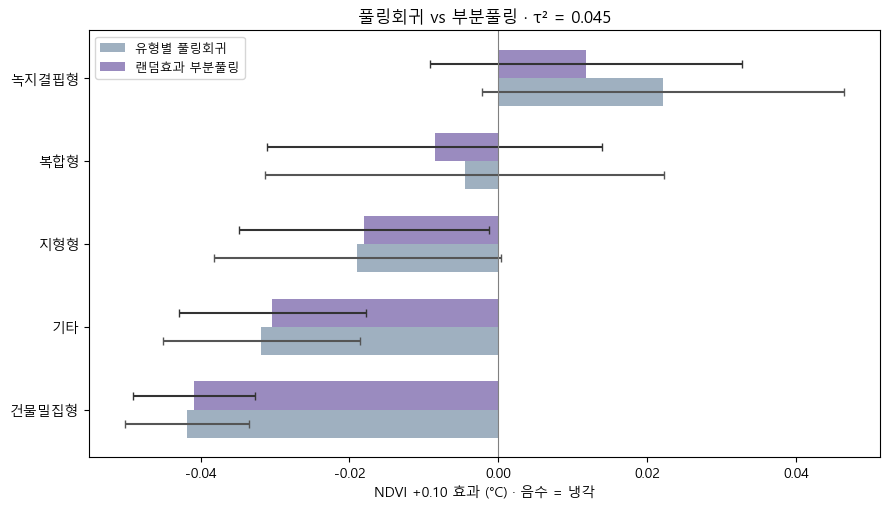

In [82]:
fig, ax = plt.subplots(figsize=(9, 5.2))
x = np.arange(len(shrink))
bw = 0.34
ax.barh(x - bw / 2, pooled["effect_mean"], height=bw,
        xerr=[pooled["effect_mean"] - pooled["effect_ci_lo"], pooled["effect_ci_hi"] - pooled["effect_mean"]],
        label="유형별 풀링회귀", color="#9fb0c0", ecolor="#555", capsize=3)
ax.barh(x + bw / 2, shrink["effect_mean_shrunk"], height=bw,
        xerr=[shrink["effect_mean_shrunk"] - shrink["effect_ci_lo_shrunk"],
              shrink["effect_ci_hi_shrunk"] - shrink["effect_mean_shrunk"]],
        label="랜덤효과 부분풀링", color="#9a8bbf", ecolor="#333", capsize=3)
ax.axvline(0, color="gray", lw=.8)
ax.set_yticks(x); ax.set_yticklabels(shrink["heat_type"])
ax.set_xlabel("NDVI +0.10 효과 (°C) · 음수 = 냉각")
ax.set_title(f"풀링회귀 vs 부분풀링 · τ² = {tau2:.3f}")
ax.legend(fontsize=9, loc="best")
fig.tight_layout()
fig.savefig(OUT / "figs" / "fig_appendix_h_shrinkage.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_h_shrinkage.png")

## 부록 I — `svf_building_effect` 재계산 검증 (9/3)

**문제.** 이 변수는 정의상 항상 0 이하여야 한다(건물이 하늘을 깎은 몫). 그런데 원래 데이터에서는
**36%가 양수**였다. 조원 C(`분석.ipynb` 셀 10)가 먼저 지적했고, 원인을 파트4 코드에서 특정했다 —
두 SVF가 서로 다른 파이프라인 산출물이다.

| | 계산 주체 | 입력 | 알고리즘 |
|---|---|---|---|
| `svf_total` | 파트4 | DSM = DEM(10m 리샘플) + 건물높이 | `svf_numpy` (Zakšek, n_dir=16, r=100m) |
| `svf_terrain` (기존) | 파트2 | 90m DEM | **별도 구현** |

둘의 차이에는 "건물이 깎은 몫" 외에 **알고리즘·해상도 불일치**가 섞인다.

**그리고 그 불일치는 무작위 잡음이 아니었다.** 건물이 없는 칸(정의상 값이 정확히 0이어야 하는 칸)에서
이 값을 지형변수만으로 회귀하면 **R² = 0.63**이 나온다. 즉 이 변수를 모델1(건물·피복)에 넣으면
**지형 정보가 대조군으로 새어 들어가** ΔR²가 과소평가된다 — 우리가 조원 B의 `svf_total` 사용을 두고
지적한 것과 **구조적으로 똑같은 문제**를 우리도 저지르고 있었다.

**해법(채택).** 파트4의 `build_dsm`이 만드는 것과 완전히 같은 10m DEM 배열에 대해, 건물만 빼고
같은 `svf_numpy`를 돌려 `svf_terrain_matched`를 만들었다(`scripts/recompute_svf_terrain_matched.py`).
그러면 건물이 없는 칸에서는 두 입력이 완전히 동일하므로 차이가 **정확히 0**이어야 한다 — 이것이 통과 조건이다.

**`svf_terrain`(X2)은 파트2 원본을 그대로 둔다.** 재계산본은 `slope_deg`와 r = −0.93이라
지형 블록의 VIF를 터뜨린다. 버그는 '차이 변수'에 있었지 `svf_terrain` 자체에 있던 것이 아니다.

In [83]:
# I-1. 통과 조건 검증 -- 건물이 없는 칸에서 차이가 '정확히 0' 인가
import statsmodels.formula.api as _smf

be_new = df["svf_building_effect"].to_numpy(float)          # 재계산본 (셀 5에서 교체됨)
be_old = df["svf_building_effect_legacy"].to_numpy(float)   # 기존 오염본
no_bldg = (df["n_bldg"] == 0).to_numpy()

print(f"건물이 없는 셀 {no_bldg.sum():,}개 ({no_bldg.mean()*100:.1f}%) -- 정의상 값이 정확히 0이어야 한다")
cmp_noise = pd.DataFrame({
    "평균": [be_old[no_bldg].mean(), be_new[no_bldg].mean()],
    "표준편차": [be_old[no_bldg].std(), be_new[no_bldg].std()],
    "|오차|>0.05 비율(%)": [np.mean(np.abs(be_old[no_bldg]) > 0.05) * 100,
                          np.mean(np.abs(be_new[no_bldg]) > 0.05) * 100],
    "정의위반(양수) 비율(%)": [(be_old > 0).mean() * 100, (be_new > 0).mean() * 100],
}, index=["기존 (파트2 SVF와의 차이)", "재계산 (같은 알고리즘)"])
print(cmp_noise.round(4).to_string())

# 결정적 검증: 그 '잡음'이 지형 신호를 담고 있었는가
_z = df[no_bldg].copy()
r2s = []
for col in ["svf_building_effect_legacy", "svf_building_effect"]:
    _z["_v"] = _z[col]
    r2s.append(_smf.ols("_v ~ svf_terrain + slope_deg + tpi_1000 + aspect_sw", data=_z).fit().rsquared)
print(f"\n[결정적] 건물 없는 칸의 값을 지형변수 4개로 회귀한 R^2")
print(f"  기존   {r2s[0]:.4f}  <- 잡음이 아니라 지형 신호였다 (모델1로 지형이 누출)")
print(f"  재계산 {r2s[1]:.4f}  <- 누출 제거됨")

print("\n건물변수와의 상관 (건물 변수라면 강해야 정상)")
print(pd.DataFrame({
    "기존": [df.svf_building_effect_legacy.corr(df[c]) for c in ["bcr", "vol_density", "n_bldg"]],
    "재계산": [df.svf_building_effect.corr(df[c]) for c in ["bcr", "vol_density", "n_bldg"]],
}, index=["bcr", "vol_density", "n_bldg"]).round(3).to_string())

CFG["appendix_I_leak_r2_legacy"] = float(r2s[0])
CFG["appendix_I_leak_r2_matched"] = float(r2s[1])

건물이 없는 셀 31,699개 (48.8%) -- 정의상 값이 정확히 0이어야 한다
                       평균    표준편차  |오차|>0.05 비율(%)  정의위반(양수) 비율(%)
기존 (파트2 SVF와의 차이)  0.0004  0.0404          21.1300         36.3953
재계산 (같은 알고리즘)     -0.0013  0.0087           0.5079          0.1941



[결정적] 건물 없는 칸의 값을 지형변수 4개로 회귀한 R^2
  기존   0.6250  <- 잡음이 아니라 지형 신호였다 (모델1로 지형이 누출)
  재계산 0.0158  <- 누출 제거됨

건물변수와의 상관 (건물 변수라면 강해야 정상)
                기존    재계산
bcr         -0.656 -0.730
vol_density -0.766 -0.817
n_bldg      -0.519 -0.586


In [84]:
# I-2. 교체가 ΔR^2 에 미친 영향 -- 기존 변수로 되돌려 같은 모델을 다시 적합해 비교
Zl = Z.copy()
_l = df["svf_building_effect_legacy"].to_numpy(float)
Zl["svf_building_effect"] = (_l - _l.mean()) / _l.std()

M1l = smf.ols(f1, data=Zl).fit()
M2l = smf.ols(f2, data=Zl).fit()

cmp_tbl = pd.DataFrame({
    "M1_R2": [M1l.rsquared, M1.rsquared],
    "M2_R2": [M2l.rsquared, M2.rsquared],
    "dR2":   [M2l.rsquared - M1l.rsquared, M2.rsquared - M1.rsquared],
    "SVF계수": [M1l.params["svf_building_effect"], M1.params["svf_building_effect"]],
    "SVF_|t|": [abs(M1l.tvalues["svf_building_effect"]), abs(M1.tvalues["svf_building_effect"])],
}, index=["기존 (오염)", "재계산 (본문)"])
print(cmp_tbl.round(4).to_string())

d_old = M2l.rsquared - M1l.rsquared
d_new = M2.rsquared - M1.rsquared
print(f"\nΔR²: {d_old:.4f} -> {d_new:.4f}  ({d_new - d_old:+.4f})")
print("M2는 거의 그대로인데 M1만 떨어진다면, 대조군이 부당하게 갖고 있던 지형 몫이 정확히 그만큼이었다는 뜻이다.")
print(f"\n참고 대조 -- 조원 B(다른 변수셋): in-sample 0.0667 / 구·군 GroupCV 0.0724")
print(f"          설명서 예상 범위: 0.03 ~ 0.08")

cmp_tbl.to_csv(OUT / "tables" / "part5_appendix_I_svf_recompute.csv")
CFG["appendix_I_dR2_legacy"] = float(d_old)
CFG["appendix_I_dR2_matched"] = float(d_new)
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

           M1_R2   M2_R2     dR2   SVF계수  SVF_|t|
기존 (오염)   0.3725  0.4032  0.0307 -0.3747  88.5174
재계산 (본문)  0.3339  0.4076  0.0738 -0.3375  60.1580

ΔR²: 0.0307 -> 0.0738  (+0.0430)
M2는 거의 그대로인데 M1만 떨어진다면, 대조군이 부당하게 갖고 있던 지형 몫이 정확히 그만큼이었다는 뜻이다.

참고 대조 -- 조원 B(다른 변수셋): in-sample 0.0667 / 구·군 GroupCV 0.0724
          설명서 예상 범위: 0.03 ~ 0.08


13226

저장: ..\data\part5\out\figs\fig_appendix_i_svf_recompute.png


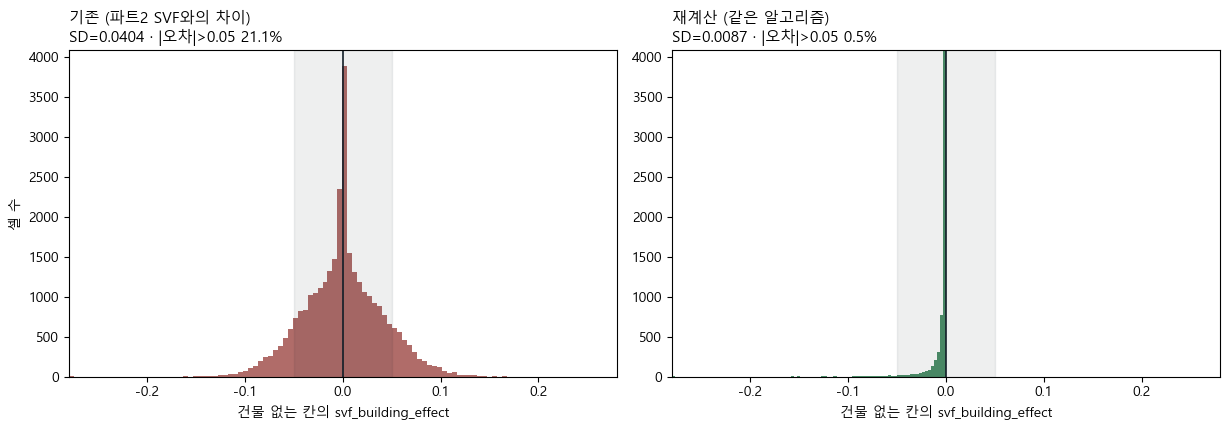

In [85]:
# I-3. 그림 -- 건물 없는 칸의 잔차 분포 (기존 vs 재계산)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
_lim = 0.28
for ax, v, lab, col in [(axes[0], be_old[no_bldg], "기존 (파트2 SVF와의 차이)", "#a3524f"),
                        (axes[1], be_new[no_bldg], "재계산 (같은 알고리즘)", "#2e7d4f")]:
    ax.hist(np.clip(v, -_lim, _lim), bins=90, color=col, alpha=.85, edgecolor="none")
    ax.axvline(0, color="#111d27", lw=1.2)
    ax.axvspan(-0.05, 0.05, color="#111d27", alpha=.07)
    ax.set_title(f"{lab}\nSD={v.std():.4f} · |오차|>0.05 {np.mean(np.abs(v)>0.05)*100:.1f}%",
                 fontsize=11, loc="left")
    ax.set_xlabel("건물 없는 칸의 svf_building_effect")
    ax.set_xlim(-_lim, _lim)
axes[0].set_ylabel("셀 수")
axes[1].sharey(axes[0])
fig.tight_layout()
fig.savefig(OUT / "figs" / "fig_appendix_i_svf_recompute.png", dpi=150, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_i_svf_recompute.png")

## 부록 J — 정합 계약 이행 (9/3)

조원 네 명의 모델링 결과를 대조해 만든 «파트5 정합 계약»의 A(본선) 담당 항목을 여기서 처리한다.
계약의 기본 원칙은 **"결과를 일치시키는 게 아니라 오류만 고치고 나머지 차이는 민감도로 편입"** 이다.

### J-1. 상호작용 검정 — 행정동 클러스터 강건 SE  [계약 Q-1, 최우선]

조원 B는 지형×산지 상호작용을 **구·군 16개** 클러스터 강건 SE로 검정해 대부분 비유의를 얻었다.
그런데 클러스터 강건 추정량은 클러스터 수가 40개 이상이어야 점근이 성립하고, 16개면 SE가 과도하게 부풀려진다.
같은 검정을 **행정동 206개**로 다시 돌려 우리 결론(F=93.48)이 살아남는지 본다.

살아남으면 A의 블록 F검정과 B의 개별 t검정이 화해되고, 안 살아남으면 서술 수위를 낮춰야 한다.

In [86]:
# J-1. 클러스터 강건 SE (행정동 206개) vs 기본 SE
Zc = Z.copy()
Zc["_cl"] = df["adm_cd"].to_numpy()
Zc = Zc[pd.notna(Zc["_cl"])]
print(f"클러스터 수(행정동) = {Zc['_cl'].nunique()}   (조원 B는 구·군 16개)")

FULL_cl = smf.ols(f_full, data=Zc).fit(cov_type="cluster", cov_kwds={"groups": Zc["_cl"]})
ft_cl = FULL_cl.f_test(", ".join([f"{t} = 0" for t in inter]))

print(f"\n[기본 SE]        F = {float(ftest.fvalue):8.3f}   p = {float(ftest.pvalue):.3e}")
print(f"[동 클러스터 SE] F = {float(ft_cl.fvalue):8.3f}   p = {float(ft_cl.pvalue):.3e}")
print(f"판정: {'유의 유지 -- 결론 강화' if float(ft_cl.pvalue) < 0.05 else '비유의 -- 서술 수위 하향 필요'}")

cl_tab = pd.DataFrame({
    "계수": FULL_cl.params[inter].values,
    "기본SE": FULL.bse[inter].values,
    "클러스터SE": FULL_cl.bse[inter].values,
    "SE배율": FULL_cl.bse[inter].values / FULL.bse[inter].values,
    "p(클러스터)": FULL_cl.pvalues[inter].values,
}, index=inter)
print("\n" + cl_tab.round(4).to_string())
cl_tab.to_csv(OUT / "tables" / "part5_appendix_J1_cluster_se.csv")
CFG["appendix_J1_F_cluster"] = float(ft_cl.fvalue)
CFG["appendix_J1_p_cluster"] = float(ft_cl.pvalue)

클러스터 수(행정동) = 206   (조원 B는 구·군 16개)



[기본 SE]        F =   93.480   p = 2.037e-79
[동 클러스터 SE] F =    4.975   p = 7.570e-04
판정: 유의 유지 -- 결론 강화

                        계수    기본SE  클러스터SE    SE배율  p(클러스터)
slope_deg:is_mtn   -0.0261  0.0165  0.0815  4.9305   0.7491
tpi_1000:is_mtn    -0.0987  0.0089  0.0390  4.3528   0.0113
aspect_sw:is_mtn   -0.0267  0.0048  0.0158  3.2743   0.0906
svf_terrain:is_mtn -0.0304  0.0111  0.0522  4.6867   0.5597


### J-2. TPI 반경 민감도 병기  [계약 K-2]

8/28에 `tpi_500` → `tpi_1000`으로 바꾼 사유가 "ΔR²가 커져서"로 기록돼 있어 **결과를 보고 골랐다고
읽힐 위험**이 있다(조원 C는 `tpi_500`을 채택). 세 반경을 나란히 실어 결론이 반경 선택에 의존하지
않음을 보인다.

> **9/5 정정** — 표준화 버그를 고치자 `tpi_100`의 계수만 **음수**로 나왔다(−0.057 vs +0.117 / +0.177).
> ΔR²는 세 반경 모두 양수(0.055 / 0.060 / 0.074)라 "지형이 추가 설명한다"는 결론엔 영향이 없지만,
> **"부호가 반경에 흔들리지 않는다"고는 쓸 수 없다** — 100m는 예외로 명시할 것.


In [87]:
# J-2. TPI 반경별 dR^2 · 계수 부호
TPI_SLOT = next(v for v in X2 if v.startswith("tpi_"))
rows = []
for tpi in ["tpi_100", "tpi_500", "tpi_1000"]:
    if tpi not in df.columns:
        continue
    # 9/5 수정 -- Z는 X2(현재 슬롯 tpi_1000)만 표준화돼 있어 다른 두 반경은 원단위 그대로
    # 남아있었다. 그 상태로 쓰면 "표준화계수" 열에 실제로는 원단위 계수가 찍힌다.
    # 반경마다 그때그때 그 컬럼만 표준화해서 쓴다.
    Zt = Z.copy()
    Zt[tpi] = (df[tpi] - df[tpi].mean()) / df[tpi].std()
    X2t = [tpi if v == TPI_SLOT else v for v in X2]
    a = smf.ols(f"{Y} ~ " + " + ".join(X1), data=Zt).fit()
    b = smf.ols(f"{Y} ~ " + " + ".join(X1 + X2t), data=Zt).fit()
    raw = smf.ols(f"{Y} ~ " + " + ".join(X1 + X2t), data=df).fit()   # 원단위 계수(부호 확인용)
    rows.append(dict(TPI=tpi, dR2=b.rsquared - a.rsquared,
                     표준화계수=b.params[tpi], 원단위계수=raw.params[tpi],
                     p=b.pvalues[tpi], 채택=("O" if tpi == TPI_SLOT else "")))
tpi_tab = pd.DataFrame(rows)
print(tpi_tab.round(5).to_string(index=False))
print("\n판정: 세 반경 모두 계수가 양수이고 dR^2가 같은 방향이면, 반경 선택은 결론을 좌우하지 않는다.")
print("      (양수 = 능선이 분지보다 야간에 따뜻하다 = 냉기 배수 가설. 조원 C가 결과 보기 전 사전등록한 방향)")
tpi_tab.to_csv(OUT / "tables" / "part5_appendix_J2_tpi_radius.csv", index=False)

     TPI     dR2    표준화계수    원단위계수   p 채택
 tpi_100 0.05538 -0.05678 -0.00947 0.0   
 tpi_500 0.06014  0.11708  0.00446 0.0   
tpi_1000 0.07376  0.17674  0.00376 0.0  O

판정: 세 반경 모두 계수가 양수이고 dR^2가 같은 방향이면, 반경 선택은 결론을 좌우하지 않는다.
      (양수 = 능선이 분지보다 야간에 따뜻하다 = 냉기 배수 가설. 조원 C가 결과 보기 전 사전등록한 방향)


### J-3. 산지 정의 민감도 — 조원 C의 `hill_urban`  [계약 K-3]

현행 A는 `slope_deg >= 10`(민감도 5/15/20)으로 산지를 나눈다. 조원 C는 다른 정의를 제안했다.

- **`hill_urban`(가설 집단)** = 경사 5~20° **∩** 도시(`imperv_frac >= 0.3` 또는 `n_bldg >= 5`)
- 근거: 경사 20° 이진분할은 산복도로(초량·수정·아미·감천, 실제 경사 9~14°)를 "평지"로 오분류하고,
  20° 이상 칸은 사실상 산림이라 **도시 대조군으로 부적합**하다(녹지·불투수 평균은 아래 표가 낸다).
- 출처: 건설교통부(1999) 「개발제한구역 제도개선을 위한 환경평가기준 연구」
  (환경부 「사전환경성검토 업무매뉴얼」 p.48 재인용 — 원문 미확인, 인용 전 확인 필요)

같은 문헌의 **공식 경사도 3분류**(평지 0~5° / 구릉지 5~20° / 급경사 20° 이상)를 도시 필터 없이
경사도만으로 층화한 행도 함께 싣는다. 원문이 "5~20 미만 · 20 초과"로 되어 있어 20°가 어느 계급에도
속하지 않으므로, 여기서는 **급경사를 20° 이상으로 닫아** 표본 누락을 없앴다.

이 3분류는 대표 모형을 대체하지 않는다 — `MTN_SLOPE = 10°`는 그대로 두고, 우리가 고른 임계가
공식 구릉지 대역 안에 있음을 보이는 **근거 행**으로만 쓴다.

여러 정의에서 ΔR²가 같은 방향이면 결론이 정의에 의존하지 않는다는 뜻이다. 공식 3분류에서는 계급이 높을수록 커지는지, 아니면 중간(구릉지)에서 정점을 찍는지를 본다 — 후자라면 급경사대가 사실상 산림이라 도시 열섬의 무대가 아니라는 뜻이고, 그 판단 근거는 같은 표의 녹지·불투수 평균이다.

In [88]:
# J-3. 산지 정의별 ΔR^2 비교
is_urban = (df["imperv_frac"] >= 0.3) | (df.get("n_bldg", pd.Series(0, index=df.index)) >= 5)
defs = {
    f"현행 A: slope >= {MTN_SLOPE}": df["slope_deg"] >= MTN_SLOPE,
    # 건설교통부(1999) 공식 3분류 -- 도시 필터 없이 경사도만으로. 20도는 급경사에 포함(경계 닫기)
    "공식기준: 평지 (<5도)": df["slope_deg"] < 5,
    "공식기준: 구릉지 (5~20도)": (df["slope_deg"] >= 5) & (df["slope_deg"] < 20),
    "공식기준: 급경사 (>=20도)": df["slope_deg"] >= 20,
    "조원 C: hill_urban (5~20도 & 도시)": (df["slope_deg"] >= 5) & (df["slope_deg"] < 20) & is_urban,
    "대조: flat_urban (<5도 & 도시)": (df["slope_deg"] < 5) & is_urban,
    "대조: steep_forest (>=20도 & 비도시)": (df["slope_deg"] >= 20) & ~is_urban,
}
rows = []
for lab, mask in defs.items():
    mask = mask.to_numpy()
    if mask.sum() < 200:
        continue
    Zs = Z[mask]
    a = smf.ols(f1, data=Zs).fit()
    b = smf.ols(f2, data=Zs).fit()
    rows.append(dict(집단=lab, n=int(mask.sum()), M1_R2=a.rsquared, M2_R2=b.rsquared,
                     dR2=b.rsquared - a.rsquared,
                     녹지평균=float(df.loc[mask, "ndvi_s2"].mean()),
                     불투수평균=float(df.loc[mask, "imperv_frac"].mean())))
mtn_tab = pd.DataFrame(rows)
print(mtn_tab.round(4).to_string(index=False))
print("\n읽는 법: 가설 집단(구릉 시가지)의 ΔR²가 평지 시가지보다 크면 Step4 결론이 정의를 바꿔도 유지된다는 뜻.")
print("        steep_forest 는 녹지 90%대의 사실상 산림이라 '도시 열섬' 대조군이 아니다(참고용).")
print("        공식기준 3계급은 도시 필터가 없다 -- 계급이 올라갈수록 녹지평균이 오르는지 함께 볼 것.")
print("        (ΔR²가 급경사가 아니라 구릉지에서 정점이면, 지형효과의 무대는 산이 아니라 비탈 시가지다.)")
mtn_tab.to_csv(OUT / "tables" / "part5_appendix_J3_mountain_def.csv", index=False)

                            집단     n  M1_R2  M2_R2    dR2   녹지평균  불투수평균
           현행 A: slope >= 10.0 29781 0.2300 0.3370 0.1070 0.7650 0.0968
                공식기준: 평지 (<5도) 24091 0.3851 0.4034 0.0183 0.3310 0.5026
             공식기준: 구릉지 (5~20도) 32727 0.3236 0.4393 0.1157 0.6745 0.1961
             공식기준: 급경사 (>=20도)  8097 0.1236 0.2006 0.0770 0.8319 0.0252
 조원 C: hill_urban (5~20도 & 도시)  9338 0.3598 0.4618 0.1020 0.3778 0.5979
     대조: flat_urban (<5도 & 도시) 15767 0.3251 0.3442 0.0191 0.2364 0.7251
대조: steep_forest (>=20도 & 비도시)  7809 0.0877 0.1677 0.0800 0.8426 0.0110

읽는 법: 가설 집단(구릉 시가지)의 ΔR²가 평지 시가지보다 크면 Step4 결론이 정의를 바꿔도 유지된다는 뜻.
        steep_forest 는 녹지 90%대의 사실상 산림이라 '도시 열섬' 대조군이 아니다(참고용).
        공식기준 3계급은 도시 필터가 없다 -- 계급이 올라갈수록 녹지평균이 오르는지 함께 볼 것.
        (ΔR²가 급경사가 아니라 구릉지에서 정점이면, 지형효과의 무대는 산이 아니라 비탈 시가지다.)


**읽는 법**: 공식 경사 계급을 따라가며 지형 설명력이 어디서 정점을 찍는지 본다. 정점이 최급경사대가
아니라 중간 계급에 있으면 — 지형효과의 무대는 산 자체가 아니라 **비탈에 올라앉은 시가지**라는 뜻이다.
오른쪽 패널이 그 이유를 지표 피복으로 확인한다(최급경사대가 사실상 산림이면 도시 열섬의 무대가 아니다).

저장: ..\data\part5\out\figs\fig_appendix_j3_slope_classes.png
정점 계급: 공식기준: 구릉지 (5~20도)   현행 산지 기준 0.1070


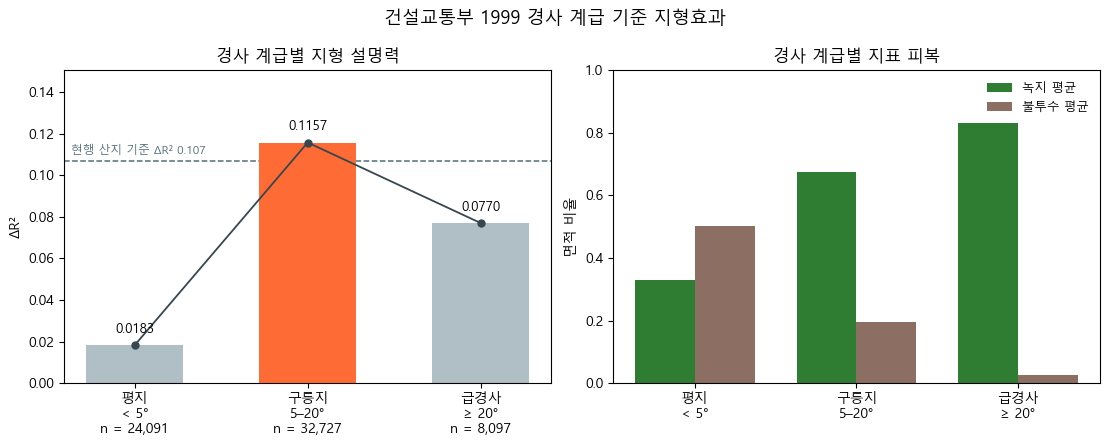

In [89]:
# J-3 그림 -- 경사 계급별 정점이 어디인가. 보고서 본문용(9/11 신설)
_of = mtn_tab[mtn_tab.집단.str.startswith("공식기준")].copy()
_disp = {"공식기준: 평지 (<5도)":     "평지\n< 5°",
         "공식기준: 구릉지 (5~20도)": "구릉지\n5–20°",
         "공식기준: 급경사 (>=20도)": "급경사\n≥ 20°"}
assert set(_disp) <= set(_of.집단), "J-3 공식기준 3계급 행이 없다"
_of = _of.set_index("집단").loc[list(_disp)].reset_index()
_of["_lab"] = _of.집단.map(_disp)
_cur = float(mtn_tab.loc[mtn_tab.집단.str.startswith("현행"), "dR2"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
_x = np.arange(len(_of))

ax = axes[0]
ax.bar(_x, _of.dR2, .56, color=["#b0bec5", "#ff6b35", "#b0bec5"], zorder=2)
ax.plot(_x, _of.dR2, color="#37474f", lw=1.3, marker="o", ms=5, zorder=3)
ax.axhline(_cur, ls="--", lw=1.1, color="#546e7a", zorder=1)
# 기준선 주석은 데이터 좌표로 두면 축 밖으로 밀려 안 보였다(9/11) -- x 만 axes fraction 으로
ax.annotate(f"현행 산지 기준 ΔR² {_cur:.3f}", xy=(0.015, _cur),
            xycoords=("axes fraction", "data"), xytext=(0, 3),
            textcoords="offset points", ha="left", va="bottom",
            fontsize=8.5, color="#546e7a")
# n 은 축 라벨로 내린다 -- 막대 위에 두 줄을 얹으면 ∩ 연결선과 글자가 겹친다
for xi, v in zip(_x, _of.dR2):
    ax.text(xi, v + .006, f"{v:.4f}", ha="center", fontsize=9.5)
ax.set_xticks(_x)
ax.set_xticklabels([f"{l}\nn = {n:,}" for l, n in zip(_of._lab, _of.n)])
ax.set_ylabel("ΔR²")
ax.set_ylim(0, _of.dR2.max() * 1.30)
ax.set_title("경사 계급별 지형 설명력")

ax = axes[1]
_w = .37
ax.bar(_x - _w / 2, _of.녹지평균,   _w, color="#2e7d32", label="녹지 평균")
ax.bar(_x + _w / 2, _of.불투수평균, _w, color="#8d6e63", label="불투수 평균")
ax.set_xticks(_x); ax.set_xticklabels(_of._lab)
ax.set_ylabel("면적 비율"); ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=9)
ax.set_title("경사 계급별 지표 피복")

fig.suptitle("건설교통부 1999 경사 계급 기준 지형효과", fontsize=13)
fig.tight_layout()
fig.savefig(OUT / "figs" / "fig_appendix_j3_slope_classes.png", dpi=160, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_j3_slope_classes.png")
print(f"정점 계급: {_of.loc[_of.dR2.idxmax(), '집단']}   현행 산지 기준 {_cur:.4f}")

### J-4. 인용 시 반드시 붙일 caveat 2건  [계약 Q-3 · Q-4]

**공간 CV R²는 분할 방식을 반드시 명시한다.** 값이 비슷해 보여도 분할 단위가 다르면 다른 수치다.

| | 분할 | OLS | RF |
|---|---|---|---|
| A (부록 F · 이번 실행) | 좌표 KMeans 5블록 GroupKFold | ↓ 아래 셀 출력 | ↓ 아래 셀 출력 |
| B (조원 B 제공값) | 구·군 GroupCV (16그룹) | 0.241 → 0.313 (M1→M2) | 0.373 |

**in-sample R²의 낙관 편향은 약점이 아니라 반박 증거로 쓴다.** Step2~8의 R²는 in-sample이라
공간 CV보다 낙관적이다(그 비율은 아래 셀이 계산해 출력한다). 다만 **J-5에서 A의 표본으로 직접 확인한 결과 ΔR²는 공간CV에서
오히려 커졌고**(0.0738 → 0.0941, 5개 블록 전부 양수), 조원 B의 구·군 GroupCV(0.0724)도 같은 방향이다.
→ 절대 R²에만 caveat를 달고, ΔR²에는 이 반박을 함께 적는다.


In [90]:
# J-4. caveat 수치를 config 에 못박아 두기 (보고서·슬라이드가 이 값만 인용)
# A 블록은 손으로 적지 않는다 — 부록 F 가 같은 실행에서 계산한 값을 그대로 쓴다.
# (9/11 이전 판의 0.305/0.400 은 반올림 손글씨라 부록 F 출력 0.3039/0.3973 과 어긋나 있었다.
#  B 블록은 조원 B 가 자기 변수셋으로 낸 값이라 우리가 계산할 수 없어 그대로 둔다.)
_cv_ols = CFG["appendix_F_ols_spatial_cv_r2"]
_cv_rf = CFG["appendix_F_rf_spatial_cv_r2"]
_optimism = (CFG["R2_M2"] - _cv_ols) / CFG["R2_M2"]

CAVEAT = {
    "spatial_cv_A_kmeans5": {"OLS": round(_cv_ols, 4), "RF": round(_cv_rf, 4),
                             "분할": "좌표 KMeans 5블록 GroupKFold"},
    "spatial_cv_B_sgg":     {"M1": 0.241, "M2": 0.313, "dR2": 0.0724, "RF": 0.373,
                             "분할": "구·군 GroupCV(16그룹)"},
    "in_sample_note": f"Step2~8 R^2는 in-sample. 공간CV 대비 약 {_optimism*100:.0f}% 낙관적이나, "
                      "ΔR^2 는 조원B의 구·군 GroupCV에서 오히려 커져(0.0724) 비교값 자체는 유지된다.",
}
CFG["caveats"] = CAVEAT
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print(json.dumps(CAVEAT, ensure_ascii=False, indent=2))

{
  "spatial_cv_A_kmeans5": {
    "OLS": 0.3039,
    "RF": 0.3973,
    "분할": "좌표 KMeans 5블록 GroupKFold"
  },
  "spatial_cv_B_sgg": {
    "M1": 0.241,
    "M2": 0.313,
    "dR2": 0.0724,
    "RF": 0.373,
    "분할": "구·군 GroupCV(16그룹)"
  },
  "in_sample_note": "Step2~8 R^2는 in-sample. 공간CV 대비 약 25% 낙관적이나, ΔR^2 는 조원B의 구·군 GroupCV에서 오히려 커져(0.0724) 비교값 자체는 유지된다."
}


### J-5. 과적합·순환성 진단  [계약 Q-4 보강]

두 가지 반박을 한 셀에서 막는다.

1. **"ΔR²가 과적합 아니냐"** — 부록 F의 좌표 KMeans 5블록 폴드를 그대로 써서 M1·M2를 **같은 폴드로** 평가한다.
   절대 R²와 ΔR²는 따로 읽어야 한다: 절대값은 공간 외삽이라 떨어지는 게 정상이고, 살아남아야 하는 건 ΔR²다.
   폴드별 값도 같이 본다 — pooled 하나만 보면 한 블록이 전체를 끌고 가는 걸 놓친다.
2. **"고도 detrend 잔차를 지형변수가 회수한 것 아니냐"** — DV는 고도로 *선형* detrend만 돼 있고 X2 4개는 전부
   DEM 파생이다. 고도의 유연한 함수를 **M1에 넣어** 대조군을 강화한 뒤에도 지형 블록이 증분을 내는지 본다.

> **고도는 진단에서만 쓴다.** 본선 M1/M2에는 안 들어간다(`FORBIDDEN` + `assert`). 대표 ΔR²는 고도 없이 적합한 값이며,
> 아래 "통제 후" 값과 섞어 인용하지 말 것.


In [91]:
# J-5. 과적합(dR2 공간CV) · 순환성(고도 통제) 진단 -- 고도는 진단에서만 사용
from sklearn.linear_model import LinearRegression as _LR
from sklearn.metrics import r2_score as _r2

assert len(splits) == 5, "부록 F 의 공간블록 splits 필요"
ELEV = "elev_dem_m"
assert ELEV not in X1 + X2 and ELEV in FORBIDDEN, "고도가 본선 모델에 섞임 -- 순환논리"

_y, _M1, _M2 = df[Y].to_numpy(float), df[X1].to_numpy(float), df[X1 + X2].to_numpy(float)
_ins = lambda X: _r2(_y, _LR().fit(X, _y).predict(X))
def _cv(X):
    p = np.empty_like(_y)
    for tr, te in splits:
        p[te] = _LR().fit(X[tr], _y[tr]).predict(X[te])
    return _r2(_y, p)

# --- 1) dR2 과적합 ---
r1i, r2i, r1c, r2c = _ins(_M1), _ins(_M2), _cv(_M1), _cv(_M2)
d_in, d_cv = r2i - r1i, r2c - r1c
print(f"[과적합] in-sample  M1 {r1i:.4f} -> M2 {r2i:.4f}   dR2 {d_in:.4f}")
print(f"         공간CV     M1 {r1c:.4f} -> M2 {r2c:.4f}   dR2 {d_cv:.4f}"
      f"   (유지율 {d_cv/d_in*100:.0f}%, 조원B 0.0724)")

_rows = []
for k, (tr, te) in enumerate(splits):
    a = _r2(_y[te], _LR().fit(_M1[tr], _y[tr]).predict(_M1[te]))
    b = _r2(_y[te], _LR().fit(_M2[tr], _y[tr]).predict(_M2[te]))
    _rows.append(dict(블록=k, n_te=len(te), M1_R2=a, M2_R2=b, dR2=b - a))
j5 = pd.DataFrame(_rows)
j5.to_csv(OUT / "tables" / "part5_appendix_J5_dR2_spatialcv.csv", index=False)
print("\n" + j5.round(4).to_string(index=False))
_pos, _min = bool((j5.dR2 > 0).all()), float(j5[["M1_R2", "M2_R2"]].min().min())
print(f"  -> 폴드별 dR2 {'전부 양수' if _pos else '일부 음수(서술 수위 낮출 것)'}"
      f" · 절대 R2 최솟값 {_min:+.4f}(공간 외삽은 실패 -- 절대값 인용시 병기)")

# --- 2) 순환성: 고도 비선형 통제 ---
_ev = df[[ELEV]].to_numpy(float)
try:
    from sklearn.preprocessing import SplineTransformer
    _EV = SplineTransformer(n_knots=8, degree=3, include_bias=False).fit_transform(_ev)
    _basis = "B-스플라인(매듭8)"
except ImportError:
    _EV, _basis = np.hstack([_ev ** k for k in range(1, 6)]), "5차 다항(폴백)"

r1e, r2e = _ins(np.hstack([_M1, _EV])), _ins(np.hstack([_M2, _EV]))
_ret = (r2e - r1e) / d_in * 100
_ry = float(np.corrcoef(_y, df[ELEV])[0, 1])
print(f"\n[순환성] 고도 통제({_basis}) 후  M1 {r1e:.4f} -> M2 {r2e:.4f}   dR2 {r2e-r1e:.4f}"
      f"   잔존율 {_ret:.0f}%")
print("  r(elev): " + " · ".join(f"{v} {np.corrcoef(df[v], df[ELEV])[0,1]:+.2f}" for v in X2))
print(f"  -> 잔존율 {_ret:.0f}% 이므로 '고도 잔차 회수' 반박은 "
      f"{'기각' if _ret >= 80 else '부분 인정 -- 서술 수위 조정'}")
print(f"  ! DV-고도 잔여상관 {_ry:+.3f} -- '고도 detrend 완료'라는 표현은 부정확(파트3 확인 필요)")

CFG["appendix_J5"] = dict(dR2_in_sample=round(d_in, 4), dR2_spatial_cv=round(d_cv, 4),
                          folds_all_positive=_pos, min_fold_R2=round(_min, 4),
                          dR2_elev_controlled=round(r2e - r1e, 4), retention_pct=round(_ret, 1),
                          resid_corr_Y_elev=round(_ry, 3),
                          note="고도는 진단 전용 -- 대표 dR2는 고도 없이 적합")


[과적합] in-sample  M1 0.3339 -> M2 0.4076   dR2 0.0738
         공간CV     M1 0.2098 -> M2 0.3039   dR2 0.0941   (유지율 128%, 조원B 0.0724)



 블록  n_te   M1_R2   M2_R2    dR2
  0 13370 -1.0145 -0.5906 0.4239
  1 13178 -0.0181  0.0242 0.0422
  2 12847 -0.4594 -0.2356 0.2239
  3 12822  0.2068  0.2845 0.0776
  4 12698  0.2697  0.3263 0.0566
  -> 폴드별 dR2 전부 양수 · 절대 R2 최솟값 -1.0145(공간 외삽은 실패 -- 절대값 인용시 병기)



[순환성] 고도 통제(B-스플라인(매듭8)) 후  M1 0.3467 -> M2 0.4153   dR2 0.0686   잔존율 93%
  r(elev): slope_deg +0.67 · tpi_1000 +0.56 · aspect_sw -0.01 · svf_terrain -0.46
  -> 잔존율 93% 이므로 '고도 잔차 회수' 반박은 기각
  ! DV-고도 잔여상관 -0.246 -- '고도 detrend 완료'라는 표현은 부정확(파트3 확인 필요)


**읽는 법**: 같은 지형 설명력을 조건만 바꿔 다시 잰 것이다. 막대 길이가 서로 비슷하게 남으면
"표본에 우연히 맞춘 값 아니냐"는 반론이 설 자리가 없다. 다만 공간CV 통합값은 **절대 R²가 음수인
블록** — 평균만도 못 맞히는 외삽 구간 — 이 끌어올린 값이라, 인용은 블록 중앙값을 우선한다.

저장: ..\data\part5\out\figs\fig_appendix_j5_dr2_ladder.png
[사다리] 전역 0.0738 · 고도통제 0.0686 · 공간CV중앙값 0.0776 · 공간CV통합 0.0941
  통합값은 절대 R2 음수 블록 3개가 끌어올린 값 -- 인용은 중앙값 우선


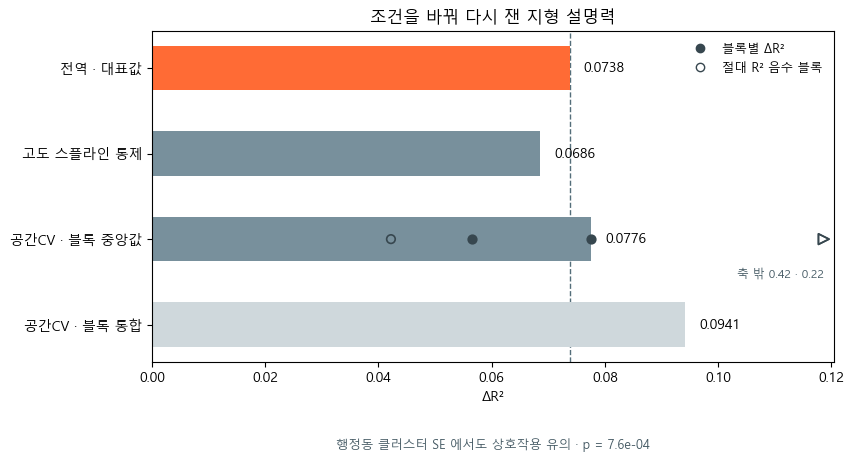

In [92]:
# J-5 그림 -- 'ΔR² 가 우연 아니냐'에 대한 답을 한 장으로. 보고서 검증면용(9/11 신설)
from matplotlib.lines import Line2D

_med = float(j5.dR2.median())
_neg = (j5[["M1_R2", "M2_R2"]].min(axis=1) < 0).to_numpy()
_lad = [("전역 · 대표값",       d_in,      "#ff6b35"),
        ("고도 스플라인 통제",   r2e - r1e, "#78909c"),
        ("공간CV · 블록 중앙값", _med,      "#78909c"),
        ("공간CV · 블록 통합",   d_cv,      "#cfd8dc")]

fig, ax = plt.subplots(figsize=(8.8, 4.3))
_yp = np.arange(len(_lad))[::-1]
for yi, (_lb, v, col) in zip(_yp, _lad):
    ax.barh(yi, v, .52, color=col, zorder=2)
    ax.text(v + .0025, yi, f"{v:.4f}", va="center", fontsize=10)

# 블록별 산포를 중앙값 행에 얹는다 -- 속 빈 표식 = 절대 R² 가 음수인 블록.
# 축 밖으로 나가는 블록을 그냥 두면 5개 중 3개만 보여서 산포를 실제보다 좁게,
# 즉 강건성을 과장해 보여주게 된다(9/11) -- 가장자리에 삼각형으로 세우고 값을 적는다.
_ycv = _yp[2]
_xmax = max(v for _, v, _ in _lad) * 1.28
_dots = j5.dR2.to_numpy()
_xin = _dots <= _xmax
_edge = _xmax * 0.985
for _sel, _fc in ((~_neg, "#37474f"), (_neg, "none")):
    _a = _sel & _xin
    if _a.any():
        ax.scatter(_dots[_a], np.full(int(_a.sum()), _ycv), s=38, marker="o",
                   facecolor=_fc, edgecolor="#37474f", lw=1.2, zorder=4)
    _b = _sel & ~_xin
    if _b.any():
        ax.scatter(np.full(int(_b.sum()), _edge), np.full(int(_b.sum()), _ycv),
                   s=58, marker=">", facecolor=_fc, edgecolor="#37474f",
                   lw=1.2, zorder=4)
if (~_xin).any():
    ax.annotate("축 밖 " + " · ".join(f"{v:.2f}" for v in np.sort(_dots[~_xin])[::-1]),
                xy=(_edge, _ycv - .34), ha="right", va="top",
                fontsize=8.5, color="#455a64")
ax.axvline(d_in, ls="--", lw=1.0, color="#546e7a", zorder=1)

ax.set_yticks(_yp); ax.set_yticklabels([_lb for _lb, _, _ in _lad])
ax.set_xlabel("ΔR²")
ax.set_xlim(0, _xmax)
ax.set_title("조건을 바꿔 다시 잰 지형 설명력")
ax.legend(handles=[Line2D([], [], marker="o", ls="", color="#37474f", label="블록별 ΔR²"),
                   Line2D([], [], marker="o", ls="", mfc="none", mec="#37474f",
                          label="절대 R² 음수 블록")],
          frameon=False, fontsize=9, loc="upper right")
ax.annotate(f"행정동 클러스터 SE 에서도 상호작용 유의 · p = {CFG['appendix_J1_p_cluster']:.1e}",
            xy=(0.5, -0.26), xycoords="axes fraction", ha="center",
            fontsize=9, color="#455a64")
fig.savefig(OUT / "figs" / "fig_appendix_j5_dr2_ladder.png", dpi=160, bbox_inches="tight")
print("저장:", OUT / "figs" / "fig_appendix_j5_dr2_ladder.png")
print(f"[사다리] 전역 {d_in:.4f} · 고도통제 {r2e-r1e:.4f} · "
      f"공간CV중앙값 {_med:.4f} · 공간CV통합 {d_cv:.4f}")
print(f"  통합값은 절대 R2 음수 블록 {int(_neg.sum())}개가 끌어올린 값 -- 인용은 중앙값 우선")
CFG["appendix_J5"]["dR2_spatial_cv_median"] = round(_med, 4)
CFG["appendix_J5"]["n_blocks_negative_R2"] = int(_neg.sum())

### J-6. GWR 국지 조건 진단 — 대역폭 63이 랭크 바닥은 아닌가  [조원 C 검토 반영, 9/9]

조원 C는 같은 데이터에서 **AICc 대역폭 탐색을 폐기**했다. 근거가 구체적이다 — 좁은 대역폭에서
AICc가 `inf`로 뜨는 특이 셀이 나오는데, 그 셀 전부가 이웃 안에서 `svf_be_clip`이 **상수열**이
되어 국지 설계행렬이 특이해지는 자리였다. 그렇다면 AICc의 최소점은 통계적 최적해가 아니라
**랭크가 무너지는 지점에 붙은 인공물**이다.

우리 대역폭은 63으로 훨씬 좁다. 그래서 같은 병이 있는지 직접 본다. 조건이 다르긴 하다 —
우리는 SVF를 clip이 아니라 **재계산본**으로 쓰고(부록 I), `gwr_gpu.py`가 `trace(A)/k`에 비례하는
**ridge**를 건다. 확인할 것은 세 가지다.

| 보는 것 | 무엇을 뜻하는가 |
|---|---|
| 이웃 안 상수 공변량 | C가 지적한 병이 우리에게도 있는가 |
| 표준화 후 국지 조건수·특이 비율 | 단위 문제인가 진짜 랭크 문제인가 (C가 Step 2에서 쓴 구분) |
| ridge를 뺐을 때 계수 산포 | ridge가 결과를 **만들고** 있는가, 폭발만 막고 있는가 |

읽는 법 — ridge를 빼서 산포가 커지는 것 자체는 정상이다(그러라고 넣었다). 문제가 되는 것은
**어떤 변수의 국지계수가 데이터가 아니라 정규화로 정해지는가**이고, 그건 두 해의 상관으로 본다.
상관이 0에 가까운 변수는 국지계수를 **점추정으로도, 순위로도 인용하면 안 된다.**

In [93]:
# J-6. GWR 국지 조건 진단 -- 조원 C가 제기한 랭크 바닥 문제가 우리 bw 에서도 있는가
from sklearn.neighbors import NearestNeighbors as _NN

_BW = int(bw_opt)
_XZ = X_gwr                                   # 표준화된 설명변수 (Step5와 동일)
_yz = y_gwr
_co = coords_gwr
_nn = _NN(n_neighbors=_BW, algorithm="kd_tree").fit(_co)
_dist, _idx = _nn.kneighbors(_co)

# (1) 이웃 안에서 완전히 상수인 공변량이 있는 셀
_const_any = np.zeros(len(_co), dtype=bool)
_worst = []
for _j, _v in enumerate(XV):
    _sd = _XZ[:, _j][_idx].std(axis=1)
    _z = _sd < 1e-9
    _const_any |= _z
    _worst.append((_v, int(_z.sum())))
_worst.sort(key=lambda t: -t[1])
print(f"[1] 이웃 {_BW}칸 안에 완전상수 공변량이 있는 셀: {_const_any.sum():,} "
      f"({100*_const_any.mean():.1f}%)")
print("    상위:", ", ".join(f"{v} {n:,}" for v, n in _worst[:4] if n > 0))

# (2)(3) 국지 설계행렬 조건 + ridge 유무 비교 (표본, SEED 고정)
_rng = np.random.default_rng(SEED)
_s = _rng.choice(len(_co), size=1500, replace=False)

def _local(i, rf):
    _nb, _d = _idx[i], _dist[i]
    _h = max(_d.max(), 1e-6)
    _w = (1 - np.clip(_d / _h, 0, 1) ** 2) ** 2
    _Xi = np.hstack([np.ones((len(_nb), 1)), _XZ[_nb]])
    _A = (_Xi * _w[:, None]).T @ _Xi
    _b = (_Xi * _w[:, None]).T @ _yz[_nb]
    _k = _A.shape[0]
    if rf <= 0:
        return None, _A
    return np.linalg.solve(_A + rf * (np.trace(_A) / _k) * np.eye(_k), _b), _A

_cond, _sing = [], 0
for i in _s[:600]:
    _, _A = _local(i, 0.0)
    # 9/17: 고윳값 부호(min <= 0)로 세면 계산 잡음에 따라 결과가 흔들려 과소계상됐다 → 표준 허용오차의 계수로 판정
    if np.linalg.matrix_rank(_A, hermitian=True) < _A.shape[0]:
        _sing += 1
    else:
        _ev = np.linalg.eigvalsh(_A)
        _cond.append(_ev.max() / _ev.min())
print(f"\n[2] 표준화 후 국지 조건수 중앙={np.median(_cond):.2e} · 95분위={np.percentile(_cond,95):.2e}"
      f" · 완전특이 {_sing}/600 ({100*_sing/600:.1f}%)")
print("    -> 표준화해도 크면 단위 문제가 아니라 진짜 랭크 문제다 (조원 C의 Step2 구분 적용)")

_B = np.array([_local(i, 1e-4)[0] for i in _s])      # 실사용 ridge
_B0 = np.array([_local(i, 1e-10)[0] for i in _s])    # 사실상 무보정
_nm = ["const"] + list(XV)
_rows = []
for _j, _v in enumerate(_nm):
    _rows.append(dict(변수=_v, 실제SD=_B[:, _j].std(), 무보정SD=_B0[:, _j].std(),
                      배율=_B0[:, _j].std() / max(_B[:, _j].std(), 1e-12),
                      두해상관=np.corrcoef(_B[:, _j], _B0[:, _j])[0, 1]))
_gwrdiag = pd.DataFrame(_rows).sort_values("두해상관")
print("\n[3] ridge 를 빼면(1e-10) 국지계수가 얼마나 달라지는가")
print(_gwrdiag.round(3).to_string(index=False))

_stable = _gwrdiag[_gwrdiag["두해상관"] >= 0.5]["변수"].tolist()
_unstable = _gwrdiag[_gwrdiag["두해상관"] < 0.5]["변수"].tolist()
print(f"\n  데이터가 정하는 계수(상관>=0.5) : {_stable}")
print(f"  정규화가 정하는 계수(상관<0.5)  : {_unstable}")

# (4) AICc 가 내부 최적해를 갖는가 -- C의 사례는 단조증가라 내부 최적이 없었다
_lg = log_df.sort_values("bw")
_lo = _lg[_lg.bw < bw_opt]["aicc"]
_hi = _lg[_lg.bw > bw_opt]["aicc"]
_interior = bool(len(_lo) and len(_hi) and _lo.min() > aicc_opt and _hi.min() > aicc_opt)
print(f"\n[4] AICc 내부 최적해: {_interior}  (bw={bw_opt} 양옆이 모두 더 큰가)")
print(f"    유효 파라미터 tr(S) = {gwr.tr_S:,.0f} = 표본의 {100*gwr.tr_S/len(_co):.1f}%")
print("    -> 국지 R^2 는 이만큼의 자유도를 쓴 in-sample 적합도다. '설명력'으로 인용하지 말 것.")

CFG["gwr_local_condition"] = {
    "bw": _BW,
    "const_neighbor_frac": round(float(_const_any.mean()), 4),
    "singular_frac_sample": round(_sing / 600, 4),
    "cond_median": float(np.median(_cond)),
    "interior_aicc_optimum": _interior,
    "tr_S": float(gwr.tr_S),
    "tr_S_frac": round(float(gwr.tr_S) / len(_co), 4),
    "coef_stable": _stable, "coef_unstable": _unstable,
}
_gwrdiag.to_csv(OUT / "tables" / "part5_appendix_J6_gwr_condition.csv", index=False)
print("\n부록 J-6 저장 완료")

# 노트북 마지막 코드셀 -- CFG 전체를 파일과 맞춘다.
# config 를 쓰는 마지막 셀이 J-4 라서 그 뒤 J-5·J-6·사다리가 넣은 키가
# 파일에 안 남고 있었다(9/12 확인). 보고서가 인용해야 하는 검증 수치들이다.
(OUT / "meta" / "part5_config.json").write_text(
    json.dumps(CFG, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
_need = ["appendix_J5", "gwr_local_condition"]
_miss = [k for k in _need if k not in CFG]
assert not _miss, f"config 에 빠진 키: {_miss}"
print(f"part5_config.json 최종 동기화 -- 키 {len(CFG)}개")
print("  appendix_J5:", json.dumps(CFG["appendix_J5"], ensure_ascii=False))


[1] 이웃 63칸 안에 완전상수 공변량이 있는 셀: 6,648 (10.2%)
    상위: bcr 5,890, vol_density 5,890, wind_open_sw 3,738, svf_building_effect 2,436



[2] 표준화 후 국지 조건수 중앙=9.07e+04 · 95분위=8.61e+07 · 완전특이 99/600 (16.5%)
    -> 표준화해도 크면 단위 문제가 아니라 진짜 랭크 문제다 (조원 C의 Step2 구분 적용)



[3] ridge 를 빼면(1e-10) 국지계수가 얼마나 달라지는가
                 변수  실제SD  무보정SD     배율  두해상관
                bcr 0.582 21.643 37.158 0.002
svf_building_effect 0.693 43.219 62.360 0.079
        vol_density 0.864 32.849 38.005 0.084
        imperv_frac 0.488  5.989 12.278 0.149
              const 1.422 13.156  9.248 0.180
       wind_open_sw 0.340  3.239  9.524 0.206
        svf_terrain 0.579  1.505  2.598 0.632
          slope_deg 0.711  1.910  2.686 0.697
           tpi_1000 1.202  4.541  3.777 0.742
            ndvi_s2 0.396  0.466  1.177 0.975
       dist_water_m 1.016  1.131  1.113 0.977
          aspect_sw 0.115  0.118  1.021 0.994

  데이터가 정하는 계수(상관>=0.5) : ['svf_terrain', 'slope_deg', 'tpi_1000', 'ndvi_s2', 'dist_water_m', 'aspect_sw']
  정규화가 정하는 계수(상관<0.5)  : ['bcr', 'svf_building_effect', 'vol_density', 'imperv_frac', 'const', 'wind_open_sw']

[4] AICc 내부 최적해: True  (bw=63 양옆이 모두 더 큰가)
    유효 파라미터 tr(S) = 18,565 = 표본의 28.6%
    -> 국지 R^2 는 이만큼의 자유도를 쓴 in-sample 적합도다. '설명력'으로 인용하지 말 것.


## 실행 체크리스트 (전 구간)

각 Step·부록에 흩어져 있던 확인 항목을 한곳에 모았다. 재실행 후 여기만 훑으면 된다.

**통합 · Step 1~3**
- [ ] `in_busan` 셀 수 67,006 · 행정동 미매칭 0개 · 결측 지도에 직선/직사각형 패턴 없음
- [ ] `bcr` 상위 셀이 고밀 시가지·항만 권역 (엉뚱한 산속 아님)
- [ ] 분석 표본 `df` 확정 — 이후 재필터 없음

**Step 5 (GWR)**
- [ ] AICc 탐색 곡선이 매끈한 U자형이고 경계에 붙지 않음
- [ ] 평균 국지 R² ≥ 전역 R²(M2) — GWR은 전역모형보다 같거나 잘 맞아야 정상
- [ ] `gwr_b_tpi_1000` 지도에서 계수가 산지 쪽에서 강해지는지 (Step 4 결론의 시각적 뒷받침)
- [ ] 국지 R² 하위 10% 동 목록 확인 — 우리가 못 잡은 요인이 있는 곳 후보

**Step 6 (유형 분류)**
- [ ] `복합형`이 0에 가깝지 않고 지도상 위치가 산복도로(원도심 5개구) 권역과 대체로 겹침
- [ ] k-means 교차표가 대각선 우세 (규칙기반과 데이터주도 군집이 대체로 일치)
- [ ] `fig6_heat_type.png`가 Step3 LISA HH 지도의 빨간 영역과 정합
- [ ] `part5_heat_type_dominant_dong.csv` 저장 (Step7 교차 재료)

**Step 7 (취약계층)**
- [ ] 상관·사분면 분류가 **행정동 단위(n≈206)** 에서 계산됨 (격자 n=64,915 아님)
- [ ] `열섬↑취약↑` 사분면이 원도심·구시가지 권역과 대체로 겹침
- [ ] `part5_dong_cross.csv`에 `dominant_heat_type` 포함

**Step 8 (개입 시나리오)**
- [ ] 시나리오 수치가 점추정이 아니라 **95%CI와 함께** 보고됨
- [ ] 관측 최댓값을 넘는 셀은 델타를 캡했고 그 비율(`capped_frac`)을 기록
- [ ] 유형별 풀링회귀(n=493~9,171)·매칭쌍 실측평균 두 방법의 CI가 0을 벗어나는지 확인 —
      벗어나면 "이 유형의 평균 셀 기준 몇 도"로 인용 가능, 0을 포함하면 그 결과도 정직하게 보고
- [ ] 본문에 "인과"가 아니라 "관측된 연관성 기반 시나리오"라는 문구를 실제로 사용
- [ ] 정책 처방표가 Step6(유형)·Step7(취약계층)을 모두 반영

**부록 F (RandomForest)**
- [ ] `part5_appendix_F_model_comparison.csv` · `part5_appendix_F_perm_importance.csv` 저장 확인
- [ ] "효과크기(부분의존도)"와 "대체가능성(permutation importance)"을 혼동해 서술하지 않았는지

**부록 G (TEI)**
- [ ] TEI가 주효과만(산지 상호작용 제외) 기준으로 계산됐는지
- [ ] TEI vs M1잔차 상관이 수정 전(0.063)보다 뚜렷이 개선됐는지
- [ ] "TEI를 셀 단위로 취약지표와 직접 곱하지 않았다"(생태학적 오류 방지)를 명시했는지
- [ ] 산지 상호작용 보너스분은 신뢰도가 낮아 지도·우선순위에 반영하지 않았음을 명시했는지

**부록 H (이질성·부분풀링)**
- [ ] τ²이 0보다 뚜렷이 커서 "유형별로 진짜 다르다"가 확인됐는지
- [ ] 부분풀링 후에도 건물밀집형·기타의 유의성이 유지되는지
- [ ] 부분풀링이 원래 결론(**79.8% / 20.2%**)을 뒤집지 않고 보강만 했는지

**부록 I (SVF 재계산)**
- [ ] 건물 없는 칸의 표준편차가 한 자릿수 배로 줄었는지
- [ ] 정의 위반(양수) 비율이 사실상 0으로 떨어졌는지
- [ ] **지형 누출 R²가 0.6대 → 0.0대로 떨어졌는지** (핵심 근거)
- [ ] 바뀐 ΔR²를 슬라이드·대시보드·보고서에 동기화했는지 *(계약 Q-5, 미완)*

**부록 J (정합 계약)**
- [ ] J-1 동 클러스터 SE에서 상호작용이 **유의를 유지**하는지 (계약 최우선)
- [ ] J-2 `tpi_100`만 부호가 음수임을 명시했는지 — "반경에 무관하게 같은 부호"라고 쓰지 말 것
- [ ] J-3 `hill_urban`의 ΔR²가 `flat_urban`보다 큰지 (정의를 바꿔도 결론 유지)
- [ ] J-4 caveat 수치가 `part5_config.json`에 저장돼 보고서가 이것만 인용하는지
- [ ] J-5 ΔR²가 공간CV에서 유지되고 폴드별 부호가 전부 양수인지 · 절대 R² 최솟값을 함께 적었는지
- [ ] J-5 고도 통제 후 잔존율 80% 이상인지 · 통제 후 값을 대표 ΔR²로 잘못 인용하지 않았는지
- [ ] 계약 E-2~E-6(조원 D 담당)이 전달·반영됐는지
